<a href="https://colab.research.google.com/github/angelrecalde2024/Power-Distribution-Design-and-Management/blob/main/INGP1120_Distribution_VoltageRegulation_heuristic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DISTRIBUTION SYSTEM ANALYSIS FOR VOLTAGE REGULATION

This notebook helps in determining candidate locations for regulator and capacitor banks to achieve a voltage regulation setpoint.

It performs a heuristic analysis based on performance indicators per bus to identify voltage weaknesses and reactive deficiencies.


Created by Dr. Angel Recalde, 2026.

This methodology assumes:

*  Radial MV feeder modeled in OpenDSS
*  Load flow solved through Python + DSS-extension
*  Available data: 1) bus voltages, 2) line flows, 3) losses, 4) network topology, 5) bus coordinates/electrical distances

This structure is appropriate for this feeder (~1600 buses, ~1400 lines) and is commonly used in distribution planning studies before optimization.


**1. OBJECTIVE**

The objective of this methodology is to identify candidate locations for voltage regulation devices and shunt capacitor banks in a radial medium-voltage distribution feeder.
The method aims to:

1.	Improve feeder voltage profile
2.	Reduce technical losses
3.	Reduce reactive power transport
4.	Identify a shortlist of promising locations prior to formal optimization

Instead of evaluating all buses or line sections, the method applies engineering screening indices based on voltage sensitivity and loss gradients to reduce the search space.

**2. BASE CASE NETWORK ANALYSIS**

The analysis begins with a base-case power flow solution of the feeder model.

The base case provides the following data: bus voltage magnitudes, line active and reactive power flow, line losses, bus load values, network topology and connectivity.

These variables are used to derive the screening indices.

**3. ELECTRICAL DISTANCE CALCULATION**

An important parameter in distribution feeders is electrical distance from the substation. For each bus $k$, electrical distance is computed as:

$$
D_k=\sum_{\ell \in \text { path }(0, k)}\left|Z_{\ell}\right|
$$

where $Z_l$ is the impedance magnitude of the line segment, and $path(0,k)$ is the path between source bus and bus $k$.

In practice, either of the following can be used:

*  impedance-weighted distance
*  accumulated line length

Electrical distance reflects the voltage leverage and loss transport effect.

**4. DOWNSTREAM AGGREGATION**

For each bus $k$, the set of downstream buses is defined as

$$
\Omega_k\
$$

The following quantities are computed for each bus:

Downstream load

$$
P_{down,k}=\sum_{j\in\Omega_k} P_j\
$$

$$
Q_{down,k}=\sum_{j\in\Omega_k} Q_j\
$$

Downstream apparent load

$$
S_{down,k}=\sum_{j\in\Omega_k}\sqrt{P_j^2+Q_j^2}\
$$

These quantities represent the electrical burden supported upstream of the bus.

**5. REGULATOR CANDIDATE SCREENING**

Voltage regulators are series voltage control devices designed to maintain voltage within acceptable limits along long feeder sections.

The objective of the screening process is to identify feeder sections where a regulator would provide the largest downstream voltage improvement.

5.1 Downstream Voltage Deficiency Index

Voltage deficiency downstream of bus kis defined as

$$
VD_k=\sum_{j\in\Omega_k}{\max(0,}V_{ref}-V_j)\
$$

where $V_{ref}=0.97\ pu\$.

$V_k$ is the index thet quantifies the total undervoltage severity downstream.

5.2 Load-Weighted Voltage Deficiency

To emphasize locations affecting larger loads:

$$
LVD_k=\sum_{j\in\Omega_k} S_j\cdot\max(0,V_{ref}-V_j)\
$$

This index prioritizes locations where voltage improvement benefits larger demand.

5.3 Voltage Slope Index

Voltage slope along a feeder segment indicates where the feeder begins to experience significant voltage drop. For bus $k$:

$$
VS_k=V_{upstream(k)}-V_{downstream(k)}\
$$

Large values indicate voltage decay regions, which are good regulator breakpoints.

5.4 Distance Suitability Function

Voltage regulators should generally be located neither too close to the substation nor at the extreme end of the feeder.

A normalized distance suitability function is defined as

$$
f(D_k)=\frac{D_k}{D_{max}}(1-\frac{D_k}{D_{max}})\
$$

This favors intermediate-to-remote feeder locations.

5.5 Regulator Screening Index

The regulator suitability index is defined as

$$
R_k=(α_1VD_k+α_2LVD_k+α_3VS_k)f(Dk)
$$

where $\alpha_1,\alpha_2,\alpha_3\$ are weighting coefficients.

Large values of $R_k$ indicate promising regulator locations.

**6. CAPACITOR CANDIDATE SCREENING**

Capacitor banks provide shunt reactive compensation, reducing reactive flow and improving voltage levels.

The screening focuses on identifying locations where reactive support provides maximum voltage improvement and loss reduction.

6.1 Reactive Burden Index

Reactive burden downstream of bus $k$ is

$$
RB_k=Q_{down,k}\
$$

High values indicate substantial reactive demand.

6.2 Reactive Burden Transport Index

Reactive power transported over long distances increases losses.

The transport index is

$$
RT_k=Q_{down,k}\cdot D_k\
$$

This favors buses where reactive support reduces upstream current flow.

6.3 Loss Density Index

Loss density identifies sections where losses concentrate.

For line segment l:

$$
LD_l=\frac{P_{loss,l}}{Length_l}\
$$

For bus k, the index is

$$
LD_k=\sum_{l\in p a t h(0,k)} L D_l\
$$

High values indicate regions where reactive compensation reduces losses.

6.4 Voltage Sensitivity to Reactive Injection

Voltage sensitivity at bus kis approximated through a perturbation approach.

A small reactive injection

$$
\Delta Q_k\
$$

is applied, and voltage improvement is measured as

$$
VSEN_k=\frac{V_{min,new}-V_{min,base}}{\Delta Q_k}\
$$

Higher values indicate strong voltage response to reactive support.

6.5 Loss Gradient Sensitivity

Similarly, loss sensitivity is computed as

$$
LSEN_k=-\frac{P_{loss,new}-P_{loss,base}}{\Delta Q_k}\
$$

This index measures loss reduction per kvar injected.

6.6 Capacitor Screening Index

The final capacitor candidate index is defined as

$$
C_k=\beta_1RT_k+\beta_2LD_k+\beta_3VSEN_k+\beta_4LSEN_k\
$$

where $\beta_i\$ are weighting coefficients. Large values indicate strong capacitor candidates.

**7. CANDIDATE RANKING PROCEDURE**

The ranking procedure follows these steps:

Step 1: Run base case load flow.

Step 2: Compute feeder structural parameters: 	electrical distance, downstream load, downstream reactive demand

Step 3: Compute regulator indices: $R_k$

Step 4: Compute capacitor indices: $C_k$

Step 5: Rank candidate buses and line sections: 	Top $N_R$ regulator candidates, Top $N_C$ capacitor candidates. Typical values: $N_R$=5–10, $N_C$=10–20

Step 6: Perform perturbation validation: For each candidate location: Insert test regulator or capacitor, Run load flow, Record improvement metrics.



Solve the existing network

In [30]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install OpenDSS Python interface
!pip install opendssdirect.py

# Import library
import opendssdirect as dss
import os

# Path to the folder containing Master.dss and all other DSS files
feeder_path = "/content/drive/MyDrive/CNEL_Anconcito2024"

# Check folder contents
print("Files in feeder folder:")
print(os.listdir(feeder_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in feeder folder:
['XfmrCodes.dss', 'WireData.dss', 'Devices_MV.dss', 'LineGeometry.dss', 'Capacitors_MV.dss', 'Lines_MV.dss', 'Transformers_MVLV.dss', 'Voltage_Bases_DSS.DSS', 'Loads_MV.dss', 'Faults_MV.dss', 'Reclosers_MV.dss', 'Monitors_MV.dss', 'Master.dss', 'Fuses_MV.dss', 'BusCoords_MV.csv', 'MTR_feeder_head.csv', 'SystemMeter_1.csv']


In [31]:
# Compile the OpenDSS model
master_file = os.path.join(feeder_path, "Master.dss")

dss.Text.Command(f"compile [{master_file}]")

# Solve power flow
dss.Solution.Solve()

print("Solution status:", dss.Solution.Converged())

# Retrieve bus names
bus_names = dss.Circuit.AllBusNames()

# Retrieve voltage magnitudes (per unit)
voltages_pu = dss.Circuit.AllBusMagPu()

# Display first 10 buses
print("\nFirst 10 bus voltages (pu):")
for i in range(min(10, len(bus_names))):
    print(f"{bus_names[i]} : {voltages_pu[i]:.4f} pu")

Solution status: True

First 10 bus voltages (pu):
nodofuente_16sv070t14 : 0.9882 pu
mta_s_23283 : 0.9900 pu
mta_s_23284 : 0.9833 pu
mta_s_7160 : 0.8496 pu
mta_s_7161 : 0.8496 pu
mta_s_115667 : 0.9558 pu
mta_s_115668 : 0.9587 pu
mta_s_42581 : 0.8893 pu
mta_s_42582 : 0.9557 pu
mta_s_7455 : 0.9586 pu


FUNCTION BACKBONE

Cells 1 to 18 generates: 1) a clean MV tree, 2) parent/children map, 3) downstream matrix, 4) electrical distances, 5) load aggregation by bus, 6) a table ready to merge with: voltages, losses, line flows.

In [32]:
#=======================================================================
# CELL 1
# Imports
#=======================================================================
import re
import math
import numpy as np
import pandas as pd
from collections import defaultdict, deque

#=======================================================================
# CELL 2
# Low-Level parsing helpers
#=======================================================================
def normalize_bus_name(bus_raw: str) -> str:
    """
    Normalize an OpenDSS bus name to its base bus name, removing phase suffixes.

    Example:
        'mta_s_7160.1.2.3.0' -> 'MTA_S_7160'
        'nodofuente_16sv070t14.1.2.3' -> 'NODOFUENTE_16SV070T14'

    Parameters
    ----------
    bus_raw : str
        Raw bus string as found in OpenDSS declarations.

    Returns
    -------
    str
        Normalized base bus name in uppercase.
    """
    if bus_raw is None:
        return None

    s = str(bus_raw).strip()
    if not s:
        return None

    # Keep only the token before the first dot
    base = s.split(".")[0].strip()
    return base.upper()


def extract_bus_phases(bus_raw: str):
    """
    Extract phase suffix tokens from an OpenDSS bus string.

    Examples:
        'mta_s_7160.1.2.3.0' -> [1, 2, 3]
        'mta_s_23283.3.0'    -> [3]
        'busx.1.0'           -> [1]

    Notes
    -----
    - Token '0' is ignored because in your model it appears as neutral/ground suffix.
    - Non-integer tokens are ignored safely.

    Parameters
    ----------
    bus_raw : str

    Returns
    -------
    list[int]
        Sorted unique list of phases found in the suffix.
    """
    if bus_raw is None:
        return []

    s = str(bus_raw).strip()
    parts = s.split(".")[1:]  # everything after base bus name

    phases = []
    for token in parts:
        token = token.strip()
        if token == "":
            continue
        try:
            val = int(token)
            if val in (1, 2, 3):
                phases.append(val)
        except ValueError:
            pass

    return sorted(set(phases))


def parse_named_value(line: str, key: str, cast=str, default=None):
    """
    Extract a key=value token from a DSS declaration line.

    Parameters
    ----------
    line : str
        Full DSS declaration line.
    key : str
        Field name to search, e.g. 'bus1', 'length', 'units', 'kW', 'kvar'.
    cast : callable
        Casting function to apply to the captured value.
    default : any
        Value returned if key is not found or conversion fails.

    Returns
    -------
    any
        Parsed and casted value, or default.
    """
    pattern = rf'(?i)\b{re.escape(key)}\s*=\s*([^\s\]]+)'
    m = re.search(pattern, line)
    if not m:
        return default

    raw = m.group(1).strip()
    try:
        return cast(raw)
    except Exception:
        return default


def parse_line_name_from_decl(line: str):
    """
    Extract line name from declaration like:
        New Line.N_7160_MTA bus1=...

    Returns
    -------
    str or None
        Example: '7160_MTA'
    """
    m = re.search(r'(?i)^\s*new\s+line\.n_(.+?)\s+bus1\s*=', line)
    if not m:
        return None
    return m.group(1).strip().upper()


def parse_transformer_name_from_decl(line: str):
    """
    Extract transformer name from declaration like:
        New Transformer.T_29103_MTA XfmrCode=...

    Returns
    -------
    str or None
        Example: '29103_MTA'
    """
    m = re.search(r'(?i)^\s*new\s+transformer\.t_(.+?)\s+xfmrcode\s*=', line)
    if not m:
        return None
    return m.group(1).strip().upper()


def parse_load_section_id_from_name(line: str):
    """
    Extract the section-like ID from a load declaration name.

    For your examples:
        New Load.LD_42581_MTA_MTA_S_42582_A_... -> '42581_MTA'

    Returns
    -------
    str or None
    """
    m = re.search(r'(?i)^\s*new\s+load\.ld_([0-9]+_[A-Z0-9]+)_', line)
    if not m:
        return None
    return m.group(1).strip().upper()


def convert_length_to_km(length_value, units_value):
    """
    Convert line length to kilometers.

    Supported units:
        km, m, ft, kft, mi

    Parameters
    ----------
    length_value : float
    units_value : str

    Returns
    -------
    float
        Length in km. Returns NaN if conversion fails.
    """
    if length_value is None:
        return np.nan

    try:
        L = float(length_value)
    except Exception:
        return np.nan

    if units_value is None:
        return L  # assume km if omitted in your model

    u = str(units_value).strip().lower()

    if u == "km":
        return L
    elif u == "m":
        return L / 1000.0
    elif u == "ft":
        return L * 0.0003048
    elif u == "kft":
        return L * 0.3048
    elif u == "mi":
        return L * 1.609344
    else:
        return L  # fallback

#=======================================================================
# CELL 3
# Parse Lines_MV.dss
#=======================================================================
def extract_lines_from_dss_file(lines_file: str) -> pd.DataFrame:
    """
    Parse Lines_MV.dss and build a clean branch table for MV topology.

    This parser is adapted to declarations of the form:
        New Line.N_7160_MTA bus1=... bus2=... phases=... length=... units=...

    Parameters
    ----------
    lines_file : str
        Full path to Lines_MV.dss.

    Returns
    -------
    pd.DataFrame
        Branch table with one row per line.
    """
    rows = []

    with open(lines_file, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            # Skip empty/comment lines
            if not line or line.startswith("!"):
                continue

            # Keep only line declarations
            if not re.match(r'(?i)^\s*new\s+line\.', line):
                continue

            element_name = parse_line_name_from_decl(line)
            bus1_raw = parse_named_value(line, "bus1", cast=str, default=None)
            bus2_raw = parse_named_value(line, "bus2", cast=str, default=None)
            phases = parse_named_value(line, "phases", cast=int, default=None)
            length = parse_named_value(line, "length", cast=float, default=np.nan)
            units = parse_named_value(line, "units", cast=str, default="km")
            geometry = parse_named_value(line, "Geometry", cast=str, default=None)

            r1 = parse_named_value(line, "R1", cast=float, default=np.nan)
            x1 = parse_named_value(line, "X1", cast=float, default=np.nan)
            r0 = parse_named_value(line, "R0", cast=float, default=np.nan)
            x0 = parse_named_value(line, "X0", cast=float, default=np.nan)

            bus1 = normalize_bus_name(bus1_raw)
            bus2 = normalize_bus_name(bus2_raw)

            row = {
                "element_name": element_name,
                "element_type": "LINE",
                "bus1_raw": bus1_raw,
                "bus2_raw": bus2_raw,
                "bus1": bus1,
                "bus2": bus2,
                "phases_declared": phases,
                "bus1_phases": extract_bus_phases(bus1_raw),
                "bus2_phases": extract_bus_phases(bus2_raw),
                "length_value": length,
                "units": units,
                "length_km": convert_length_to_km(length, units),
                "geometry": geometry,
                "r1": r1,
                "x1": x1,
                "r0": r0,
                "x0": x0,
                "z1_mag": np.sqrt(r1**2 + x1**2) if pd.notna(r1) and pd.notna(x1) else np.nan,
                "enabled": True,   # from file declarations we assume active unless filtered later
                "is_open": False,  # line declarations here are treated as closed
            }
            rows.append(row)

    df = pd.DataFrame(rows)

    # Add a simple unordered key for topology duplicate checks
    if not df.empty:
        df["edge_key"] = df.apply(
            lambda r: tuple(sorted((r["bus1"], r["bus2"]))),
            axis=1
        )

    return df

#=======================================================================
# CELL 4
# Parse Loads_MV.dss
#=======================================================================
def extract_loads_from_dss_file(loads_file: str) -> pd.DataFrame:
    """
    Parse Loads_MV.dss and build a load table aggregated later by bus.

    Adapted to declarations like:
        New Load.LD_42581_MTA_... bus1=MTA_S_42582.1.0 phases=1 ... kW=... kvar=...

    Parameters
    ----------
    loads_file : str
        Full path to Loads_MV.dss.

    Returns
    -------
    pd.DataFrame
        One row per load declaration.
    """
    rows = []

    with open(loads_file, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            if not line or line.startswith("!"):
                continue

            if not re.match(r'(?i)^\s*new\s+load\.', line):
                continue

            load_name_match = re.search(r'(?i)^\s*new\s+load\.([^\s]+)', line)
            load_name = load_name_match.group(1).strip().upper() if load_name_match else None

            bus1_raw = parse_named_value(line, "bus1", cast=str, default=None)
            phases = parse_named_value(line, "phases", cast=int, default=None)
            conn = parse_named_value(line, "conn", cast=str, default=None)
            kv = parse_named_value(line, "kV", cast=float, default=np.nan)
            kw = parse_named_value(line, "kW", cast=float, default=0.0)
            kvar = parse_named_value(line, "kvar", cast=float, default=0.0)
            model = parse_named_value(line, "model", cast=int, default=None)

            bus = normalize_bus_name(bus1_raw)
            bus_phases = extract_bus_phases(bus1_raw)
            section_id = parse_load_section_id_from_name(line)

            row = {
                "load_name": load_name,
                "section_id": section_id,
                "bus1_raw": bus1_raw,
                "bus": bus,
                "bus_phases": bus_phases,
                "phases_declared": phases,
                "conn": conn.upper() if isinstance(conn, str) else conn,
                "kv": kv,
                "kw": kw,
                "kvar": kvar,
                "kva": np.sqrt(kw**2 + kvar**2),
                "model": model,
            }
            rows.append(row)

    return pd.DataFrame(rows)

#=======================================================================
# CELL 5
# Optional parser for MV/LV transformers
#=======================================================================
def extract_mv_lv_transformers_from_dss_file(transformers_file: str) -> pd.DataFrame:
    """
    Parse Transformers_MV.dss file containing MV/LV service transformers.

    For Version 1 of the MV feeder topology, these transformers are extracted
    for reference but NOT inserted into the MV graph.

    Parameters
    ----------
    transformers_file : str

    Returns
    -------
    pd.DataFrame
        Transformer reference table.
    """
    rows = []

    with open(transformers_file, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            if not line or line.startswith("!"):
                continue

            if not re.match(r'(?i)^\s*new\s+transformer\.', line):
                continue

            xf_name = parse_transformer_name_from_decl(line)

            buses_match = re.search(r'(?i)\bbuses\s*=\s*\[([^\]]+)\]', line)
            buses_list = []
            if buses_match:
                buses_list = buses_match.group(1).strip().split()

            bus_hv_raw = buses_list[0] if len(buses_list) >= 1 else None
            bus_lv_raw = buses_list[1] if len(buses_list) >= 2 else None

            row = {
                "transformer_name": xf_name,
                "bus_hv_raw": bus_hv_raw,
                "bus_lv_raw": bus_lv_raw,
                "bus_hv": normalize_bus_name(bus_hv_raw),
                "bus_lv": normalize_bus_name(bus_lv_raw),
                "bus_hv_phases": extract_bus_phases(bus_hv_raw),
                "bus_lv_phases": extract_bus_phases(bus_lv_raw),
            }
            rows.append(row)

    return pd.DataFrame(rows)

#=======================================================================
# CELL 6
# Clean branch table
#=======================================================================
def clean_branch_table(df_branch_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Clean the raw branch table before graph construction.

    Rules
    -----
    - remove rows with missing buses
    - remove self-loops
    - remove disabled/open branches if any
    - keep duplicates for now, but report them

    Parameters
    ----------
    df_branch_raw : pd.DataFrame

    Returns
    -------
    df_branch_clean : pd.DataFrame
    diagnostics : dict
    """
    if df_branch_raw.empty:
        diagnostics = {
            "n_raw": 0,
            "n_missing_bus_removed": 0,
            "n_self_loops_removed": 0,
            "n_disabled_removed": 0,
            "n_open_removed": 0,
            "n_duplicates_edge_key": 0,
            "n_clean": 0,
        }
        return df_branch_raw.copy(), diagnostics

    df = df_branch_raw.copy()

    n_raw = len(df)

    # Missing buses
    mask_missing = df["bus1"].isna() | df["bus2"].isna() | (df["bus1"] == "") | (df["bus2"] == "")
    n_missing_bus_removed = int(mask_missing.sum())
    df = df.loc[~mask_missing].copy()

    # Self-loops
    mask_self = df["bus1"] == df["bus2"]
    n_self_loops_removed = int(mask_self.sum())
    df = df.loc[~mask_self].copy()

    # Disabled
    if "enabled" in df.columns:
        mask_disabled = ~df["enabled"].fillna(True)
    else:
        mask_disabled = pd.Series(False, index=df.index)
    n_disabled_removed = int(mask_disabled.sum())
    df = df.loc[~mask_disabled].copy()

    # Open
    if "is_open" in df.columns:
        mask_open = df["is_open"].fillna(False)
    else:
        mask_open = pd.Series(False, index=df.index)
    n_open_removed = int(mask_open.sum())
    df = df.loc[~mask_open].copy()

    # Rebuild edge key
    df["edge_key"] = df.apply(lambda r: tuple(sorted((r["bus1"], r["bus2"]))), axis=1)

    # Duplicate topological edges
    dup_counts = df["edge_key"].value_counts()
    n_duplicates_edge_key = int((dup_counts > 1).sum())

    diagnostics = {
        "n_raw": n_raw,
        "n_missing_bus_removed": n_missing_bus_removed,
        "n_self_loops_removed": n_self_loops_removed,
        "n_disabled_removed": n_disabled_removed,
        "n_open_removed": n_open_removed,
        "n_duplicates_edge_key": n_duplicates_edge_key,
        "n_clean": len(df),
    }

    return df.reset_index(drop=True), diagnostics

#=======================================================================
# CELL 7
# Bus table and coordinates
#=======================================================================
def load_bus_coordinates(coords_file: str) -> pd.DataFrame:
    """
    Load bus coordinates from BusCoords_MV.csv when the file has NO HEADER.

    File structure assumed:
        column 0 : bus name
        column 1 : x coordinate
        column 2 : y coordinate

    Example row:
        MTA_S_23283, 615432.12, 9786543.55

    Parameters
    ----------
    coords_file : str
        Path to BusCoords_MV.csv

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
            bus, x, y
    """

    # Read CSV without header and assign column names
    df = pd.read_csv(
        coords_file,
        header=None,
        names=["bus_raw", "x", "y"]
    )

    # Normalize bus names to match topology naming
    df["bus"] = df["bus_raw"].astype(str).map(normalize_bus_name)

    # Ensure numeric coordinates
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")

    # Remove duplicates if any
    df = df.drop_duplicates(subset="bus").reset_index(drop=True)

    return df[["bus", "x", "y"]]


def build_bus_table_from_branches(df_branch_clean: pd.DataFrame,
                                  coords_df: pd.DataFrame | None = None,
                                  root_bus: str | None = None) -> pd.DataFrame:
    """
    Build the master bus table from cleaned branch data.

    Parameters
    ----------
    df_branch_clean : pd.DataFrame
    coords_df : pd.DataFrame or None
        Optional coordinates table with columns: bus, x, y
    root_bus : str or None
        Source bus name.

    Returns
    -------
    pd.DataFrame
        Bus master table.
    """
    buses = pd.unique(pd.concat([df_branch_clean["bus1"], df_branch_clean["bus2"]], ignore_index=True))
    df_bus = pd.DataFrame({"bus": sorted(buses)})
    df_bus["bus_idx"] = np.arange(len(df_bus), dtype=int)
    df_bus["is_source"] = df_bus["bus"].eq(normalize_bus_name(root_bus)) if root_bus else False

    if coords_df is not None and not coords_df.empty:
        df_bus = df_bus.merge(coords_df, on="bus", how="left")
    else:
        df_bus["x"] = np.nan
        df_bus["y"] = np.nan

    return df_bus

#=======================================================================
# CELL 8
# Graph construction
#=======================================================================
def build_undirected_adjacency(df_branch_clean: pd.DataFrame):
    """
    Build undirected adjacency lists and edge lookup from the cleaned branch table.

    Parameters
    ----------
    df_branch_clean : pd.DataFrame

    Returns
    -------
    adjacency : dict[str, list[str]]
    edge_lookup : dict[frozenset, dict]
    """
    adjacency = defaultdict(list)
    edge_lookup = {}

    for _, row in df_branch_clean.iterrows():
        b1 = row["bus1"]
        b2 = row["bus2"]

        adjacency[b1].append(b2)
        adjacency[b2].append(b1)

        key = frozenset([b1, b2])

        # If duplicates exist, keep the first by default and record count externally if needed
        if key not in edge_lookup:
            edge_lookup[key] = {
                "element_name": row["element_name"],
                "length_km": row.get("length_km", np.nan),
                "z1_mag": row.get("z1_mag", np.nan),
                "r1": row.get("r1", np.nan),
                "x1": row.get("x1", np.nan),
                "bus1": b1,
                "bus2": b2,
            }

    # Make neighbor lists deterministic
    adjacency = {k: sorted(set(v)) for k, v in adjacency.items()}
    return adjacency, edge_lookup

#=======================================================================
# CELL 9
# Source connected component and radiality
#=======================================================================
def find_source_connected_component(adjacency: dict, root_bus: str):
    """
    Find buses reachable from the source bus using BFS.

    Parameters
    ----------
    adjacency : dict
    root_bus : str

    Returns
    -------
    reachable_buses : list[str]
    unreachable_buses : list[str]
    """
    root = normalize_bus_name(root_bus)
    all_buses = sorted(adjacency.keys())

    if root not in adjacency:
        raise ValueError(f"Root bus '{root}' not found in adjacency graph.")

    visited = set()
    q = deque([root])

    while q:
        u = q.popleft()
        if u in visited:
            continue
        visited.add(u)

        for v in adjacency.get(u, []):
            if v not in visited:
                q.append(v)

    reachable = sorted(visited)
    unreachable = sorted(set(all_buses) - visited)
    return reachable, unreachable


def check_radiality(adjacency: dict, reachable_buses: list[str]) -> dict:
    """
    Check whether the source-connected graph is radial.

    Parameters
    ----------
    adjacency : dict
    reachable_buses : list[str]

    Returns
    -------
    dict
        Diagnostics including edge count and cycle detection.
    """
    reachable_set = set(reachable_buses)

    edge_set = set()
    for u in reachable_buses:
        for v in adjacency.get(u, []):
            if v in reachable_set:
                edge_set.add(tuple(sorted((u, v))))

    n_nodes = len(reachable_buses)
    n_edges = len(edge_set)

    # Simple tree criterion for connected undirected graph
    is_radial_by_count = (n_edges == n_nodes - 1)

    # DFS cycle detection
    visited = set()
    cycle_detected = False

    def dfs(u, parent):
        nonlocal cycle_detected
        visited.add(u)
        for v in adjacency.get(u, []):
            if v not in reachable_set:
                continue
            if v == parent:
                continue
            if v in visited:
                cycle_detected = True
                return
            dfs(v, u)

    if reachable_buses:
        dfs(reachable_buses[0], None)

    diagnostics = {
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "is_connected_component": True,
        "is_radial_by_count": is_radial_by_count,
        "cycle_detected": cycle_detected,
        "is_radial": bool(is_radial_by_count and not cycle_detected),
    }
    return diagnostics

#=======================================================================
# CELL 10
# Rooted feeder tree
#=======================================================================
def build_rooted_tree(adjacency: dict, edge_lookup: dict, root_bus: str):
    """
    Build a rooted tree from the undirected graph using BFS from the source.

    Parameters
    ----------
    adjacency : dict
    edge_lookup : dict
    root_bus : str

    Returns
    -------
    parent : dict
    children : dict
    depth : dict
    incoming_branch : dict
    bfs_order : list[str]
    """
    root = normalize_bus_name(root_bus)

    parent = {root: None}
    children = defaultdict(list)
    depth = {root: 0}
    incoming_branch = {root: None}
    bfs_order = []

    visited = set([root])
    q = deque([root])

    while q:
        u = q.popleft()
        bfs_order.append(u)

        for v in adjacency.get(u, []):
            if v in visited:
                continue

            visited.add(v)
            parent[v] = u
            children[u].append(v)
            depth[v] = depth[u] + 1

            key = frozenset([u, v])
            incoming_branch[v] = edge_lookup.get(key, {}).get("element_name", None)

            q.append(v)

    # Ensure every bus has a children list
    for b in bfs_order:
        children[b] = sorted(children[b])

    return parent, dict(children), depth, incoming_branch, bfs_order

#=======================================================================
# CELL 11
# DFS postorder and Euler times
#=======================================================================
def build_postorder_and_euler_times(children: dict, root_bus: str):
    """
    Build DFS postorder and Euler entry/exit times.

    Parameters
    ----------
    children : dict
    root_bus : str

    Returns
    -------
    postorder : list[str]
    tin : dict
    tout : dict
    """
    root = normalize_bus_name(root_bus)
    postorder = []
    tin = {}
    tout = {}
    timer = 0

    def dfs(u):
        nonlocal timer
        tin[u] = timer
        timer += 1

        for v in children.get(u, []):
            dfs(v)

        postorder.append(u)
        tout[u] = timer
        timer += 1

    dfs(root)
    return postorder, tin, tout

#=======================================================================
# CELL 12
# DFS postorder and Euler times
#=======================================================================
def build_descendants_dict(children: dict, postorder: list[str]):
    """
    Build the descendants dictionary (including the bus itself).

    Parameters
    ----------
    children : dict
    postorder : list[str]

    Returns
    -------
    dict[str, list[str]]
    """
    descendants = {}

    for u in postorder:
        acc = [u]
        for v in children.get(u, []):
            acc.extend(descendants[v])
        descendants[u] = sorted(set(acc))

    return descendants


def build_downstream_matrix(descendants: dict, bus_index: dict):
    """
    Build the boolean downstream matrix D, where:
        D[i, j] = True if bus j is downstream of bus i (including itself)

    Parameters
    ----------
    descendants : dict
    bus_index : dict[str, int]

    Returns
    -------
    np.ndarray
        Boolean matrix of shape (n_bus, n_bus)
    """
    n = len(bus_index)
    D = np.zeros((n, n), dtype=bool)

    for bus_i, desc_list in descendants.items():
        i = bus_index[bus_i]
        idxs = [bus_index[b] for b in desc_list if b in bus_index]
        D[i, idxs] = True

    return D

#=======================================================================
# CELL 13
# path distances
#=======================================================================
def compute_path_distances(bfs_order: list[str],
                           parent: dict,
                           edge_lookup: dict):
    """
    Compute cumulative path distances from source.

    Distances computed:
    - distance_km: cumulative physical length
    - distance_z : cumulative |Z1| magnitude when available

    Parameters
    ----------
    bfs_order : list[str]
    parent : dict
    edge_lookup : dict

    Returns
    -------
    distance_km : dict[str, float]
    distance_z : dict[str, float]
    """
    if not bfs_order:
        return {}, {}

    root = bfs_order[0]
    distance_km = {root: 0.0}
    distance_z = {root: 0.0}

    for u in bfs_order[1:]:
        p = parent[u]
        key = frozenset([u, p])
        edge = edge_lookup.get(key, {})

        L = edge.get("length_km", np.nan)
        Z = edge.get("z1_mag", np.nan)

        distance_km[u] = distance_km[p] + (0.0 if pd.isna(L) else float(L))
        distance_z[u] = distance_z[p] + (0.0 if pd.isna(Z) else float(Z))

    return distance_km, distance_z

#=======================================================================
# CELL 14
# Update bus table with topology and loads
#=======================================================================
def aggregate_loads_by_bus(df_loads: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate all load declarations by normalized bus.

    Parameters
    ----------
    df_loads : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        Columns: bus, n_loads, load_kw, load_kvar, load_kva
    """
    if df_loads.empty:
        return pd.DataFrame(columns=["bus", "n_loads", "load_kw", "load_kvar", "load_kva"])

    agg = (
        df_loads.groupby("bus", as_index=False)
        .agg(
            n_loads=("load_name", "count"),
            load_kw=("kw", "sum"),
            load_kvar=("kvar", "sum"),
            load_kva=("kva", "sum"),
        )
    )
    return agg


def update_bus_table_with_topology(df_bus: pd.DataFrame,
                                   parent: dict,
                                   children: dict,
                                   depth: dict,
                                   distance_km: dict,
                                   distance_z: dict,
                                   reachable_buses: list[str],
                                   df_load_agg: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Merge topology and load information into the bus table.

    Parameters
    ----------
    df_bus : pd.DataFrame
    parent, children, depth, distance_km, distance_z : dict
    reachable_buses : list[str]
    df_load_agg : pd.DataFrame or None

    Returns
    -------
    pd.DataFrame
    """
    out = df_bus.copy()

    out["parent"] = out["bus"].map(parent)
    out["depth"] = out["bus"].map(depth)
    out["distance_km"] = out["bus"].map(distance_km)
    out["distance_z"] = out["bus"].map(distance_z)
    out["is_reachable"] = out["bus"].isin(set(reachable_buses))
    out["n_children"] = out["bus"].map(lambda b: len(children.get(b, [])))
    out["is_leaf"] = out["n_children"].eq(0)

    if df_load_agg is not None and not df_load_agg.empty:
        out = out.merge(df_load_agg, on="bus", how="left")
    else:
        out["n_loads"] = 0
        out["load_kw"] = 0.0
        out["load_kvar"] = 0.0
        out["load_kva"] = 0.0

    # Fill load NaNs
    for c in ["n_loads", "load_kw", "load_kvar", "load_kva"]:
        if c in out.columns:
            out[c] = out[c].fillna(0)

    return out

#=======================================================================
# CELL 15
# Downstream aggregations
#=======================================================================
def compute_downstream_aggregates(df_bus: pd.DataFrame, D: np.ndarray) -> pd.DataFrame:
    """
    Compute downstream aggregated loads for each bus using the downstream matrix.

    Parameters
    ----------
    df_bus : pd.DataFrame
        Must include bus_idx, load_kw, load_kvar, load_kva
    D : np.ndarray
        Boolean downstream matrix

    Returns
    -------
    pd.DataFrame
        Columns:
            bus, bus_idx, p_down_kw, q_down_kvar, s_down_kva, n_bus_down
    """
    P = df_bus.sort_values("bus_idx")["load_kw"].to_numpy(dtype=float)
    Q = df_bus.sort_values("bus_idx")["load_kvar"].to_numpy(dtype=float)
    S = df_bus.sort_values("bus_idx")["load_kva"].to_numpy(dtype=float)

    Df = D.astype(float)

    p_down = Df @ P
    q_down = Df @ Q
    s_down = Df @ S
    n_bus_down = D.sum(axis=1).astype(int)

    out = df_bus.sort_values("bus_idx")[["bus", "bus_idx"]].copy()
    out["p_down_kw"] = p_down
    out["q_down_kvar"] = q_down
    out["s_down_kva"] = s_down
    out["n_bus_down"] = n_bus_down

    return out

#=======================================================================
# CELL 16
# Validation and diagnostics
#=======================================================================
def validate_topology_package(topology: dict, verbose: bool = True) -> dict:
    """
    Run basic consistency checks on the topology package.

    Parameters
    ----------
    topology : dict
    verbose : bool

    Returns
    -------
    dict
        Validation results.
    """
    df_bus = topology["bus_table"]
    D = topology["downstream_matrix"]
    parent = topology["parent"]
    root = topology["root_bus"]
    reachable = topology["reachable_buses"]
    diagnostics = topology["diagnostics"]

    results = {}

    # Test 1: root exists
    results["root_exists"] = root in set(df_bus["bus"])

    # Test 2: parent validity
    reachable_set = set(reachable)
    non_root = [b for b in reachable if b != root]
    results["all_non_root_have_parent"] = all((b in parent and parent[b] is not None) for b in non_root)
    results["root_parent_is_none"] = (parent.get(root, "MISSING") is None)

    # Test 3: downstream diagonal
    results["downstream_diagonal_all_true"] = bool(np.all(np.diag(D)))

    # Test 4: matrix shape
    results["matrix_shape_ok"] = D.shape == (len(df_bus), len(df_bus))

    # Test 5: radiality
    results["is_radial"] = diagnostics.get("is_radial", False)

    if verbose:
        print("=" * 60)
        print("TOPOLOGY VALIDATION")
        print("=" * 60)
        for k, v in results.items():
            print(f"{k}: {v}")

    return results


def print_topology_summary(topology: dict):
    """
    Print a compact summary of the topology package.
    """
    df_bus = topology["bus_table"]
    df_branch = topology["branch_table"]
    diagnostics = topology["diagnostics"]

    print("=" * 60)
    print("TOPOLOGY SUMMARY")
    print("=" * 60)
    print(f"Root bus                 : {topology['root_bus']}")
    print(f"Total buses              : {len(df_bus)}")
    print(f"Total cleaned branches   : {len(df_branch)}")
    print(f"Reachable buses          : {len(topology['reachable_buses'])}")
    print(f"Unreachable buses        : {len(topology['unreachable_buses'])}")
    print(f"Nodes in source component: {diagnostics.get('n_nodes')}")
    print(f"Edges in source component: {diagnostics.get('n_edges')}")
    print(f"Is radial                : {diagnostics.get('is_radial')}")
    print(f"Cycle detected           : {diagnostics.get('cycle_detected')}")
    print(f"Max depth                : {df_bus['depth'].max()}")
    print(f"Leaf buses               : {int(df_bus['is_leaf'].sum())}")

#=======================================================================
# CELL 17
# Master wrapper
#=======================================================================
def build_topology_package(feeder_path: str,
                           root_bus: str,
                           lines_filename: str = "Lines_MV.dss",
                           loads_filename: str = "Loads_MV.dss",
                           coords_filename: str = "BusCoords_MV.csv",
                           transformers_filename: str | None = "Transformers_MV.dss",
                           include_coords: bool = True,
                           include_loads: bool = True,
                           verbose: bool = True) -> dict:
    """
    Build the full MV feeder topology package from DSS text files.

    Parameters
    ----------
    feeder_path : str
        Folder containing feeder files.
    root_bus : str
        Source bus, e.g. 'nodofuente_16sv070t14'
    lines_filename : str
    loads_filename : str
    coords_filename : str
    transformers_filename : str or None
        Optional transformer file for reference extraction only.
    include_coords : bool
    include_loads : bool
    verbose : bool

    Returns
    -------
    dict
        Full topology package ready for screening studies.
    """
    root_bus = normalize_bus_name(root_bus)

    # ------------------------------------------------------------------
    # 1) File paths
    # ------------------------------------------------------------------
    lines_file = os.path.join(feeder_path, lines_filename)
    loads_file = os.path.join(feeder_path, loads_filename)
    coords_file = os.path.join(feeder_path, coords_filename)
    transformers_file = os.path.join(feeder_path, transformers_filename) if transformers_filename else None

    # ------------------------------------------------------------------
    # 2) Extract raw tables
    # ------------------------------------------------------------------
    df_branch_raw = extract_lines_from_dss_file(lines_file)
    df_branch_clean, clean_diag = clean_branch_table(df_branch_raw)

    coords_df = load_bus_coordinates(coords_file) if include_coords and os.path.exists(coords_file) else None
    df_loads = extract_loads_from_dss_file(loads_file) if include_loads and os.path.exists(loads_file) else pd.DataFrame()
    df_load_agg = aggregate_loads_by_bus(df_loads) if not df_loads.empty else pd.DataFrame()

    df_transformers = (
        extract_mv_lv_transformers_from_dss_file(transformers_file)
        if transformers_file and os.path.exists(transformers_file)
        else pd.DataFrame()
    )

    # ------------------------------------------------------------------
    # 3) Build bus table
    # ------------------------------------------------------------------
    df_bus = build_bus_table_from_branches(df_branch_clean, coords_df=coords_df, root_bus=root_bus)
    bus_index = dict(zip(df_bus["bus"], df_bus["bus_idx"]))
    index_bus = dict(zip(df_bus["bus_idx"], df_bus["bus"]))

    # ------------------------------------------------------------------
    # 4) Graph and source component
    # ------------------------------------------------------------------
    adjacency, edge_lookup = build_undirected_adjacency(df_branch_clean)
    reachable_buses, unreachable_buses = find_source_connected_component(adjacency, root_bus=root_bus)
    radiality_diag = check_radiality(adjacency, reachable_buses)

    # ------------------------------------------------------------------
    # 5) Rooted tree
    # ------------------------------------------------------------------
    parent, children, depth, incoming_branch, bfs_order = build_rooted_tree(adjacency, edge_lookup, root_bus=root_bus)
    postorder, tin, tout = build_postorder_and_euler_times(children, root_bus=root_bus)
    descendants = build_descendants_dict(children, postorder)
    D = build_downstream_matrix(descendants, bus_index)

    # ------------------------------------------------------------------
    # 6) Distances and enrich bus table
    # ------------------------------------------------------------------
    distance_km, distance_z = compute_path_distances(bfs_order, parent, edge_lookup)
    df_bus = update_bus_table_with_topology(
        df_bus=df_bus,
        parent=parent,
        children=children,
        depth=depth,
        distance_km=distance_km,
        distance_z=distance_z,
        reachable_buses=reachable_buses,
        df_load_agg=df_load_agg
    )

    df_downstream = compute_downstream_aggregates(df_bus, D)

    # ------------------------------------------------------------------
    # 7) Diagnostics package
    # ------------------------------------------------------------------
    diagnostics = {}
    diagnostics.update(clean_diag)
    diagnostics.update(radiality_diag)

    topology = {
        "root_bus": root_bus,
        "branch_table_raw": df_branch_raw,
        "branch_table": df_branch_clean,
        "bus_table": df_bus,
        "load_table": df_loads,
        "load_agg_table": df_load_agg,
        "transformer_table": df_transformers,
        "coords_table": coords_df,
        "adjacency": adjacency,
        "edge_lookup": edge_lookup,
        "bus_index": bus_index,
        "index_bus": index_bus,
        "parent": parent,
        "children": children,
        "depth": depth,
        "incoming_branch": incoming_branch,
        "bfs_order": bfs_order,
        "postorder": postorder,
        "tin": tin,
        "tout": tout,
        "reachable_buses": reachable_buses,
        "unreachable_buses": unreachable_buses,
        "descendants": descendants,
        "downstream_matrix": D,
        "downstream_agg_table": df_downstream,
        "diagnostics": diagnostics,
    }

    if verbose:
        print_topology_summary(topology)
        validate_topology_package(topology, verbose=True)

    return topology

#=======================================================================
# CELL 18
# Optional helper for scenario bus voltages from OpenDSS
#=======================================================================
def extract_bus_voltages_from_dss(dss, bus_table: pd.DataFrame) -> pd.DataFrame:
    """
    Extract a simple per-bus voltage magnitude in pu from the active OpenDSS solution.

    Strategy
    --------
    For each bus:
    - activate bus
    - get pu voltages
    - keep minimum, maximum, and mean phase voltage at that bus

    Parameters
    ----------
    dss : opendssdirect module
    bus_table : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        Columns:
            bus, v_pu_min, v_pu_max, v_pu_mean, n_nodes_pu
    """
    rows = []

    for bus in bus_table["bus"]:
        try:
            dss.Circuit.SetActiveBus(bus)
            vmag_pu = dss.Bus.puVmagAngle()[0::2]  # magnitudes only

            if len(vmag_pu) == 0:
                row = {
                    "bus": bus,
                    "v_pu_min": np.nan,
                    "v_pu_max": np.nan,
                    "v_pu_mean": np.nan,
                    "n_nodes_pu": 0
                }
            else:
                vals = np.array(vmag_pu, dtype=float)
                row = {
                    "bus": bus,
                    "v_pu_min": np.min(vals),
                    "v_pu_max": np.max(vals),
                    "v_pu_mean": np.mean(vals),
                    "n_nodes_pu": len(vals)
                }

            rows.append(row)

        except Exception:
            rows.append({
                "bus": bus,
                "v_pu_min": np.nan,
                "v_pu_max": np.nan,
                "v_pu_mean": np.nan,
                "n_nodes_pu": 0
            })

    return pd.DataFrame(rows)



Build the topology package

In [33]:
#=======================================================================
# CELL 19
# How to connect to existing notebook
#=======================================================================
# ------------------------------------------------------------------
# USER INPUTS
# ------------------------------------------------------------------
ROOT_BUS = "nodofuente_16sv070t14"   # from your feeder declaration

# ------------------------------------------------------------------
# BUILD TOPOLOGY PACKAGE
# ------------------------------------------------------------------
topology = build_topology_package(
    feeder_path=feeder_path,
    root_bus=ROOT_BUS,
    lines_filename="Lines_MV.dss",
    loads_filename="Loads_MV.dss",
    coords_filename="BusCoords_MV.csv",
    transformers_filename="Transformers_MV.dss",  # optional reference extraction
    include_coords=True,
    include_loads=True,
    verbose=True
)

# Quick access tables
df_bus = topology["bus_table"].copy()
df_branch = topology["branch_table"].copy()
df_loads = topology["load_table"].copy()
df_down = topology["downstream_agg_table"].copy()
D = topology["downstream_matrix"]

print(df_bus.head())
print(df_branch.head())
print(df_down.head())

TOPOLOGY SUMMARY
Root bus                 : NODOFUENTE_16SV070T14
Total buses              : 1430
Total cleaned branches   : 1430
Reachable buses          : 1430
Unreachable buses        : 0
Nodes in source component: 1430
Edges in source component: 1430
Is radial                : False
Cycle detected           : True
Max depth                : 304
Leaf buses               : 276
TOPOLOGY VALIDATION
root_exists: True
all_non_root_have_parent: True
root_parent_is_none: True
downstream_diagonal_all_true: True
matrix_shape_ok: True
is_radial: False
            bus  bus_idx  is_source          x           y        parent  \
0  MTA_L_115635        0      False  511962.06  9751939.49  MTA_S_115635   
1  MTA_L_115652        1      False  511945.00  9751899.00  MTA_S_115652   
2  MTA_L_115662        2      False  511885.00  9751886.00  MTA_S_115662   
3  MTA_L_115723        3      False  511649.00  9751752.00  MTA_S_115721   
4  MTA_L_115724        4      False  511642.33  9751695.49  MTA_S_115

Extract scenario results from OpenDSS

Extract voltages from the already solved feede

In [34]:
#=======================================================================
# CELL 20
# Merge voltages into topology bus table
# Extract scenarios results from OpenDSS
#=======================================================================
# Make sure your circuit is already compiled and solved, otherwise rerun solution
# if needed (uncomment the following line)
# dss.Solution.Solve()

df_v = extract_bus_voltages_from_dss(dss, topology["bus_table"])

df_bus_case = topology["bus_table"].merge(df_v, on="bus", how="left")

df_down = topology["downstream_agg_table"]

print(df_bus_case[["bus", "distance_km", "load_kw", "load_kvar", "v_pu_min", "v_pu_mean"]].head())

            bus  distance_km  load_kw  load_kvar  v_pu_min  v_pu_mean
0  MTA_L_115635     1.333313      0.0        0.0  0.981524   0.981524
1  MTA_L_115652     1.312742      0.0        0.0  0.981494   0.981494
2  MTA_L_115662     1.276094      0.0        0.0  0.981501   0.981501
3  MTA_L_115723     1.245886      0.0        0.0  0.974416   0.974416
4  MTA_L_115724     1.353812      0.0        0.0  0.981016   0.981016


VOLTAGE REGULATION

REGULATOR CANDIDATE RANKING AND CAPACITOR CANDIDATE RANKING FUNCTIONS

This section contains the analysis layer that actually produces regulator and capacitor candidate from the topology and scenario results we have already extracted.

**1. CAPACITOR CANDIDATE SCREENING**

The screening logic combines three effects:

1.  downstream reactive demand
2.  electrical distance from source
3.  voltage deficiency

A capacitor is valuable where large Q travels far through the feeder.



In [35]:
def rank_capacitor_candidates(df_bus_case: pd.DataFrame,
                              df_downstream: pd.DataFrame,
                              Vref: float = 0.97,
                              w_qdist: float = 1.0,
                              w_vdef: float = 0.5,
                              top_n: int = 20):
    """
    Rank capacitor placement candidates.

    Parameters
    ----------
    df_bus_case : DataFrame
        Bus table merged with voltages (v_pu_min, etc).

    df_downstream : DataFrame
        Downstream aggregation table.

    Vref : float
        Reference voltage threshold for deficiency.

    w_qdist : float
        Weight for reactive-distance index.

    w_vdef : float
        Weight for voltage deficiency.

    top_n : int
        Number of top candidates returned.

    Returns
    -------
    DataFrame
        Ranked capacitor candidate table.
    """

    df = df_bus_case.merge(df_downstream, on=["bus", "bus_idx"], how="left")

    # voltage deficiency
    df["v_def"] = np.maximum(0, Vref - df["v_pu_min"])

    # reactive burden transported through feeder
    df["q_dist_index"] = df["q_down_kvar"] * df["distance_km"]

    # final score
    df["cap_score"] = (
        w_qdist * df["q_dist_index"]
        + w_vdef * df["v_def"]
    )

    df = df.sort_values("cap_score", ascending=False)

    return df.head(top_n)[[
        "bus",
        "distance_km",
        "q_down_kvar",
        "v_pu_min",
        "q_dist_index",
        "v_def",
        "cap_score"
    ]]

**2. REGULATOR CANDIDATE SCREENING**

Voltage regulators are series devices placed on feeder sections.

We evaluate branch locations, not buses.

The best regulator locations usually occur:

*  where voltage drop begins
*  where large downstream load exists
*  far enough from source


In [36]:
def rank_regulator_candidates(topology: dict,
                              df_bus_case: pd.DataFrame,
                              df_downstream: pd.DataFrame,
                              Vref: float = 0.97,
                              w_load: float = 1.0,
                              w_vdef: float = 1.0,
                              w_dist: float = 0.5,
                              top_n: int = 10):
    """
    Rank candidate feeder sections for voltage regulators.

    Parameters
    ----------
    topology : dict
        Topology package.

    df_bus_case : DataFrame
        Bus table merged with voltages.

    df_downstream : DataFrame
        Downstream aggregation table.

    Returns
    -------
    DataFrame
        Ranked regulator candidate sections.
    """

    parent = topology["parent"]

    df = df_bus_case.merge(df_downstream, on=["bus", "bus_idx"], how="left")

    rows = []

    for _, r in df.iterrows():

        bus = r["bus"]
        parent_bus = parent.get(bus)

        if parent_bus is None:
            continue

        v_here = r["v_pu_min"]
        v_def = max(0, Vref - v_here)

        load_down = r["p_down_kw"]

        dist = r["distance_km"]

        score = (
            w_load * load_down
            + w_vdef * v_def
            + w_dist * dist
        )

        rows.append({
            "bus": bus,
            "parent_bus": parent_bus,
            "distance_km": dist,
            "v_pu_min": v_here,
            "downstream_kw": load_down,
            "voltage_deficiency": v_def,
            "reg_score": score
        })

    df_rank = pd.DataFrame(rows)
    df_rank = df_rank.sort_values("reg_score", ascending=False)

    return df_rank.head(top_n)

CAPACITOR CANDIDATES

In [37]:
cap_candidates = rank_capacitor_candidates(
    df_bus_case,
    df_down,
    Vref=0.97,
    top_n=20
)

print(cap_candidates)

              bus  distance_km  q_down_kvar  v_pu_min  q_dist_index     v_def  \
316   MTA_S_29222     9.692129   427.400326  0.880884   4142.419083  0.089116   
918    MTA_S_7180     9.647999   427.400326  0.881238   4123.558008  0.088762   
939    MTA_S_7202    10.513823   391.347579  0.874479   4114.559184  0.095521   
917    MTA_S_7179     9.611722   427.400326  0.881529   4108.053327  0.088471   
938    MTA_S_7201    10.441645   391.347579  0.875036   4086.312421  0.094964   
914    MTA_S_7176     9.415379   433.393237  0.883104   4080.561397  0.086896   
433   MTA_S_33317     9.537294   427.400326  0.882126   4076.242776  0.087874   
937    MTA_S_7200    10.402748   391.347579  0.875336   4071.090056  0.094664   
919    MTA_S_7182     9.743516   417.720491  0.880479   4070.066149  0.089521   
150  MTA_S_130407     9.254174   439.368473  0.884413   4065.992380  0.085587   
913    MTA_S_7175     9.375747   433.393237  0.883426   4063.385306  0.086574   
413   MTA_S_33281     9.5061

REGULATOR CANDIDATES

In [38]:
reg_candidates = rank_regulator_candidates(
    topology,
    df_bus_case,
    df_down,
    Vref=0.97,
    top_n=10
)

print(reg_candidates)

             bus  parent_bus  distance_km  v_pu_min  downstream_kw  \
1276  MTA_S_8517  MTA_S_7360     0.380468  0.977978      1320.6673   
1068  MTA_S_7360  MTA_S_7359     0.341110  0.978470      1320.6673   
1067  MTA_S_7359  MTA_S_7358     0.320375  0.978729      1320.6673   
1066  MTA_S_7358  MTA_S_7354     0.291712  0.979088      1320.6673   
1064  MTA_S_7354  MTA_S_7353     0.230685  0.979875      1320.6673   
1063  MTA_S_7353  MTA_S_7352     0.174511  0.980584      1320.6673   
1062  MTA_S_7352  MTA_S_7351     0.116999  0.981311      1320.6673   
1061  MTA_S_7351  MTA_S_8059     0.079763  0.981771      1320.6673   
1235  MTA_S_8059  MTA_S_9813     0.055687  0.982068      1320.6673   
1319  MTA_S_9813  MTA_S_9812     0.031020  0.982380      1320.6673   

      voltage_deficiency    reg_score  
1276                 0.0  1320.857534  
1068                 0.0  1320.837855  
1067                 0.0  1320.827488  
1066                 0.0  1320.813156  
1064                 0.0  132

Build geographic feeder segments from topology

Build regulator plotting positions

Plot feeder + capacitor + regulator candidates on the same map

In [39]:
# ------------------------------------------------------------------
# BUILD GEOGRAPHIC FEEDER SEGMENTS FROM TOPOLOGY
# ------------------------------------------------------------------

import pandas as pd
import numpy as np

def build_segments_from_topology(topology: dict) -> pd.DataFrame:
    """
    Build a geographic segments table from the topology branch table and bus coordinates.

    Returns
    -------
    pd.DataFrame
        Columns include:
            line, bus1, bus2, x_from, y_from, x_to, y_to, phases, length_km
    """
    df_branch = topology["branch_table"].copy()
    coords_df = topology["coords_table"]

    if coords_df is None or coords_df.empty:
        raise ValueError("topology['coords_table'] is empty. Bus coordinates are required.")

    coords_df = coords_df.copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    # Coordinates for sending bus
    c_from = coords_df.rename(columns={
        "bus": "bus1",
        "x": "x_from",
        "y": "y_from"
    })

    # Coordinates for receiving bus
    c_to = coords_df.rename(columns={
        "bus": "bus2",
        "x": "x_to",
        "y": "y_to"
    })

    seg = df_branch.merge(c_from[["bus1", "x_from", "y_from"]], on="bus1", how="left")
    seg = seg.merge(c_to[["bus2", "x_to", "y_to"]], on="bus2", how="left")

    # Use declared phases if available
    if "phases_declared" in seg.columns:
        seg["phases"] = seg["phases_declared"]
    else:
        seg["phases"] = seg["bus1_phases"].apply(
            lambda x: len(x) if isinstance(x, list) else np.nan
        )

    seg = seg.rename(columns={"element_name": "line"})

    # Remove rows without coordinates
    seg = seg.dropna(subset=["x_from", "y_from", "x_to", "y_to"]).reset_index(drop=True)

    return seg


segments_df = build_segments_from_topology(topology)

print("Segments available for plotting:", len(segments_df))
segments_df.head()


# ------------------------------------------------------------------
# BUILD REGULATOR PLOTTING POSITIONS
# A regulator candidate is associated with a feeder section, not only a bus
# So the cleanest visualization is to plot it at the midpoint between parent
# bus and candidate bus
# ------------------------------------------------------------------

def build_regulator_plot_table(reg_candidates: pd.DataFrame,
                               topology: dict) -> pd.DataFrame:
    """
    Build midpoint coordinates for regulator candidate sections.

    Parameters
    ----------
    reg_candidates : pd.DataFrame
        Output of rank_regulator_candidates()
    topology : dict

    Returns
    -------
    pd.DataFrame
        Regulator candidate table with midpoint coordinates xm, ym
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    c_child = coords_df.rename(columns={
        "bus": "bus",
        "x": "x_bus",
        "y": "y_bus"
    })

    c_parent = coords_df.rename(columns={
        "bus": "parent_bus",
        "x": "x_parent",
        "y": "y_parent"
    })

    reg_plot = reg_candidates.copy()
    reg_plot["bus"] = reg_plot["bus"].astype(str).str.upper()
    reg_plot["parent_bus"] = reg_plot["parent_bus"].astype(str).str.upper()

    reg_plot = reg_plot.merge(c_child[["bus", "x_bus", "y_bus"]], on="bus", how="left")
    reg_plot = reg_plot.merge(c_parent[["parent_bus", "x_parent", "y_parent"]], on="parent_bus", how="left")

    reg_plot["xm"] = (reg_plot["x_bus"] + reg_plot["x_parent"]) / 2.0
    reg_plot["ym"] = (reg_plot["y_bus"] + reg_plot["y_parent"]) / 2.0

    return reg_plot


reg_plot_df = build_regulator_plot_table(reg_candidates, topology)

print("Regulator candidates with plotting coordinates:", len(reg_plot_df))
reg_plot_df.head()

# ------------------------------------------------------------------
# PLOT FEEDER + CAPACITOR + REGULATOR CANDIDATES ON THE SAME MAP
# This code overlays both types of candidates in one figure:
# - Feeder: gray background
# - Capacitors: blue circles
# - Regulators: red triangles
# - Substation: black square
# - optional labels for top candidates
# ------------------------------------------------------------------

import matplotlib.pyplot as plt

def plot_feeder_with_candidates(topology: dict,
                                segments_df: pd.DataFrame,
                                cap_candidates: pd.DataFrame,
                                reg_plot_df: pd.DataFrame,
                                root_bus: str = None,
                                show_cap_labels: bool = True,
                                show_reg_labels: bool = True,
                                max_cap_labels: int = 10,
                                max_reg_labels: int = 10,
                                figsize=(12, 12)):
    """
    Plot the entire feeder geographically and overlay capacitor and regulator candidates.

    Parameters
    ----------
    topology : dict
    segments_df : pd.DataFrame
    cap_candidates : pd.DataFrame
    reg_plot_df : pd.DataFrame
    root_bus : str or None
        If None, topology['root_bus'] is used.
    show_cap_labels : bool
    show_reg_labels : bool
    max_cap_labels : int
    max_reg_labels : int
    figsize : tuple
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    if root_bus is None:
        root_bus = topology["root_bus"]
    root_bus = str(root_bus).upper()

    # Merge capacitor candidates with coordinates
    cap_plot = cap_candidates.copy()
    cap_plot["bus"] = cap_plot["bus"].astype(str).str.upper()
    cap_plot = cap_plot.merge(coords_df[["bus", "x", "y"]], on="bus", how="left")

    cap_sizes = 40 + 180 * (cap_plot["cap_score"] / cap_plot["cap_score"].max())
    reg_sizes = 60 + 220 * (reg_plot_df["reg_score"] / reg_plot_df["reg_score"].max())

    # Figure
    fig, ax = plt.subplots(figsize=figsize)

    # -------------------------------------------------
    # 1. Plot feeder background
    # -------------------------------------------------
    for _, row in segments_df.iterrows():
        x = [row["x_from"], row["x_to"]]
        y = [row["y_from"], row["y_to"]]

        if row.get("phases", np.nan) == 3:
            lw = 1.6
            style = "-"
            alpha = 0.75
        else:
            lw = 0.8
            style = "--"
            alpha = 0.55

        ax.plot(x, y, color="gray", linestyle=style, linewidth=lw, alpha=alpha, zorder=1)

    # -------------------------------------------------
    # 2. Plot capacitor candidates
    # -------------------------------------------------
    if not cap_plot.empty:
        ax.scatter(
            cap_plot["x"],
            cap_plot["y"],
            s=cap_sizes,
            marker="o",
            facecolor="deepskyblue",
            edgecolor="navy",
            linewidth=1.2,
            zorder=5,
            label="Capacitor candidates"
        )

        if show_cap_labels:
            for _, row in cap_plot.head(max_cap_labels).iterrows():
                ax.text(
                    row["x"], row["y"],
                    str(row["bus"]),
                    fontsize=8,
                    color="navy",
                    ha="left",
                    va="bottom",
                    zorder=6
                )

    # -------------------------------------------------
    # 3. Plot regulator candidates at section midpoints
    # -------------------------------------------------
    if not reg_plot_df.empty:
        ax.scatter(
            reg_plot_df["xm"],
            reg_plot_df["ym"],
            s=reg_sizes,
            marker="^",
            facecolor="crimson",
            edgecolor="darkred",
            linewidth=1.2,
            zorder=6,
            label="Regulator candidates"
        )

        if show_reg_labels:
            for _, row in reg_plot_df.head(max_reg_labels).iterrows():
                label = f"{row['parent_bus']} → {row['bus']}"
                ax.text(
                    row["xm"], row["ym"],
                    label,
                    fontsize=8,
                    color="darkred",
                    ha="left",
                    va="bottom",
                    zorder=7
                )

    # -------------------------------------------------
    # 4. Plot substation
    # -------------------------------------------------
    sub = coords_df[coords_df["bus"] == root_bus]
    if not sub.empty:
        ax.scatter(
            sub["x"],
            sub["y"],
            s=180,
            marker="s",
            facecolor="black",
            edgecolor="black",
            zorder=8,
            label="Substation"
        )

    # -------------------------------------------------
    # 5. Formatting
    # -------------------------------------------------
    ax.set_title("Feeder Map with Capacitor and Regulator Candidates")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.axis("equal")
    ax.legend(loc="best")
    plt.show()

Segments available for plotting: 1430
Regulator candidates with plotting coordinates: 10


Obtain a plot with the candidates.

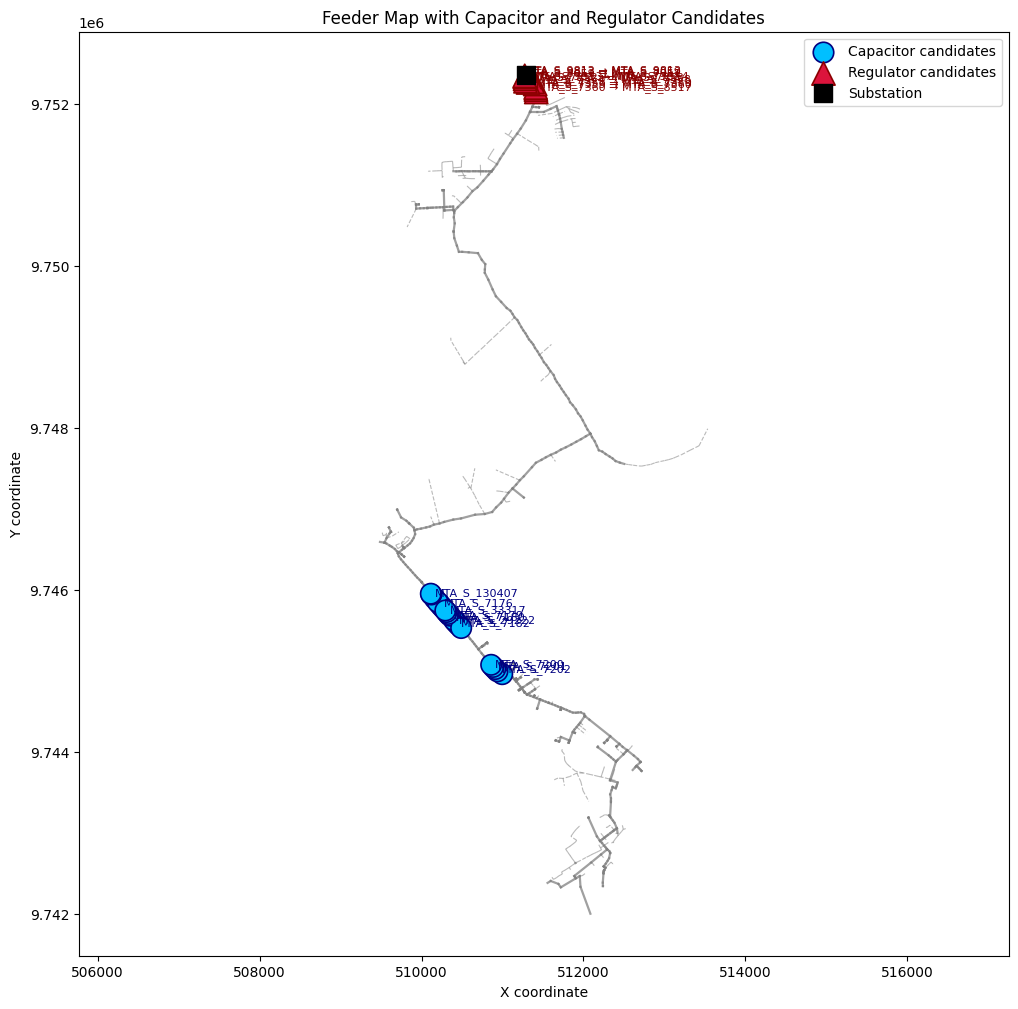

In [40]:
plot_feeder_with_candidates(
    topology=topology,
    segments_df=segments_df,
    cap_candidates=cap_candidates,
    reg_plot_df=reg_plot_df,
    root_bus=topology["root_bus"],
    show_cap_labels=True,
    show_reg_labels=True,
    max_cap_labels=10,
    max_reg_labels=10,
    figsize=(12, 12)
)

In [41]:
# ------------------------------------------------------------------
# BUILD A VOLTAGE-COLORED BRANCH TABLE
# This code assigns a voltage value to each plotted feeder segment
# A practical and robust choice is to use the minimum p.u. voltage of the
# two endpoint buses
# ------------------------------------------------------------------
def build_voltage_segments_table(segments_df: pd.DataFrame,
                                 df_bus_case: pd.DataFrame) -> pd.DataFrame:
    """
    Add endpoint voltages and a plotting voltage to each feeder segment.

    Voltage assigned to each segment:
        v_plot = min(v_pu_min at bus1, v_pu_min at bus2)

    Parameters
    ----------
    segments_df : pd.DataFrame
        Output of build_segments_from_topology(topology)

    df_bus_case : pd.DataFrame
        Bus table merged with voltage results.
        Must contain columns:
            bus, v_pu_min

    Returns
    -------
    pd.DataFrame
        segments_df enriched with:
            v_from, v_to, v_plot
    """
    seg = segments_df.copy()

    bus_v = df_bus_case[["bus", "v_pu_min"]].copy()
    bus_v["bus"] = bus_v["bus"].astype(str).str.upper()

    v_from = bus_v.rename(columns={
        "bus": "bus1",
        "v_pu_min": "v_from"
    })

    v_to = bus_v.rename(columns={
        "bus": "bus2",
        "v_pu_min": "v_to"
    })

    seg["bus1"] = seg["bus1"].astype(str).str.upper()
    seg["bus2"] = seg["bus2"].astype(str).str.upper()

    seg = seg.merge(v_from, on="bus1", how="left")
    seg = seg.merge(v_to, on="bus2", how="left")

    seg["v_plot"] = np.fmin(seg["v_from"], seg["v_to"])

    return seg


segments_v_df = build_voltage_segments_table(segments_df, df_bus_case)

print("Voltage segments ready:", len(segments_v_df))
segments_v_df[["line", "bus1", "bus2", "v_from", "v_to", "v_plot"]].head()

# ------------------------------------------------------------------
# PLOT FEEDER COLORED BY VOLTAGE WITH CAPACITOR/REGULATOR OVERLAYS
# This code creates the second map:
# - feeder segments colored by voltage
# - capacitor candidates overlaid as blue circles
# - regulator candidates overlais as red triangles
# - substation as black square
# - colorbar included
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

def plot_voltage_map_with_candidates(topology: dict,
                                     segments_v_df: pd.DataFrame,
                                     cap_candidates: pd.DataFrame,
                                     reg_plot_df: pd.DataFrame,
                                     root_bus: str = None,
                                     cmap_name: str = "turbo",
                                     vmin: float = 0.90,
                                     vmax: float = 1.02,
                                     show_cap_labels: bool = False,
                                     show_reg_labels: bool = False,
                                     max_cap_labels: int = 10,
                                     max_reg_labels: int = 10,
                                     figsize=(12, 12)):
    """
    Plot feeder geographically with branch color representing voltage, and
    capacitor/regulator candidates overlaid.

    Parameters
    ----------
    topology : dict
    segments_v_df : pd.DataFrame
        Output of build_voltage_segments_table(...)
    cap_candidates : pd.DataFrame
    reg_plot_df : pd.DataFrame
    root_bus : str or None
    cmap_name : str
        Matplotlib colormap name
    vmin, vmax : float
        Voltage range for color normalization
    show_cap_labels, show_reg_labels : bool
    max_cap_labels, max_reg_labels : int
    figsize : tuple
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    if root_bus is None:
        root_bus = topology["root_bus"]
    root_bus = str(root_bus).upper()

    # Capacitor candidate coordinates
    cap_plot = cap_candidates.copy()
    cap_plot["bus"] = cap_plot["bus"].astype(str).str.upper()
    cap_plot = cap_plot.merge(coords_df[["bus", "x", "y"]], on="bus", how="left")

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = get_cmap(cmap_name)

    fig, ax = plt.subplots(figsize=figsize)

    # -------------------------------------------------
    # 1. Plot feeder colored by voltage
    # -------------------------------------------------
    for _, row in segments_v_df.iterrows():
        x = [row["x_from"], row["x_to"]]
        y = [row["y_from"], row["y_to"]]

        v = row["v_plot"]
        if pd.isna(v):
            color = "lightgray"
            alpha = 0.45
        else:
            color = cmap(norm(v))
            alpha = 0.95

        if row.get("phases", np.nan) == 3:
            lw = 2.0
            style = "-"
        else:
            lw = 1.0
            style = "--"

        ax.plot(x, y, color=color, linestyle=style, linewidth=lw, alpha=alpha, zorder=1)

    # -------------------------------------------------
    # 2. Overlay capacitor candidates
    # -------------------------------------------------
    if not cap_plot.empty:
        ax.scatter(
            cap_plot["x"],
            cap_plot["y"],
            s=95,
            marker="o",
            facecolor="deepskyblue",
            edgecolor="navy",
            linewidth=1.2,
            zorder=5,
            label="Capacitor candidates"
        )

        if show_cap_labels:
            for _, row in cap_plot.head(max_cap_labels).iterrows():
                ax.text(
                    row["x"], row["y"],
                    str(row["bus"]),
                    fontsize=8,
                    color="navy",
                    ha="left",
                    va="bottom",
                    zorder=6
                )

    # -------------------------------------------------
    # 3. Overlay regulator candidates
    # -------------------------------------------------
    if reg_plot_df is not None and not reg_plot_df.empty:
        ax.scatter(
            reg_plot_df["xm"],
            reg_plot_df["ym"],
            s=145,
            marker="^",
            facecolor="crimson",
            edgecolor="darkred",
            linewidth=1.2,
            zorder=6,
            label="Regulator candidates"
        )

        if show_reg_labels:
            for _, row in reg_plot_df.head(max_reg_labels).iterrows():
                label = f"{row['parent_bus']} → {row['bus']}"
                ax.text(
                    row["xm"], row["ym"],
                    label,
                    fontsize=8,
                    color="darkred",
                    ha="left",
                    va="bottom",
                    zorder=7
                )

    # -------------------------------------------------
    # 4. Plot substation
    # -------------------------------------------------
    sub = coords_df[coords_df["bus"] == root_bus]
    if not sub.empty:
        ax.scatter(
            sub["x"],
            sub["y"],
            s=180,
            marker="s",
            facecolor="black",
            edgecolor="black",
            zorder=8,
            label="Substation"
        )

    # -------------------------------------------------
    # 5. Colorbar
    # -------------------------------------------------
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Voltage (pu)")

    # -------------------------------------------------
    # 6. Formatting
    # -------------------------------------------------
    ax.set_title("Feeder Voltage Map with Capacitor and Regulator Candidates")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.axis("equal")
    ax.legend(loc="best")
    plt.show()

Voltage segments ready: 1430


Final plotting call

What this second map means: This new figure is useful because it combines

*  **system condition:** feeder colored by voltage
*  **intervention options:** blue circles = capacitor candidate buses, red triangles = regulator candidate sections

This lets you see, for example:

*  whether capacitor candidates are clustering in low voltage regions
*  whether regulator candidates are located just upstream of weak downstream corridors
*  whether both candidate types are addressing the same area or different areas

PRACTICAL NOTE: this voltage map uses:

$$
v_{\text {plot }}=\min \left(v_{\text {from }}, v_{\text {to }}\right)
$$

for each segment. That is a conservative and readable choice.


/tmp/ipykernel_862/1566592733.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


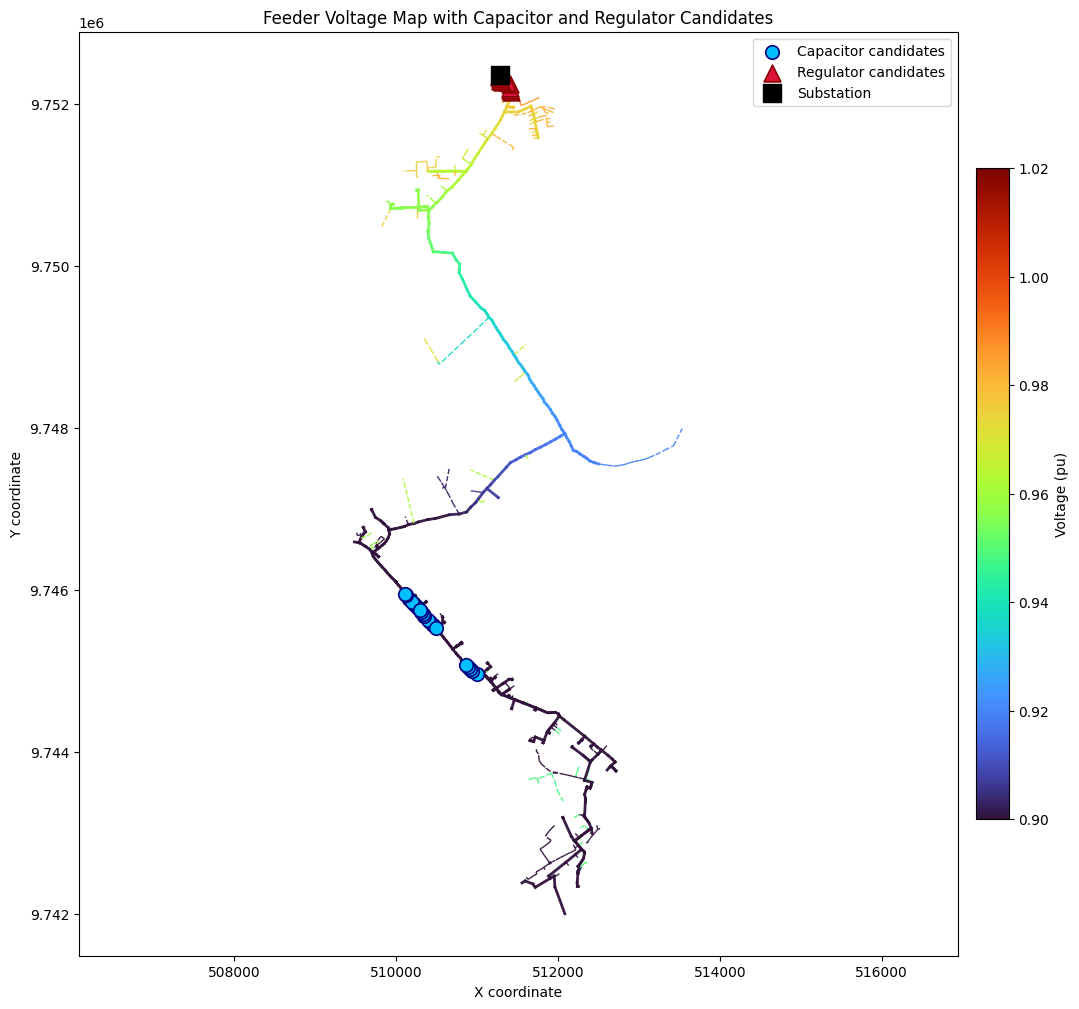

In [43]:
plot_voltage_map_with_candidates(
    topology=topology,
    segments_v_df=segments_v_df,
    cap_candidates=cap_candidates,
    reg_plot_df=reg_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="turbo",
    vmin=0.90,
    vmax=1.02,
    show_cap_labels=False,
    show_reg_labels=False,
    max_cap_labels=10,
    max_reg_labels=10,
    figsize=(12, 12)
)

VISUALIZING THE IMPROVED SCENARIO WITH CAPACITOR

In the following section we test the capacitor candidate of our choosing from the list of candidates originated previously. We do the following:

* choose one capacitor candidate. Use either: its q_down_kvar automatically, or
a manual kVAr value for tuning

* recompile the feeder

* add the capacitor from Python

* solve

* extract updated voltages

* compute comparison metrics against the base case
* build the voltage-colored segment table for the new scenario

In [45]:
# CELL 1: User tuning parameters-----------------------------------------------
# ============================================================
# SINGLE CAPACITOR SCENARIO - USER SETTINGS
# ============================================================

# Choose which ranked capacitor candidate to test
# 0 = best candidate, 1 = second best, etc.
CAP_CANDIDATE_INDEX = 0

# ------------------------------------------------------------
# Capacitor size mode
# ------------------------------------------------------------
# If True  -> use q_down_kvar from cap_candidates
# If False -> use MANUAL_CAP_KVAR below
USE_CANDIDATE_QDOWN_AS_KVAR = True

# >>> USER TUNING PARAMETER <<<
# Manual capacitor size in kVAr (used only if USE_CANDIDATE_QDOWN_AS_KVAR = False)
MANUAL_CAP_KVAR = 300.0

# Optional cap on automatic kvar to avoid unrealistic oversized banks
# Set to None if you do not want any cap
MAX_AUTO_CAP_KVAR = None   # example: 1200.0

# Capacitor connection type
CAP_CONN = "wye"

# Scenario name prefix
CAP_SCENARIO_NAME = "CAP_TEST"

print("Single capacitor scenario settings loaded.")


# CELL 2: Helper functions for capacitor scenario ------------------------------
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

def get_bus_phase_info_from_dss(dss, bus_name: str):
    """
    Read active phases and base voltage from an OpenDSS bus.

    Parameters
    ----------
    dss : opendssdirect module
    bus_name : str

    Returns
    -------
    dict
        {
            "bus": ...,
            "nodes": [...],
            "phases": [...],      # only 1,2,3
            "n_phases": int,
            "kvbase_ln": float,   # line-to-neutral base kV if available
            "kv_rated_cap": float # capacitor rated kV to use
        }
    """
    dss.Circuit.SetActiveBus(bus_name)

    nodes = dss.Bus.Nodes()
    phases = sorted([int(n) for n in nodes if int(n) in [1, 2, 3]])
    n_phases = len(phases)

    kvbase_ln = dss.Bus.kVBase()   # OpenDSS bus base is typically line-neutral

    # Practical assumption for capacitor rating:
    # - 1-phase capacitor: use line-neutral kV
    # - 2-phase / 3-phase capacitor: use line-line kV = LN * sqrt(3)
    if kvbase_ln is None or kvbase_ln == 0:
        kv_rated_cap = np.nan
    elif n_phases == 1:
        kv_rated_cap = kvbase_ln
    else:
        kv_rated_cap = kvbase_ln * math.sqrt(3)

    return {
        "bus": bus_name,
        "nodes": nodes,
        "phases": phases,
        "n_phases": n_phases,
        "kvbase_ln": kvbase_ln,
        "kv_rated_cap": kv_rated_cap
    }


def choose_capacitor_kvar(candidate_row: pd.Series,
                          use_candidate_qdown: bool = True,
                          manual_kvar: float = 300.0,
                          max_auto_cap_kvar: float | None = None) -> float:
    """
    Choose capacitor kvar using either q_down_kvar from the candidate table
    or a user-specified manual value.

    Parameters
    ----------
    candidate_row : pd.Series
        Row from cap_candidates
    use_candidate_qdown : bool
    manual_kvar : float
    max_auto_cap_kvar : float or None

    Returns
    -------
    float
        Selected capacitor size in kVAr
    """
    if use_candidate_qdown:
        kvar = float(candidate_row["q_down_kvar"])
        if max_auto_cap_kvar is not None:
            kvar = min(kvar, float(max_auto_cap_kvar))
    else:
        kvar = float(manual_kvar)

    return kvar


def add_test_capacitor_from_python(dss,
                                   bus_name: str,
                                   kvar_value: float,
                                   cap_name: str = "CAP_TEST",
                                   conn: str = "wye"):
    """
    Add a shunt capacitor at an existing bus using OpenDSS text interface.

    Parameters
    ----------
    dss : opendssdirect module
    bus_name : str
    kvar_value : float
    cap_name : str
    conn : str

    Returns
    -------
    dict
        Information about the inserted capacitor
    """
    info = get_bus_phase_info_from_dss(dss, bus_name)

    n_phases = info["n_phases"]
    kv_rated = info["kv_rated_cap"]

    if n_phases < 1:
        raise ValueError(f"Bus {bus_name} has no valid phase information for capacitor insertion.")

    if pd.isna(kv_rated) or kv_rated <= 0:
        raise ValueError(f"Bus {bus_name} has invalid base voltage for capacitor insertion.")

    cmd = (
        f"New Capacitor.{cap_name} "
        f"bus1={bus_name} "
        f"phases={n_phases} "
        f"conn={conn} "
        f"kV={kv_rated:.6f} "
        f"kvar={kvar_value:.6f}"
    )

    dss.Text.Command(cmd)

    return {
        "cap_name": cap_name,
        "bus": bus_name,
        "n_phases": n_phases,
        "phases": info["phases"],
        "kv_rated": kv_rated,
        "kvar": kvar_value,
        "command": cmd
    }


def summarize_voltage_metrics(df_bus_case_in: pd.DataFrame,
                              vmin_limit: float = 0.95,
                              vmax_limit: float = 1.05) -> dict:
    """
    Compute basic voltage compliance metrics.

    Parameters
    ----------
    df_bus_case_in : pd.DataFrame
        Must contain column v_pu_min and preferably v_pu_max

    Returns
    -------
    dict
    """
    out = {}

    out["vmin"] = float(df_bus_case_in["v_pu_min"].min())
    out["vmax"] = float(df_bus_case_in["v_pu_max"].max()) if "v_pu_max" in df_bus_case_in.columns else np.nan
    out["n_under"] = int((df_bus_case_in["v_pu_min"] < vmin_limit).sum())

    if "v_pu_max" in df_bus_case_in.columns:
        out["n_over"] = int((df_bus_case_in["v_pu_max"] > vmax_limit).sum())
    else:
        out["n_over"] = np.nan

    return out


def get_total_losses_from_dss(dss) -> dict:
    """
    Read total circuit losses from OpenDSS.

    Returns
    -------
    dict
        {
            "p_loss_kw": ...,
            "q_loss_kvar": ...
        }
    """
    losses = dss.Circuit.Losses()   # [W, var]
    p_loss_kw = losses[0] / 1000.0
    q_loss_kvar = losses[1] / 1000.0

    return {
        "p_loss_kw": p_loss_kw,
        "q_loss_kvar": q_loss_kvar
    }

# CELL 2B: Line-loss extraction and loss-density segments ----------------------
def normalize_line_name_for_merge(line_name: str) -> str:
    """
    Normalize OpenDSS line names so they match the 'line' column in segments_df.

    Examples
    --------
    'N_7160_MTA' -> '7160_MTA'
    '7160_MTA'   -> '7160_MTA'
    """
    if line_name is None:
        return None

    s = str(line_name).strip().upper()
    if s.startswith("N_"):
        s = s[2:]
    return s


def extract_line_losses_from_dss(dss) -> pd.DataFrame:
    """
    Extract per-line losses from the currently active OpenDSS solved circuit.

    Returns
    -------
    pd.DataFrame
        Columns:
            line_dss, line, bus1, bus2, p_loss_kw, q_loss_kvar
    """
    rows = []

    all_lines = dss.Lines.AllNames()
    for ln in all_lines:
        if ln is None:
            continue

        ln = str(ln).strip()
        if ln == "" or ln.lower() == "none":
            continue

        # Activate line
        dss.Lines.Name(ln)

        # Losses of active CktElement
        losses = dss.CktElement.Losses()   # [W, var]

        bus1_raw = dss.Lines.Bus1()
        bus2_raw = dss.Lines.Bus2()

        row = {
            "line_dss": str(ln).upper(),
            "line": normalize_line_name_for_merge(ln),
            "bus1": normalize_bus_name(bus1_raw),
            "bus2": normalize_bus_name(bus2_raw),
            "p_loss_kw": losses[0] / 1000.0,
            "q_loss_kvar": losses[1] / 1000.0
        }
        rows.append(row)

    return pd.DataFrame(rows)


def build_loss_density_segments_table(segments_df: pd.DataFrame,
                                      df_line_losses: pd.DataFrame) -> pd.DataFrame:
    """
    Merge line losses into the geographic feeder segments table.

    Parameters
    ----------
    segments_df : pd.DataFrame
        Output of build_segments_from_topology(topology)

    df_line_losses : pd.DataFrame
        Output of extract_line_losses_from_dss(dss)

    Returns
    -------
    pd.DataFrame
        segments_df enriched with:
            p_loss_kw, q_loss_kvar, loss_density_kw_per_km
    """
    seg = segments_df.copy()
    loss_df = df_line_losses.copy()

    seg["line"] = seg["line"].astype(str).str.upper()
    loss_df["line"] = loss_df["line"].astype(str).str.upper()

    seg = seg.merge(
        loss_df[["line", "p_loss_kw", "q_loss_kvar"]],
        on="line",
        how="left"
    )

    seg["loss_density_kw_per_km"] = np.where(
        seg["length_km"] > 0,
        seg["p_loss_kw"] / seg["length_km"],
        np.nan
    )

    return seg

# CELL 3: Build a base reference snapshot including loss-density----------------
# ============================================================
# BASE CASE SNAPSHOT FOR COMPARISON
# ============================================================

# ============================================================
# BASE CASE SNAPSHOT FOR COMPARISON
# ============================================================

# FORCE CLEAN BASE NETWORK
master_file = os.path.join(feeder_path, "Master.dss")
dss.Text.Command(f'compile "{master_file}"')
dss.Solution.Solve()

if not dss.Solution.Converged():
    raise RuntimeError("Base feeder did not converge when building BASE_CASE_RESULTS.")

# Base voltages
df_v_base = extract_bus_voltages_from_dss(dss, topology["bus_table"])
df_bus_case_base = topology["bus_table"].merge(df_v_base, on="bus", how="left")

# Base voltage metrics
base_voltage_metrics = summarize_voltage_metrics(
    df_bus_case_base,
    vmin_limit=0.95,
    vmax_limit=1.05
)

# Base losses
base_loss_metrics = get_total_losses_from_dss(dss)

# Base voltage-colored segments
segments_v_base = build_voltage_segments_table(segments_df, df_bus_case_base)

# Base line-loss / loss-density segments
df_line_losses_base = extract_line_losses_from_dss(dss)
segments_loss_base = build_loss_density_segments_table(segments_df, df_line_losses_base)

BASE_CASE_RESULTS = {
    "df_bus_case": df_bus_case_base.copy(),
    "voltage_metrics": base_voltage_metrics.copy(),
    "loss_metrics": base_loss_metrics.copy(),
    "segments_v_df": segments_v_base.copy(),
    "line_losses_df": df_line_losses_base.copy(),
    "segments_loss_df": segments_loss_base.copy(),
}

print("Base case snapshot stored.")
print("Base voltage metrics:", base_voltage_metrics)
print("Base loss metrics:", base_loss_metrics)


# CELL 4: Single capacitor scenario engine including loss-density --------------
def run_single_capacitor_candidate_scenario(dss,
                                            feeder_path: str,
                                            topology: dict,
                                            cap_candidates: pd.DataFrame,
                                            segments_df: pd.DataFrame,
                                            candidate_index: int = 0,
                                            use_candidate_qdown: bool = True,
                                            manual_kvar: float = 300.0,
                                            max_auto_cap_kvar: float | None = None,
                                            conn: str = "wye",
                                            scenario_name: str = "CAP_TEST",
                                            vmin_limit: float = 0.95,
                                            vmax_limit: float = 1.05):
    """
    Run one capacitor perturbation-validation scenario.

    Workflow
    --------
    1) Recompile base feeder
    2) Solve base feeder
    3) Insert one test capacitor at selected candidate bus
    4) Solve again
    5) Extract new voltages and losses
    6) Compare against BASE_CASE_RESULTS
    """
    # --------------------------------------------------------
    # 1. Candidate row
    # --------------------------------------------------------
    if candidate_index < 0 or candidate_index >= len(cap_candidates):
        raise IndexError("candidate_index is outside the available cap_candidates range.")

    cand = cap_candidates.iloc[candidate_index].copy()
    bus_name = str(cand["bus"]).upper()

    kvar_value = choose_capacitor_kvar(
        candidate_row=cand,
        use_candidate_qdown=use_candidate_qdown,
        manual_kvar=manual_kvar,
        max_auto_cap_kvar=max_auto_cap_kvar
    )

    # --------------------------------------------------------
    # 2. Reset network cleanly
    # --------------------------------------------------------
    master_file = os.path.join(feeder_path, "Master.dss")
    dss.Text.Command(f'compile "{master_file}"')
    dss.Solution.Solve()

    if not dss.Solution.Converged():
        raise RuntimeError("Base feeder did not converge after recompiling Master.dss.")

    # --------------------------------------------------------
    # 3. Insert capacitor
    # --------------------------------------------------------
    cap_info = add_test_capacitor_from_python(
        dss=dss,
        bus_name=bus_name,
        kvar_value=kvar_value,
        cap_name=scenario_name,
        conn=conn
    )

    # --------------------------------------------------------
    # 4. Solve scenario
    # --------------------------------------------------------
    dss.Solution.Solve()
    converged = bool(dss.Solution.Converged())

    if not converged:
        print("Warning: scenario did not converge.")
        return {
            "scenario_type": "CAPACITOR",
            "candidate_index": candidate_index,
            "candidate_row": cand,
            "cap_info": cap_info,
            "converged": False
        }

    # --------------------------------------------------------
    # 5. Extract scenario outputs
    # --------------------------------------------------------
    df_v_new = extract_bus_voltages_from_dss(dss, topology["bus_table"])
    df_bus_case_new = topology["bus_table"].merge(df_v_new, on="bus", how="left")

    new_voltage_metrics = summarize_voltage_metrics(
        df_bus_case_new,
        vmin_limit=vmin_limit,
        vmax_limit=vmax_limit
    )

    new_loss_metrics = get_total_losses_from_dss(dss)

    # Voltage-colored segments
    segments_v_new = build_voltage_segments_table(segments_df, df_bus_case_new)

    # Line-loss / loss-density segments
    df_line_losses_new = extract_line_losses_from_dss(dss)
    segments_loss_new = build_loss_density_segments_table(segments_df, df_line_losses_new)

    # --------------------------------------------------------
    # 6. Compare with base case
    # --------------------------------------------------------
    base_v = BASE_CASE_RESULTS["voltage_metrics"]
    base_l = BASE_CASE_RESULTS["loss_metrics"]

    comparison = {
        "delta_vmin": new_voltage_metrics["vmin"] - base_v["vmin"],
        "delta_vmax": new_voltage_metrics["vmax"] - base_v["vmax"] if pd.notna(new_voltage_metrics["vmax"]) and pd.notna(base_v["vmax"]) else np.nan,
        "delta_n_under": new_voltage_metrics["n_under"] - base_v["n_under"],
        "delta_n_over": new_voltage_metrics["n_over"] - base_v["n_over"] if pd.notna(new_voltage_metrics["n_over"]) and pd.notna(base_v["n_over"]) else np.nan,
        "delta_p_loss_kw": new_loss_metrics["p_loss_kw"] - base_l["p_loss_kw"],
        "pct_p_loss_change": (
            100.0 * (new_loss_metrics["p_loss_kw"] - base_l["p_loss_kw"]) / base_l["p_loss_kw"]
            if base_l["p_loss_kw"] != 0 else np.nan
        )
    }

    result = {
        "scenario_type": "CAPACITOR",
        "candidate_index": candidate_index,
        "candidate_row": cand,
        "cap_info": cap_info,
        "converged": converged,
        "df_bus_case": df_bus_case_new,
        "segments_v_df": segments_v_new,
        "line_losses_df": df_line_losses_new,
        "segments_loss_df": segments_loss_new,
        "voltage_metrics": new_voltage_metrics,
        "loss_metrics": new_loss_metrics,
        "comparison": comparison
    }

    return result

Single capacitor scenario settings loaded.
Base case snapshot stored.
Base voltage metrics: {'vmin': 0.8484748919320124, 'vmax': 0.9899691809828899, 'n_under': 930, 'n_over': 0}
Base loss metrics: {'p_loss_kw': 260.2918834292649, 'q_loss_kvar': 358.8943409941381}


In [46]:
# CELL 5: Run one capacitor scenario -------------------------------------------
cap_result_1 = run_single_capacitor_candidate_scenario(
    dss=dss,
    feeder_path=feeder_path,
    topology=topology,
    cap_candidates=cap_candidates,
    segments_df=segments_df,
    candidate_index=CAP_CANDIDATE_INDEX,
    use_candidate_qdown=USE_CANDIDATE_QDOWN_AS_KVAR,
    manual_kvar=MANUAL_CAP_KVAR,
    max_auto_cap_kvar=MAX_AUTO_CAP_KVAR,
    conn=CAP_CONN,
    scenario_name=CAP_SCENARIO_NAME,
    vmin_limit=0.95,
    vmax_limit=1.05
)

print("Scenario converged:", cap_result_1["converged"])
print("Capacitor info:")
print(cap_result_1["cap_info"])
print("\nNew voltage metrics:")
print(cap_result_1["voltage_metrics"])
print("\nNew loss metrics:")
print(cap_result_1["loss_metrics"])
print("\nComparison vs base:")
print(cap_result_1["comparison"])

Scenario converged: True
Capacitor info:
{'cap_name': 'CAP_TEST', 'bus': 'MTA_S_29222', 'n_phases': 3, 'phases': [1, 2, 3], 'kv_rated': 13.8, 'kvar': 427.400326, 'command': 'New Capacitor.CAP_TEST bus1=MTA_S_29222 phases=3 conn=wye kV=13.800000 kvar=427.400326'}

New voltage metrics:
{'vmin': 0.8564121865181648, 'vmax': 0.9929351381092156, 'n_under': 844, 'n_over': 0}

New loss metrics:
{'p_loss_kw': 261.5538740584623, 'q_loss_kvar': 360.5098761091423}

Comparison vs base:
{'delta_vmin': 0.007937294586152333, 'delta_vmax': 0.0029659571263257467, 'delta_n_under': -86, 'delta_n_over': 0, 'delta_p_loss_kw': 1.2619906291974416, 'pct_p_loss_change': 0.4848367196745078}


In [47]:
# ------------------------------------------------------------
# VERIFY THAT BASE AND IMPROVED RESULTS ARE DIFFERENT
# ------------------------------------------------------------

tested_bus = cap_result_1["cap_info"]["bus"]

base_df = BASE_CASE_RESULTS["df_bus_case"].copy()
new_df = cap_result_1["df_bus_case"].copy()

base_df["bus"] = base_df["bus"].astype(str).str.upper()
new_df["bus"] = new_df["bus"].astype(str).str.upper()

tested_bus = str(tested_bus).upper()

# 1) Compare global metrics
print("=== GLOBAL METRICS ===")
print("Base voltage metrics :", BASE_CASE_RESULTS["voltage_metrics"])
print("New  voltage metrics :", cap_result_1["voltage_metrics"])
print()
print("Base loss metrics    :", BASE_CASE_RESULTS["loss_metrics"])
print("New  loss metrics    :", cap_result_1["loss_metrics"])
print()
print("Comparison           :", cap_result_1["comparison"])
print()

# 2) Compare tested bus voltage directly
base_row = base_df[base_df["bus"] == tested_bus]
new_row = new_df[new_df["bus"] == tested_bus]

print("=== TESTED BUS CHECK ===")
print("Tested capacitor bus:", tested_bus)

if not base_row.empty and not new_row.empty:
    print("Base v_pu_min:", float(base_row["v_pu_min"].iloc[0]))
    print("New  v_pu_min:", float(new_row["v_pu_min"].iloc[0]))
    print("Delta         :", float(new_row["v_pu_min"].iloc[0] - base_row["v_pu_min"].iloc[0]))
else:
    print("Tested bus not found in one of the result tables.")

# 3) Check if full voltage arrays are identical
merged_check = base_df[["bus", "v_pu_min"]].merge(
    new_df[["bus", "v_pu_min"]],
    on="bus",
    suffixes=("_base", "_new")
)

merged_check["dv"] = merged_check["v_pu_min_new"] - merged_check["v_pu_min_base"]

print()
print("=== WHOLE FEEDER CHECK ===")
print("Maximum absolute voltage difference:", merged_check["dv"].abs().max())
print("Mean absolute voltage difference   :", merged_check["dv"].abs().mean())
print("Number of buses with |ΔV| > 1e-6   :", int((merged_check["dv"].abs() > 1e-6).sum()))

display(merged_check.sort_values("dv", ascending=False).head(10))

=== GLOBAL METRICS ===
Base voltage metrics : {'vmin': 0.8484748919320124, 'vmax': 0.9899691809828899, 'n_under': 930, 'n_over': 0}
New  voltage metrics : {'vmin': 0.8564121865181648, 'vmax': 0.9929351381092156, 'n_under': 844, 'n_over': 0}

Base loss metrics    : {'p_loss_kw': 260.2918834292649, 'q_loss_kvar': 358.8943409941381}
New  loss metrics    : {'p_loss_kw': 261.5538740584623, 'q_loss_kvar': 360.5098761091423}

Comparison           : {'delta_vmin': 0.007937294586152333, 'delta_vmax': 0.0029659571263257467, 'delta_n_under': -86, 'delta_n_over': 0, 'delta_p_loss_kw': 1.2619906291974416, 'pct_p_loss_change': 0.4848367196745078}

=== TESTED BUS CHECK ===
Tested capacitor bus: MTA_S_29222
Base v_pu_min: 0.8808839329652042
New  v_pu_min: 0.8891724005095428
Delta         : 0.008288467544338651

=== WHOLE FEEDER CHECK ===
Maximum absolute voltage difference: 0.012983969100766268
Mean absolute voltage difference   : 0.007179368392560308
Number of buses with |ΔV| > 1e-6   : 1430


,bus,v_pu_min_base,v_pu_min_new,dv
1182,MTA_S_7940,0.949533,0.962517,0.012984
31,MTA_L_7939,0.949534,0.962518,0.012984
1181,MTA_S_7939,0.949550,0.962534,0.012984
1100,MTA_S_7440,0.949572,0.962555,0.012984
483,MTA_S_33469,0.949597,0.962580,0.012983
482,MTA_S_33468,0.949598,0.962581,0.012983
1218,MTA_S_7990,0.949511,0.962494,0.012983
51,MTA_L_7989,0.949511,0.962494,0.012983
1217,MTA_S_7989,0.949513,0.962496,0.012983
1138,MTA_S_7496,0.949513,0.962496,0.012983


In [48]:
print("=== ACTIVE OPENdSS CAPACITOR CHECK ===")

try:
    cap_names = dss.Capacitors.AllNames()
    print("Capacitors in active circuit:", cap_names)
except Exception as e:
    print("Could not read capacitor list:", e)

print()
print("Inserted capacitor info from scenario:")
print(cap_result_1["cap_info"])

=== ACTIVE OPENdSS CAPACITOR CHECK ===
Capacitors in active circuit: ['c_7', 'cap_test']

Inserted capacitor info from scenario:
{'cap_name': 'CAP_TEST', 'bus': 'MTA_S_29222', 'n_phases': 3, 'phases': [1, 2, 3], 'kv_rated': 13.8, 'kvar': 427.400326, 'command': 'New Capacitor.CAP_TEST bus1=MTA_S_29222 phases=3 conn=wye kV=13.800000 kvar=427.400326'}


In [49]:
#CELL 6: Compact comparison table ----------------------------------------------
def build_single_scenario_summary_table(cap_result: dict) -> pd.DataFrame:
    """
    Build a compact one-row summary table for the tested capacitor scenario.
    """
    cand = cap_result["candidate_row"]
    cap_info = cap_result["cap_info"]
    vm = cap_result["voltage_metrics"]
    lm = cap_result["loss_metrics"]
    cmp = cap_result["comparison"]

    row = {
        "scenario_type": cap_result["scenario_type"],
        "candidate_index": cap_result["candidate_index"],
        "candidate_bus": cand["bus"],
        "candidate_q_down_kvar": cand["q_down_kvar"],
        "kvar_inserted": cap_info["kvar"],
        "n_phases": cap_info["n_phases"],
        "kv_rated": cap_info["kv_rated"],
        "vmin_new": vm["vmin"],
        "vmax_new": vm["vmax"],
        "n_under_new": vm["n_under"],
        "n_over_new": vm["n_over"],
        "p_loss_kw_new": lm["p_loss_kw"],
        "delta_vmin": cmp["delta_vmin"],
        "delta_n_under": cmp["delta_n_under"],
        "delta_p_loss_kw": cmp["delta_p_loss_kw"],
        "pct_p_loss_change": cmp["pct_p_loss_change"],
        "converged": cap_result["converged"]
    }

    return pd.DataFrame([row])


cap_summary_1 = build_single_scenario_summary_table(cap_result_1)
cap_summary_1

,scenario_type,candidate_index,candidate_bus,candidate_q_down_kvar,kvar_inserted,n_phases,kv_rated,vmin_new,vmax_new,n_under_new,n_over_new,p_loss_kw_new,delta_vmin,delta_n_under,delta_p_loss_kw,pct_p_loss_change,converged
0,CAPACITOR,0,MTA_S_29222,427.400326,427.400326,3,13.8,0.856412,0.992935,844,0,261.553874,0.007937,-86,1.261991,0.484837,True


In [50]:
#CELL 7: helper for the tested capacitor location-------------------------------
def build_tested_capacitor_plot_table(cap_result: dict,
                                      topology: dict) -> pd.DataFrame:
    """
    Build a one-row plotting table for the actually tested capacitor location.

    Parameters
    ----------
    cap_result : dict
        Output of run_single_capacitor_candidate_scenario(...)
    topology : dict

    Returns
    -------
    pd.DataFrame
        Columns:
            bus, x, y, kvar, candidate_index
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    tested_bus = str(cap_result["cap_info"]["bus"]).upper()
    tested_kvar = float(cap_result["cap_info"]["kvar"])
    candidate_index = int(cap_result["candidate_index"])

    out = coords_df[coords_df["bus"] == tested_bus][["bus", "x", "y"]].copy()
    out["kvar"] = tested_kvar
    out["candidate_index"] = candidate_index

    return out.reset_index(drop=True)

# Side-by-side plotting functions ----------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

def plot_voltage_profile_side_by_side(base_df_bus_case: pd.DataFrame,
                                      new_df_bus_case: pd.DataFrame,
                                      tested_cap_plot_df: pd.DataFrame | None = None,
                                      title_left: str = "Base Case",
                                      title_right: str = "Improved Case",
                                      base_color: str = "royalblue",
                                      new_color: str = "royalblue",
                                      figsize=(14, 5)):
    """
    Plot voltage profile in two panels:
    - left: base case
    - right: improved case

    The tested capacitor location is shown as a vertical guide line if possible.
    """
    b = base_df_bus_case.sort_values("distance_km").copy()
    n = new_df_bus_case.sort_values("distance_km").copy()

    # Try to identify capacitor bus distance for marker line
    tested_bus = None
    tested_dist = None
    if tested_cap_plot_df is not None and not tested_cap_plot_df.empty:
        tested_bus = str(tested_cap_plot_df.iloc[0]["bus"]).upper()
        if tested_bus in set(base_df_bus_case["bus"].astype(str).str.upper()):
            tested_dist = float(
                base_df_bus_case.loc[
                    base_df_bus_case["bus"].astype(str).str.upper() == tested_bus,
                    "distance_km"
                ].iloc[0]
            )

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # -------------------------------------------------
    # Left: base
    # -------------------------------------------------
    ax = axes[0]
    ax.scatter(
        b["distance_km"], b["v_pu_min"],
        s=10, color=base_color, alpha=0.85
    )
    ax.axhline(0.95, color="red", linestyle="--", linewidth=1.2)
    ax.axhline(1.05, color="red", linestyle="--", linewidth=1.2)

    if tested_dist is not None:
        ax.axvline(tested_dist, color="deepskyblue", linestyle="--", linewidth=1.5, alpha=0.9)
        ax.text(
            tested_dist, 1.045,
            f"Cap @ {tested_bus}",
            color="navy", fontsize=8,
            ha="left", va="top", rotation=90
        )

    ax.set_title(title_left)
    ax.set_xlabel("Electrical distance from source (km)")
    ax.set_ylabel("Voltage (pu)")
    ax.grid(True, alpha=0.25)

    # -------------------------------------------------
    # Right: improved
    # -------------------------------------------------
    ax = axes[1]
    ax.scatter(
        n["distance_km"], n["v_pu_min"],
        s=10, color=new_color, alpha=0.90
    )
    ax.axhline(0.95, color="red", linestyle="--", linewidth=1.2)
    ax.axhline(1.05, color="red", linestyle="--", linewidth=1.2)

    if tested_dist is not None:
        ax.axvline(tested_dist, color="deepskyblue", linestyle="--", linewidth=1.5, alpha=0.9)
        ax.text(
            tested_dist, 1.045,
            f"Cap @ {tested_bus}",
            color="navy", fontsize=8,
            ha="left", va="top", rotation=90
        )

    ax.set_title(title_right)
    ax.set_xlabel("Electrical distance from source (km)")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

def plot_voltage_map_side_by_side(topology: dict,
                                  base_segments_v_df: pd.DataFrame,
                                  new_segments_v_df: pd.DataFrame,
                                  tested_cap_plot_df: pd.DataFrame | None = None,
                                  root_bus: str | None = None,
                                  cmap_name: str = "turbo",
                                  vmin: float = 0.90,
                                  vmax: float = 1.02,
                                  figsize=(16, 8)):
    """
    Plot geographic voltage map in two panels:
    - left: base case + tested capacitor location
    - right: improved case + tested capacitor location
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    if root_bus is None:
        root_bus = topology["root_bus"]
    root_bus = str(root_bus).upper()

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.colormaps[cmap_name]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    panel_data = [
        (axes[0], base_segments_v_df, "Base Case"),
        (axes[1], new_segments_v_df, "Improved Case")
    ]

    for ax, seg_df, title in panel_data:
        for _, row in seg_df.iterrows():
            x = [row["x_from"], row["x_to"]]
            y = [row["y_from"], row["y_to"]]

            v = row["v_plot"]
            color = "lightgray" if pd.isna(v) else cmap(norm(v))

            if row.get("phases", np.nan) == 3:
                lw = 2.0
                style = "-"
            else:
                lw = 1.0
                style = "--"

            ax.plot(x, y, color=color, linestyle=style, linewidth=lw, alpha=0.95, zorder=1)

        # Tested capacitor location only
        if tested_cap_plot_df is not None and not tested_cap_plot_df.empty:
            ax.scatter(
                tested_cap_plot_df["x"], tested_cap_plot_df["y"],
                s=120, marker="o",
                facecolor="deepskyblue", edgecolor="navy",
                linewidth=1.4, zorder=5, label="Tested capacitor"
            )

        # Substation
        sub = coords_df[coords_df["bus"] == root_bus]
        if not sub.empty:
            ax.scatter(
                sub["x"], sub["y"],
                s=180, marker="s",
                facecolor="black", edgecolor="black",
                zorder=6, label="Substation"
            )

        ax.set_title(title)
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.set_aspect("equal", adjustable="box")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.030, pad=0.02)
    cbar.set_label("Voltage (pu)")

    handles, labels = axes[1].get_legend_handles_labels()
    if handles:
        axes[1].legend(loc="best")

    plt.subplots_adjust(wspace=0.12, right=0.88)
    plt.show()


def plot_loss_density_map_side_by_side(topology: dict,
                                       base_segments_loss_df: pd.DataFrame,
                                       new_segments_loss_df: pd.DataFrame,
                                       tested_cap_plot_df: pd.DataFrame | None = None,
                                       root_bus: str | None = None,
                                       cmap_name: str = "inferno",
                                       vmax_quantile: float = 0.98,
                                       figsize=(16, 8)):
    """
    Plot geographic loss-density map in two panels:
    - left: base case + tested capacitor location
    - right: improved case + tested capacitor location
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    if root_bus is None:
        root_bus = topology["root_bus"]
    root_bus = str(root_bus).upper()

    valid_base = base_segments_loss_df["loss_density_kw_per_km"].dropna()
    valid_new = new_segments_loss_df["loss_density_kw_per_km"].dropna()
    valid_all = pd.concat([valid_base, valid_new], ignore_index=True)

    vmax = valid_all.quantile(vmax_quantile) if len(valid_all) > 0 else 1.0
    vmax = max(vmax, 1e-6)

    norm = Normalize(vmin=0.0, vmax=vmax)
    cmap = plt.colormaps[cmap_name]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    panel_data = [
        (axes[0], base_segments_loss_df, "Base Case"),
        (axes[1], new_segments_loss_df, "Improved Case")
    ]

    for ax, seg_df, title in panel_data:
        for _, row in seg_df.iterrows():
            x = [row["x_from"], row["x_to"]]
            y = [row["y_from"], row["y_to"]]

            ld = row["loss_density_kw_per_km"]
            color = "lightgray" if pd.isna(ld) else cmap(norm(min(ld, vmax)))

            if row.get("phases", np.nan) == 3:
                lw = 2.0
                style = "-"
            else:
                lw = 1.0
                style = "--"

            ax.plot(x, y, color=color, linestyle=style, linewidth=lw, alpha=0.95, zorder=1)

        # Tested capacitor location only
        if tested_cap_plot_df is not None and not tested_cap_plot_df.empty:
            ax.scatter(
                tested_cap_plot_df["x"], tested_cap_plot_df["y"],
                s=120, marker="o",
                facecolor="deepskyblue", edgecolor="navy",
                linewidth=1.4, zorder=5, label="Tested capacitor"
            )

        # Substation
        sub = coords_df[coords_df["bus"] == root_bus]
        if not sub.empty:
            ax.scatter(
                sub["x"], sub["y"],
                s=180, marker="s",
                facecolor="black", edgecolor="black",
                zorder=6, label="Substation"
            )

        ax.set_title(title)
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.set_aspect("equal", adjustable="box")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.030, pad=0.02)
    cbar.set_label("Loss density (kW/km)")

    handles, labels = axes[1].get_legend_handles_labels()
    if handles:
        axes[1].legend(loc="best")

    plt.subplots_adjust(wspace=0.12, right=0.88)
    plt.show()

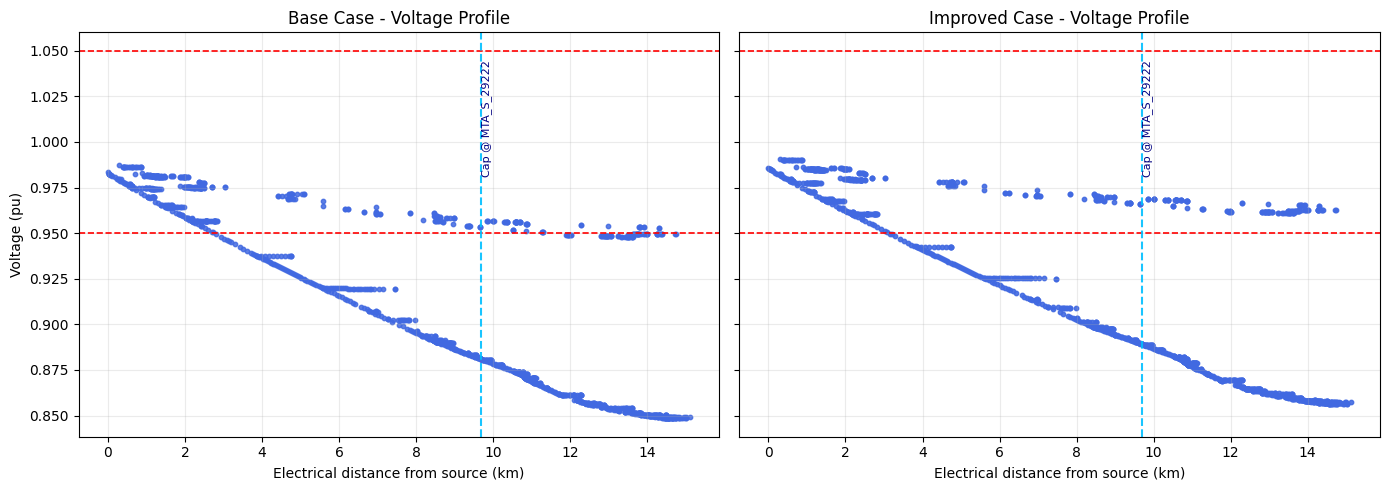

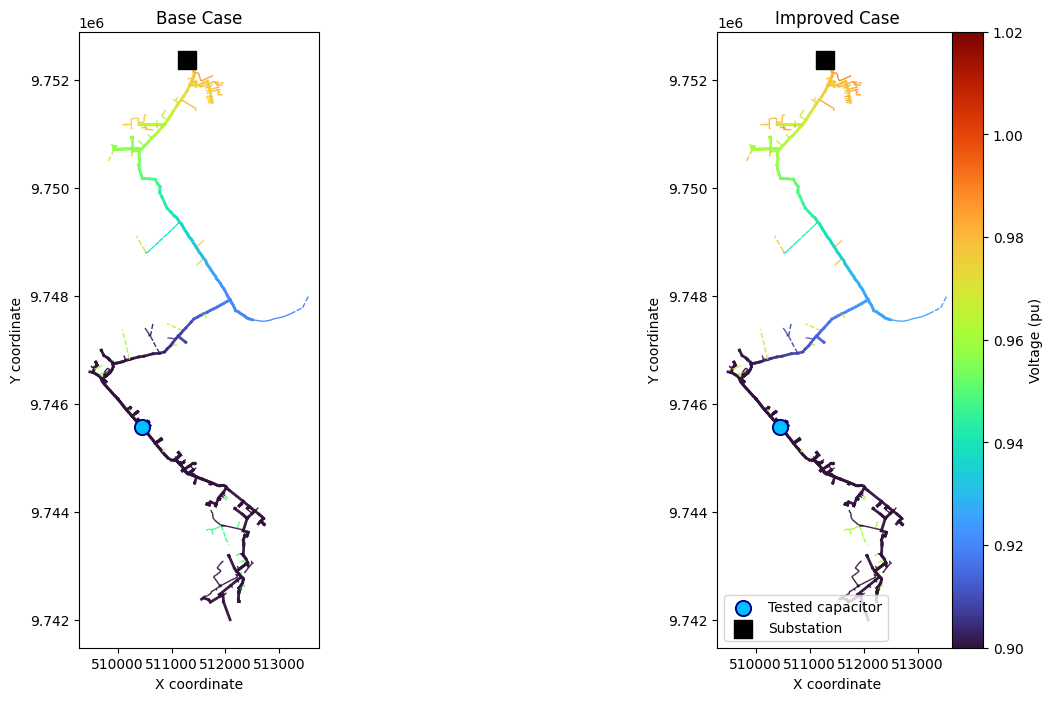

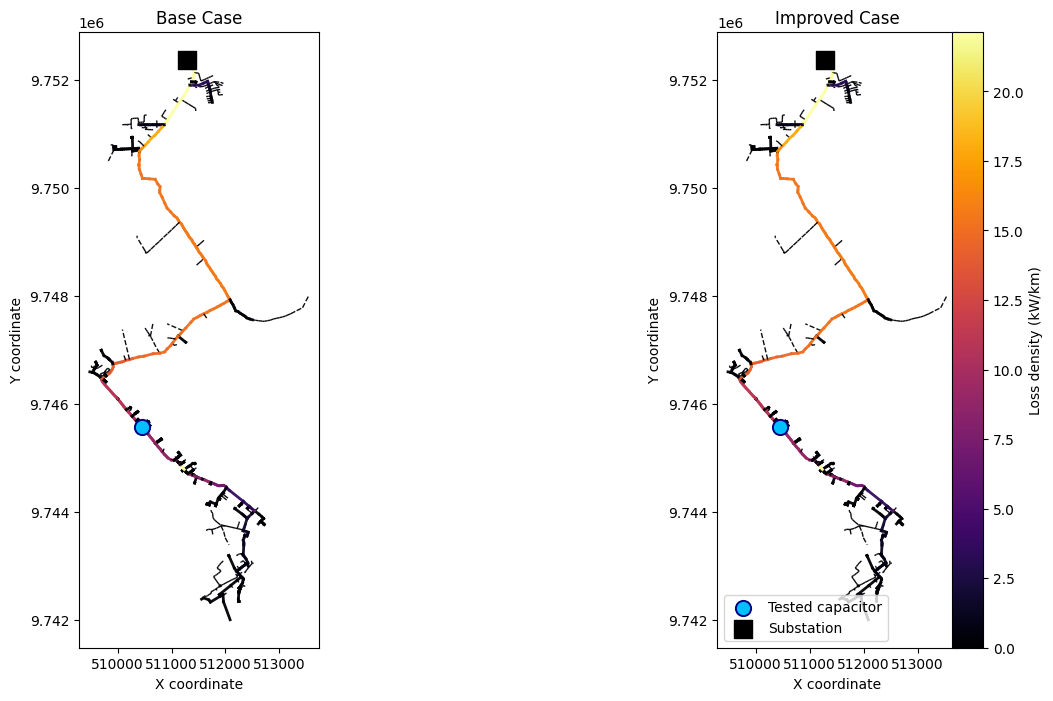

In [51]:
# CELL 8: Run the three before-after plots--------------------------------------
# Build one-row plotting table for the actually tested capacitor
tested_cap_plot_df = build_tested_capacitor_plot_table(cap_result_1, topology)

# ------------------------------------------------------------
# 1. Voltage profile: base on left, improved on right
# ------------------------------------------------------------
plot_voltage_profile_side_by_side(
    base_df_bus_case=BASE_CASE_RESULTS["df_bus_case"],
    new_df_bus_case=cap_result_1["df_bus_case"],
    tested_cap_plot_df=tested_cap_plot_df,
    title_left="Base Case - Voltage Profile",
    title_right="Improved Case - Voltage Profile",
    base_color="royalblue",
    new_color="royalblue",
    figsize=(14, 5)
)

# ------------------------------------------------------------
# 2. Voltage map: base on left, improved on right
# ------------------------------------------------------------
plot_voltage_map_side_by_side(
    topology=topology,
    base_segments_v_df=BASE_CASE_RESULTS["segments_v_df"],
    new_segments_v_df=cap_result_1["segments_v_df"],
    tested_cap_plot_df=tested_cap_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="turbo",
    vmin=0.90,
    vmax=1.02,
    figsize=(16, 8)
)

# ------------------------------------------------------------
# 3. Loss-density map: base on left, improved on right
# ------------------------------------------------------------
plot_loss_density_map_side_by_side(
    topology=topology,
    base_segments_loss_df=BASE_CASE_RESULTS["segments_loss_df"],
    new_segments_loss_df=cap_result_1["segments_loss_df"],
    tested_cap_plot_df=tested_cap_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="inferno",
    vmax_quantile=0.98,
    figsize=(16, 8)
)

REGULATOR SECTION

In [52]:
# CELL 1: USER SETTINGS --------------------------------------------------------
# ============================================================
# SINGLE REGULATOR SCENARIO - USER SETTINGS
# ============================================================

# Choose which ranked regulator candidate to test
# 0 = best candidate, 1 = second best, etc.
REG_CANDIDATE_INDEX = 0

# ------------------------------------------------------------
# Regulator sizing
# ------------------------------------------------------------
# Total 3-phase bank rating = downstream_kw * REG_KVA_MULTIPLIER
REG_KVA_MULTIPLIER = 1.25

# ------------------------------------------------------------
# RegControl settings (VERSION 1: R = X = 0)
# ------------------------------------------------------------
REG_VREG = 122.0
REG_BAND = 2.0
REG_CT_PRIM = 600.0

# Transformer/regulator parameters
REG_XHL = 0.01
REG_LOADLOSS_PCT = 0.10
REG_MINTAP = 0.90
REG_MAXTAP = 1.10
REG_NUMTAPS = 32

# Scenario base name
REG_SCENARIO_NAME = "REG_TEST"

print("Single regulator scenario settings loaded.")

# CELL 2: HELPER FUNCTIONS -----------------------------------------------------
import math
import numpy as np
import pandas as pd

def find_branch_row_between_buses(topology: dict, parent_bus: str, child_bus: str) -> pd.Series:
    """
    Find the branch row in topology['branch_table'] connecting parent_bus and child_bus.

    Parameters
    ----------
    topology : dict
    parent_bus : str
    child_bus : str

    Returns
    -------
    pd.Series
        Matching row from branch_table

    Raises
    ------
    ValueError
        If no matching branch is found.
    """
    df_branch = topology["branch_table"].copy()

    parent_bus = str(parent_bus).upper()
    child_bus = str(child_bus).upper()

    mask = (
        ((df_branch["bus1"].astype(str).str.upper() == parent_bus) &
         (df_branch["bus2"].astype(str).str.upper() == child_bus))
        |
        ((df_branch["bus1"].astype(str).str.upper() == child_bus) &
         (df_branch["bus2"].astype(str).str.upper() == parent_bus))
    )

    matches = df_branch.loc[mask].copy()

    if matches.empty:
        raise ValueError(f"No branch found between {parent_bus} and {child_bus}")

    # If multiple matches somehow exist, keep the first for version 1
    return matches.iloc[0].copy()


def get_bus_ln_base_kv(dss, bus_name: str) -> float:
    """
    Get line-to-neutral base kV of a bus from OpenDSS.
    """
    dss.Circuit.SetActiveBus(bus_name)
    kv_ln = dss.Bus.kVBase()

    if kv_ln is None or kv_ln <= 0:
        raise ValueError(f"Invalid kVBase at bus {bus_name}")

    return float(kv_ln)


def build_regulator_bus_name(parent_bus: str, child_bus: str, scenario_name: str = "REG_TEST") -> str:
    """
    Build a unique regulator secondary bus name.

    Example:
        REG_TEST_BUS_MTA_S_1000_MTA_S_1001
    """
    parent_bus = str(parent_bus).upper()
    child_bus = str(child_bus).upper()
    return f"{scenario_name}_BUS_{parent_bus}_{child_bus}"


def build_full_dss_line_name(branch_row: pd.Series) -> str:
    """
    Rebuild the OpenDSS line element name from branch_table row.

    Your parser stores 'element_name' like '7160_MTA',
    while the DSS object name is typically 'N_7160_MTA'.
    """
    line_short = str(branch_row["element_name"]).upper()
    return f"N_{line_short}"


def compute_total_regulator_bank_kva(candidate_row: pd.Series,
                                     kva_multiplier: float = 1.25) -> float:
    """
    Compute total 3-phase regulator bank kVA from downstream_kw.

    Parameters
    ----------
    candidate_row : pd.Series
        Row from reg_candidates
    kva_multiplier : float

    Returns
    -------
    float
        Total 3-phase bank kVA
    """
    downstream_kw = float(candidate_row["downstream_kw"])
    kva_total = downstream_kw * kva_multiplier
    kva_total = math.ceil(kva_total)

    return max(kva_total, 1.0)


def split_total_bank_kva_equally(kva_total_3ph: float) -> tuple[float, float, float]:
    """
    Split total 3-phase bank kVA equally among 3 single-phase units.
    """
    kva_phase = kva_total_3ph / 3.0
    return kva_phase, kva_phase, kva_phase


def assert_three_phase_candidate(branch_row: pd.Series):
    """
    Validate that the candidate branch is 3-phase.
    """
    phases = branch_row.get("phases_declared", np.nan)

    if pd.isna(phases) or int(phases) != 3:
        raise ValueError("Version 1 regulator engine only supports 3-phase candidates.")


# CELL 3: INSERT REGULATOR AND MODIFY THE LINE----------------------------------
def insert_three_phase_regulator_bank_v1(dss,
                                         topology: dict,
                                         branch_row: pd.Series,
                                         parent_bus: str,
                                         child_bus: str,
                                         kva_total_3ph: float,
                                         scenario_name: str = "REG_TEST",
                                         vreg: float = 122.0,
                                         band: float = 2.0,
                                         ctprim: float = 600.0,
                                         xhl: float = 0.01,
                                         loadloss_pct: float = 0.10,
                                         mintap: float = 0.90,
                                         maxtap: float = 1.10,
                                         numtaps: int = 32):
    """
    Insert a 3-phase regulator bank (three single-phase units) between parent_bus and child_bus.

    Logic
    -----
    1) Find original line
    2) Create new regulator secondary bus
    3) Edit original line so its upstream side is moved to the new regulator bus
    4) Add 3 single-phase regulator transformers from parent_bus to new regulator bus
    5) Add RegControl objects with R = X = 0

    Returns
    -------
    dict
        Information about inserted regulator bank
    """
    parent_bus = str(parent_bus).upper()
    child_bus = str(child_bus).upper()

    assert_three_phase_candidate(branch_row)

    # --------------------------------------------------------
    # 1. Build names
    # --------------------------------------------------------
    reg_bus = build_regulator_bus_name(parent_bus, child_bus, scenario_name=scenario_name)

    dss_line_name = build_full_dss_line_name(branch_row)

    reg_names = {
        "A": f"{scenario_name}_A",
        "B": f"{scenario_name}_B",
        "C": f"{scenario_name}_C"
    }

    regctrl_names = {
        "A": f"{scenario_name}_CTRL_A",
        "B": f"{scenario_name}_CTRL_B",
        "C": f"{scenario_name}_CTRL_C"
    }

    # --------------------------------------------------------
    # 2. Determine which side of original line is upstream
    # --------------------------------------------------------
    bus1 = str(branch_row["bus1"]).upper()
    bus2 = str(branch_row["bus2"]).upper()
    bus1_raw = str(branch_row["bus1_raw"])
    bus2_raw = str(branch_row["bus2_raw"])

    if bus1 == parent_bus and bus2 == child_bus:
        edit_side = "bus1"
        child_side_raw = bus2_raw
    elif bus2 == parent_bus and bus1 == child_bus:
        edit_side = "bus2"
        child_side_raw = bus1_raw
    else:
        raise ValueError("Branch row does not match the requested parent/child buses.")

    # --------------------------------------------------------
    # 3. New bus strings
    # --------------------------------------------------------
    # Keep the downstream side untouched, move the upstream side to the regulator secondary bus
    reg_bus_3ph = f"{reg_bus}.1.2.3"

    # --------------------------------------------------------
    # 4. kV base and bank sizing
    # --------------------------------------------------------
    kv_ln = get_bus_ln_base_kv(dss, parent_bus)
    kva_a, kva_b, kva_c = split_total_bank_kva_equally(kva_total_3ph)

    # Practical PTRatio from LN base voltage
    ptratio = (kv_ln * 1000.0) / 120.0

    # --------------------------------------------------------
    # 5. Edit original line to start from regulator secondary bus
    # --------------------------------------------------------
    if edit_side == "bus1":
        cmd_edit_line = f"Edit Line.{dss_line_name} bus1={reg_bus_3ph}"
    else:
        cmd_edit_line = f"Edit Line.{dss_line_name} bus2={reg_bus_3ph}"

    dss.Text.Command(cmd_edit_line)

    # --------------------------------------------------------
    # 6. Add three single-phase regulators
    # --------------------------------------------------------
    phase_map = {
        "A": 1,
        "B": 2,
        "C": 3
    }
    kva_map = {
        "A": kva_a,
        "B": kva_b,
        "C": kva_c
    }

    reg_cmds = []
    ctrl_cmds = []

    for ph_name in ["A", "B", "C"]:
        ph = phase_map[ph_name]
        kva_ph = kva_map[ph_name]

        xf_name = reg_names[ph_name]
        ctrl_name = regctrl_names[ph_name]

        bus_parent_ph = f"{parent_bus}.{ph}"
        bus_reg_ph = f"{reg_bus}.{ph}"

        cmd_xf = (
            f"New Transformer.{xf_name} "
            f"phases=1 windings=2 "
            f"buses=[{bus_parent_ph} {bus_reg_ph}] "
            f"kvs=[{kv_ln:.6f} {kv_ln:.6f}] "
            f"kvas=[{kva_ph:.6f} {kva_ph:.6f}] "
            f"xhl={xhl:.6f} "
            f"%loadloss={loadloss_pct:.6f} "
            f"maxtap={maxtap:.6f} "
            f"mintap={mintap:.6f} "
            f"numtaps={int(numtaps)}"
        )

        cmd_ctrl = (
            f"New RegControl.{ctrl_name} "
            f"transformer={xf_name} "
            f"winding=2 "
            f"vreg={vreg:.6f} "
            f"band={band:.6f} "
            f"ptratio={ptratio:.6f} "
            f"ctprim={ctprim:.6f} "
            f"R=0 "
            f"X=0"
        )

        dss.Text.Command(cmd_xf)
        dss.Text.Command(cmd_ctrl)

        reg_cmds.append(cmd_xf)
        ctrl_cmds.append(cmd_ctrl)

    return {
        "parent_bus": parent_bus,
        "child_bus": child_bus,
        "reg_bus": reg_bus,
        "edited_line_name": dss_line_name,
        "edited_line_side": edit_side,
        "kva_total_3ph": kva_total_3ph,
        "kva_per_phase": [kva_a, kva_b, kva_c],
        "kv_ln": kv_ln,
        "ptratio": ptratio,
        "regulator_names": reg_names,
        "regcontrol_names": regctrl_names,
        "line_edit_command": cmd_edit_line,
        "xf_commands": reg_cmds,
        "ctrl_commands": ctrl_cmds
    }

# CELL 4: SINGLE REGULATOR SCENARIO ENGINE -------------------------------------
def run_single_regulator_candidate_scenario_v1(dss,
                                               feeder_path: str,
                                               topology: dict,
                                               reg_candidates: pd.DataFrame,
                                               segments_df: pd.DataFrame,
                                               candidate_index: int = 0,
                                               kva_multiplier: float = 1.25,
                                               scenario_name: str = "REG_TEST",
                                               vreg: float = 122.0,
                                               band: float = 2.0,
                                               ctprim: float = 600.0,
                                               xhl: float = 0.01,
                                               loadloss_pct: float = 0.10,
                                               mintap: float = 0.90,
                                               maxtap: float = 1.10,
                                               numtaps: int = 32,
                                               vmin_limit: float = 0.95,
                                               vmax_limit: float = 1.05):
    """
    Run one regulator perturbation-validation scenario (VERSION 1, R = X = 0).

    Returns
    -------
    dict
        Scenario results package
    """
    # --------------------------------------------------------
    # 1. Candidate row
    # --------------------------------------------------------
    if candidate_index < 0 or candidate_index >= len(reg_candidates):
        raise IndexError("candidate_index is outside the available reg_candidates range.")

    cand = reg_candidates.iloc[candidate_index].copy()

    parent_bus = str(cand["parent_bus"]).upper()
    child_bus = str(cand["bus"]).upper()

    branch_row = find_branch_row_between_buses(topology, parent_bus, child_bus)
    assert_three_phase_candidate(branch_row)

    kva_total_3ph = compute_total_regulator_bank_kva(
        candidate_row=cand,
        kva_multiplier=kva_multiplier
    )

    # --------------------------------------------------------
    # 2. Reset network cleanly
    # --------------------------------------------------------
    master_file = os.path.join(feeder_path, "Master.dss")
    dss.Text.Command(f'compile "{master_file}"')
    dss.Solution.Solve()

    if not dss.Solution.Converged():
        raise RuntimeError("Base feeder did not converge after recompiling Master.dss.")

    # --------------------------------------------------------
    # 3. Insert regulator bank
    # --------------------------------------------------------
    reg_info = insert_three_phase_regulator_bank_v1(
        dss=dss,
        topology=topology,
        branch_row=branch_row,
        parent_bus=parent_bus,
        child_bus=child_bus,
        kva_total_3ph=kva_total_3ph,
        scenario_name=scenario_name,
        vreg=vreg,
        band=band,
        ctprim=ctprim,
        xhl=xhl,
        loadloss_pct=loadloss_pct,
        mintap=mintap,
        maxtap=maxtap,
        numtaps=numtaps
    )

    # --------------------------------------------------------
    # 4. Solve scenario
    # --------------------------------------------------------
    dss.Solution.Solve()
    converged = bool(dss.Solution.Converged())

    if not converged:
        print("Warning: regulator scenario did not converge.")
        return {
            "scenario_type": "REGULATOR",
            "candidate_index": candidate_index,
            "candidate_row": cand,
            "reg_info": reg_info,
            "converged": False
        }

    # --------------------------------------------------------
    # 5. Extract scenario outputs
    # --------------------------------------------------------
    df_v_new = extract_bus_voltages_from_dss(dss, topology["bus_table"])
    df_bus_case_new = topology["bus_table"].merge(df_v_new, on="bus", how="left")

    new_voltage_metrics = summarize_voltage_metrics(
        df_bus_case_new,
        vmin_limit=vmin_limit,
        vmax_limit=vmax_limit
    )

    new_loss_metrics = get_total_losses_from_dss(dss)

    # Voltage-colored segments
    segments_v_new = build_voltage_segments_table(segments_df, df_bus_case_new)

    # Line-loss / loss-density segments
    df_line_losses_new = extract_line_losses_from_dss(dss)
    segments_loss_new = build_loss_density_segments_table(segments_df, df_line_losses_new)

    # --------------------------------------------------------
    # 6. Compare with base case
    # --------------------------------------------------------
    base_v = BASE_CASE_RESULTS["voltage_metrics"]
    base_l = BASE_CASE_RESULTS["loss_metrics"]

    comparison = {
        "delta_vmin": new_voltage_metrics["vmin"] - base_v["vmin"],
        "delta_vmax": new_voltage_metrics["vmax"] - base_v["vmax"] if pd.notna(new_voltage_metrics["vmax"]) and pd.notna(base_v["vmax"]) else np.nan,
        "delta_n_under": new_voltage_metrics["n_under"] - base_v["n_under"],
        "delta_n_over": new_voltage_metrics["n_over"] - base_v["n_over"] if pd.notna(new_voltage_metrics["n_over"]) and pd.notna(base_v["n_over"]) else np.nan,
        "delta_p_loss_kw": new_loss_metrics["p_loss_kw"] - base_l["p_loss_kw"],
        "pct_p_loss_change": (
            100.0 * (new_loss_metrics["p_loss_kw"] - base_l["p_loss_kw"]) / base_l["p_loss_kw"]
            if base_l["p_loss_kw"] != 0 else np.nan
        )
    }

    result = {
        "scenario_type": "REGULATOR",
        "candidate_index": candidate_index,
        "candidate_row": cand,
        "branch_row": branch_row,
        "reg_info": reg_info,
        "converged": converged,
        "df_bus_case": df_bus_case_new,
        "segments_v_df": segments_v_new,
        "line_losses_df": df_line_losses_new,
        "segments_loss_df": segments_loss_new,
        "voltage_metrics": new_voltage_metrics,
        "loss_metrics": new_loss_metrics,
        "comparison": comparison
    }

    return result

# CELL 5: RUN ONE REGULATOR SCENARIO AND SUMMARIZE -----------------------------
reg_result_1 = run_single_regulator_candidate_scenario_v1(
    dss=dss,
    feeder_path=feeder_path,
    topology=topology,
    reg_candidates=reg_candidates,
    segments_df=segments_df,
    candidate_index=REG_CANDIDATE_INDEX,
    kva_multiplier=REG_KVA_MULTIPLIER,
    scenario_name=REG_SCENARIO_NAME,
    vreg=REG_VREG,
    band=REG_BAND,
    ctprim=REG_CT_PRIM,
    xhl=REG_XHL,
    loadloss_pct=REG_LOADLOSS_PCT,
    mintap=REG_MINTAP,
    maxtap=REG_MAXTAP,
    numtaps=REG_NUMTAPS,
    vmin_limit=0.95,
    vmax_limit=1.05
)

print("Scenario converged:", reg_result_1["converged"])
print("\nRegulator info:")
print(reg_result_1["reg_info"])
print("\nNew voltage metrics:")
print(reg_result_1["voltage_metrics"])
print("\nNew loss metrics:")
print(reg_result_1["loss_metrics"])
print("\nComparison vs base:")
print(reg_result_1["comparison"])

# COMPACT SUMMARY TABLE
def build_single_regulator_scenario_summary_table(reg_result: dict) -> pd.DataFrame:
    """
    Build a compact one-row summary table for the tested regulator scenario.
    """
    cand = reg_result["candidate_row"]
    reg_info = reg_result["reg_info"]
    vm = reg_result["voltage_metrics"]
    lm = reg_result["loss_metrics"]
    cmp = reg_result["comparison"]

    row = {
        "scenario_type": reg_result["scenario_type"],
        "candidate_index": reg_result["candidate_index"],
        "parent_bus": reg_info["parent_bus"],
        "child_bus": reg_info["child_bus"],
        "reg_bus": reg_info["reg_bus"],
        "downstream_kw": cand["downstream_kw"],
        "kva_total_3ph": reg_info["kva_total_3ph"],
        "kva_per_phase": reg_info["kva_per_phase"][0],
        "vmin_new": vm["vmin"],
        "vmax_new": vm["vmax"],
        "n_under_new": vm["n_under"],
        "n_over_new": vm["n_over"],
        "p_loss_kw_new": lm["p_loss_kw"],
        "delta_vmin": cmp["delta_vmin"],
        "delta_n_under": cmp["delta_n_under"],
        "delta_p_loss_kw": cmp["delta_p_loss_kw"],
        "pct_p_loss_change": cmp["pct_p_loss_change"],
        "converged": reg_result["converged"]
    }

    return pd.DataFrame([row])


reg_summary_1 = build_single_regulator_scenario_summary_table(reg_result_1)
reg_summary_1

Single regulator scenario settings loaded.
Scenario converged: True

Regulator info:
{'parent_bus': 'MTA_S_7360', 'child_bus': 'MTA_S_8517', 'reg_bus': 'REG_TEST_BUS_MTA_S_7360_MTA_S_8517', 'edited_line_name': 'N_7360_MTA', 'edited_line_side': 'bus1', 'kva_total_3ph': 1651, 'kva_per_phase': [550.3333333333334, 550.3333333333334, 550.3333333333334], 'kv_ln': 7.967433714816837, 'ptratio': 66.39528095680697, 'regulator_names': {'A': 'REG_TEST_A', 'B': 'REG_TEST_B', 'C': 'REG_TEST_C'}, 'regcontrol_names': {'A': 'REG_TEST_CTRL_A', 'B': 'REG_TEST_CTRL_B', 'C': 'REG_TEST_CTRL_C'}, 'line_edit_command': 'Edit Line.N_7360_MTA bus1=REG_TEST_BUS_MTA_S_7360_MTA_S_8517.1.2.3', 'xf_commands': ['New Transformer.REG_TEST_A phases=1 windings=2 buses=[MTA_S_7360.1 REG_TEST_BUS_MTA_S_7360_MTA_S_8517.1] kvs=[7.967434 7.967434] kvas=[550.333333 550.333333] xhl=0.010000 %loadloss=0.100000 maxtap=1.100000 mintap=0.900000 numtaps=32', 'New Transformer.REG_TEST_B phases=1 windings=2 buses=[MTA_S_7360.2 REG_TEST

,scenario_type,candidate_index,parent_bus,child_bus,reg_bus,downstream_kw,kva_total_3ph,kva_per_phase,vmin_new,vmax_new,n_under_new,n_over_new,p_loss_kw_new,delta_vmin,delta_n_under,delta_p_loss_kw,pct_p_loss_change,converged
0,REGULATOR,0,MTA_S_7360,MTA_S_8517,REG_TEST_BUS_MTA_S_7360_MTA_S_8517,1320.6673,1651,550.333333,0.874999,1.013005,789,0,283.763919,0.026524,-141,23.472035,9.017583,True


PLOTTING NETWORK WITH REGULATOR

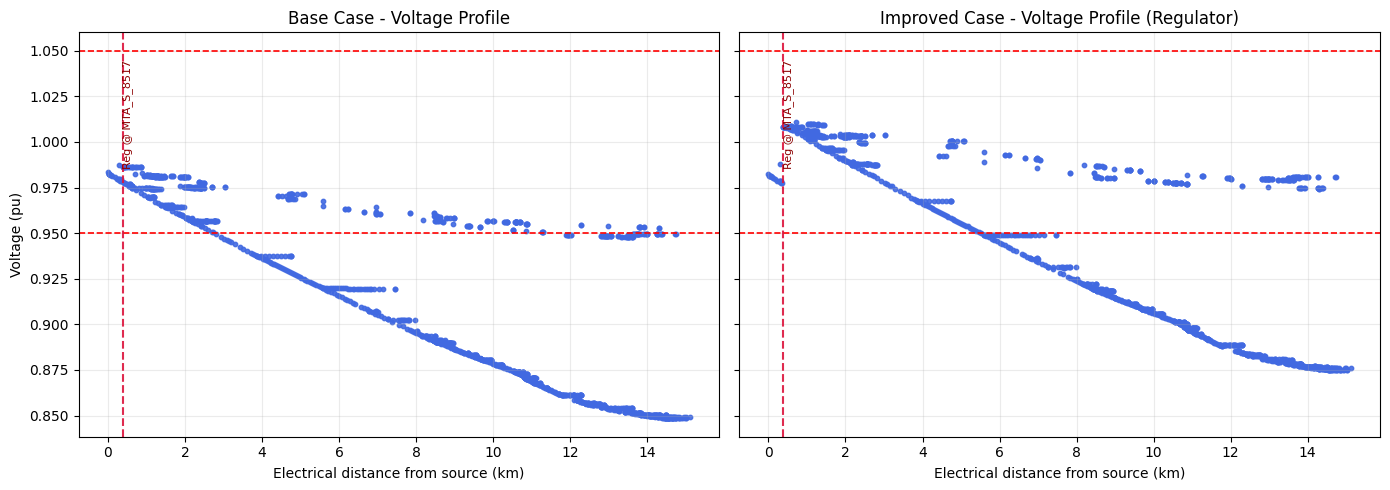

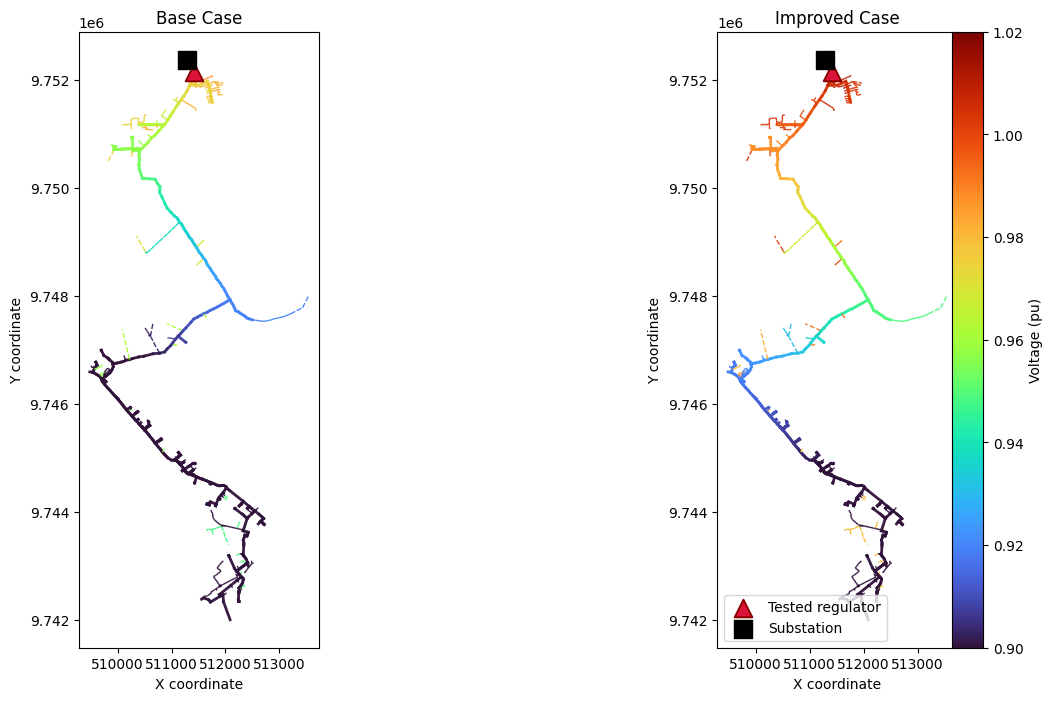

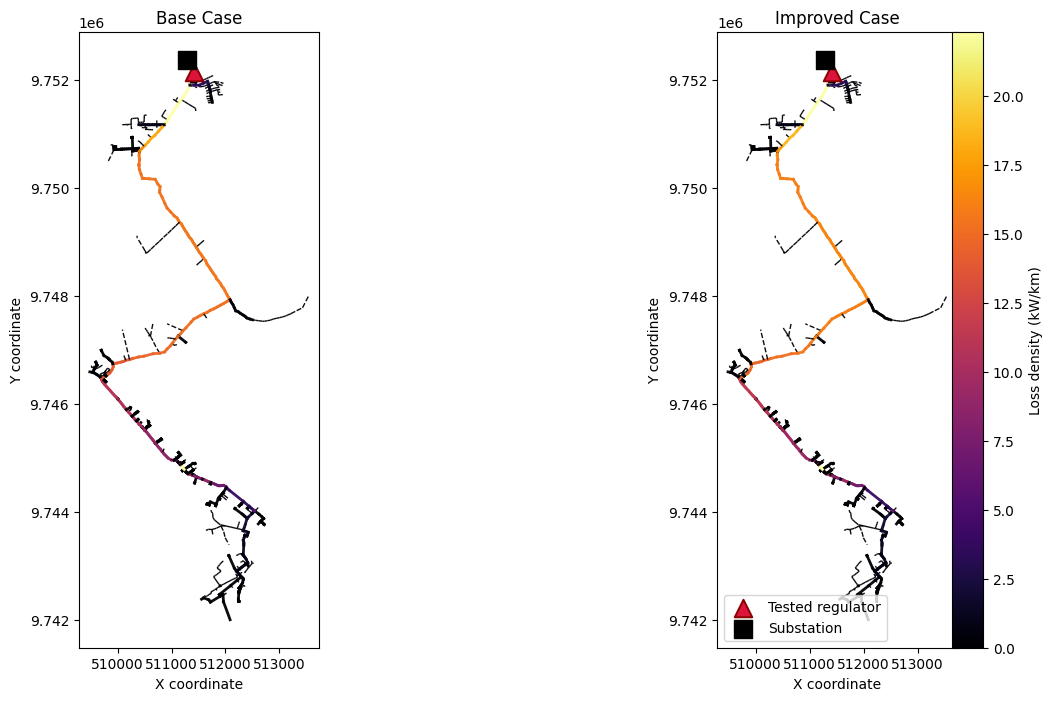

In [53]:
# PLOT CELL 1: BUILD PLOTTING POINT FOR THE TESTED REGULATOR -------------------
def build_tested_regulator_plot_table(reg_result: dict,
                                      topology: dict) -> pd.DataFrame:
    """
    Build a one-row plotting table for the actually tested regulator location.

    The regulator is plotted at the midpoint of the section between
    parent_bus and child_bus.

    Parameters
    ----------
    reg_result : dict
        Output of run_single_regulator_candidate_scenario_v1(...)
    topology : dict

    Returns
    -------
    pd.DataFrame
        Columns:
            parent_bus, child_bus, xm, ym, kva_total_3ph, reg_bus
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    parent_bus = str(reg_result["reg_info"]["parent_bus"]).upper()
    child_bus = str(reg_result["reg_info"]["child_bus"]).upper()
    reg_bus = str(reg_result["reg_info"]["reg_bus"]).upper()
    kva_total_3ph = float(reg_result["reg_info"]["kva_total_3ph"])

    c_parent = coords_df[coords_df["bus"] == parent_bus][["bus", "x", "y"]].copy()
    c_child = coords_df[coords_df["bus"] == child_bus][["bus", "x", "y"]].copy()

    if c_parent.empty or c_child.empty:
        raise ValueError("Could not locate parent_bus or child_bus coordinates for regulator plotting.")

    x_parent = float(c_parent["x"].iloc[0])
    y_parent = float(c_parent["y"].iloc[0])
    x_child = float(c_child["x"].iloc[0])
    y_child = float(c_child["y"].iloc[0])

    out = pd.DataFrame([{
        "parent_bus": parent_bus,
        "child_bus": child_bus,
        "reg_bus": reg_bus,
        "x_parent": x_parent,
        "y_parent": y_parent,
        "x_child": x_child,
        "y_child": y_child,
        "xm": (x_parent + x_child) / 2.0,
        "ym": (y_parent + y_child) / 2.0,
        "kva_total_3ph": kva_total_3ph
    }])

    return out


tested_reg_plot_df = build_tested_regulator_plot_table(reg_result_1, topology)
tested_reg_plot_df


# PLOT CELL 2: SIDE-BY-SIDE PLOTTING FUNCTIONS AND CALLS------------------------
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# 1. Voltage profile: base vs regulator scenario
# ============================================================

def plot_voltage_profile_side_by_side_regulator(base_df_bus_case: pd.DataFrame,
                                                new_df_bus_case: pd.DataFrame,
                                                reg_result: dict,
                                                title_left: str = "Base Case - Voltage Profile",
                                                title_right: str = "Improved Case - Voltage Profile (Regulator)",
                                                color: str = "royalblue",
                                                figsize=(14, 5)):
    """
    Side-by-side voltage profile:
    - left: base case
    - right: improved regulator case

    The regulator location is marked using the electrical distance of child_bus.
    """
    b = base_df_bus_case.sort_values("distance_km").copy()
    n = new_df_bus_case.sort_values("distance_km").copy()

    reg_child_bus = str(reg_result["reg_info"]["child_bus"]).upper()

    # Locate regulator child bus electrical distance from base table
    reg_dist = None
    tmp = base_df_bus_case.copy()
    tmp["bus"] = tmp["bus"].astype(str).str.upper()

    row = tmp[tmp["bus"] == reg_child_bus]
    if not row.empty:
        reg_dist = float(row["distance_km"].iloc[0])

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # ---------------- LEFT: BASE ----------------
    ax = axes[0]
    ax.scatter(
        b["distance_km"], b["v_pu_min"],
        s=10, color=color, alpha=0.90
    )
    ax.axhline(0.95, color="red", linestyle="--", linewidth=1.2)
    ax.axhline(1.05, color="red", linestyle="--", linewidth=1.2)

    if reg_dist is not None:
        ax.axvline(reg_dist, color="crimson", linestyle="--", linewidth=1.5, alpha=0.90)
        ax.text(
            reg_dist, 1.045,
            f"Reg @ {reg_child_bus}",
            color="darkred", fontsize=8,
            ha="left", va="top", rotation=90
        )

    ax.set_title(title_left)
    ax.set_xlabel("Electrical distance from source (km)")
    ax.set_ylabel("Voltage (pu)")
    ax.grid(True, alpha=0.25)

    # ---------------- RIGHT: IMPROVED ----------------
    ax = axes[1]
    ax.scatter(
        n["distance_km"], n["v_pu_min"],
        s=10, color=color, alpha=0.90
    )
    ax.axhline(0.95, color="red", linestyle="--", linewidth=1.2)
    ax.axhline(1.05, color="red", linestyle="--", linewidth=1.2)

    if reg_dist is not None:
        ax.axvline(reg_dist, color="crimson", linestyle="--", linewidth=1.5, alpha=0.90)
        ax.text(
            reg_dist, 1.045,
            f"Reg @ {reg_child_bus}",
            color="darkred", fontsize=8,
            ha="left", va="top", rotation=90
        )

    ax.set_title(title_right)
    ax.set_xlabel("Electrical distance from source (km)")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


# ============================================================
# 2. Voltage map: base vs regulator scenario
# ============================================================

def plot_voltage_map_side_by_side_regulator(topology: dict,
                                            base_segments_v_df: pd.DataFrame,
                                            new_segments_v_df: pd.DataFrame,
                                            tested_reg_plot_df: pd.DataFrame,
                                            root_bus: str | None = None,
                                            cmap_name: str = "turbo",
                                            vmin: float = 0.90,
                                            vmax: float = 1.02,
                                            figsize=(16, 8)):
    """
    Side-by-side voltage map:
    - left: base case
    - right: improved regulator case
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    if root_bus is None:
        root_bus = topology["root_bus"]
    root_bus = str(root_bus).upper()

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.colormaps[cmap_name]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    panel_data = [
        (axes[0], base_segments_v_df, "Base Case"),
        (axes[1], new_segments_v_df, "Improved Case")
    ]

    for ax, seg_df, title in panel_data:
        for _, row in seg_df.iterrows():
            x = [row["x_from"], row["x_to"]]
            y = [row["y_from"], row["y_to"]]

            v = row["v_plot"]
            color = "lightgray" if pd.isna(v) else cmap(norm(v))

            if row.get("phases", np.nan) == 3:
                lw = 2.0
                style = "-"
            else:
                lw = 1.0
                style = "--"

            ax.plot(x, y, color=color, linestyle=style, linewidth=lw, alpha=0.95, zorder=1)

        # Tested regulator location only
        ax.scatter(
            tested_reg_plot_df["xm"], tested_reg_plot_df["ym"],
            s=160, marker="^",
            facecolor="crimson", edgecolor="darkred",
            linewidth=1.4, zorder=5, label="Tested regulator"
        )

        # Substation
        sub = coords_df[coords_df["bus"] == root_bus]
        if not sub.empty:
            ax.scatter(
                sub["x"], sub["y"],
                s=180, marker="s",
                facecolor="black", edgecolor="black",
                zorder=6, label="Substation"
            )

        ax.set_title(title)
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.set_aspect("equal", adjustable="box")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.030, pad=0.02)
    cbar.set_label("Voltage (pu)")

    handles, labels = axes[1].get_legend_handles_labels()
    if handles:
        axes[1].legend(loc="best")

    plt.subplots_adjust(wspace=0.12, right=0.88)
    plt.show()


# ============================================================
# 3. Loss-density map: base vs regulator scenario
# ============================================================

def plot_loss_density_map_side_by_side_regulator(topology: dict,
                                                 base_segments_loss_df: pd.DataFrame,
                                                 new_segments_loss_df: pd.DataFrame,
                                                 tested_reg_plot_df: pd.DataFrame,
                                                 root_bus: str | None = None,
                                                 cmap_name: str = "inferno",
                                                 vmax_quantile: float = 0.98,
                                                 figsize=(16, 8)):
    """
    Side-by-side loss-density map:
    - left: base case
    - right: improved regulator case
    """
    coords_df = topology["coords_table"].copy()
    coords_df["bus"] = coords_df["bus"].astype(str).str.upper()

    if root_bus is None:
        root_bus = topology["root_bus"]
    root_bus = str(root_bus).upper()

    valid_base = base_segments_loss_df["loss_density_kw_per_km"].dropna()
    valid_new = new_segments_loss_df["loss_density_kw_per_km"].dropna()
    valid_all = pd.concat([valid_base, valid_new], ignore_index=True)

    vmax = valid_all.quantile(vmax_quantile) if len(valid_all) > 0 else 1.0
    vmax = max(vmax, 1e-6)

    norm = Normalize(vmin=0.0, vmax=vmax)
    cmap = plt.colormaps[cmap_name]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    panel_data = [
        (axes[0], base_segments_loss_df, "Base Case"),
        (axes[1], new_segments_loss_df, "Improved Case")
    ]

    for ax, seg_df, title in panel_data:
        for _, row in seg_df.iterrows():
            x = [row["x_from"], row["x_to"]]
            y = [row["y_from"], row["y_to"]]

            ld = row["loss_density_kw_per_km"]
            color = "lightgray" if pd.isna(ld) else cmap(norm(min(ld, vmax)))

            if row.get("phases", np.nan) == 3:
                lw = 2.0
                style = "-"
            else:
                lw = 1.0
                style = "--"

            ax.plot(x, y, color=color, linestyle=style, linewidth=lw, alpha=0.95, zorder=1)

        # Tested regulator location only
        ax.scatter(
            tested_reg_plot_df["xm"], tested_reg_plot_df["ym"],
            s=160, marker="^",
            facecolor="crimson", edgecolor="darkred",
            linewidth=1.4, zorder=5, label="Tested regulator"
        )

        # Substation
        sub = coords_df[coords_df["bus"] == root_bus]
        if not sub.empty:
            ax.scatter(
                sub["x"], sub["y"],
                s=180, marker="s",
                facecolor="black", edgecolor="black",
                zorder=6, label="Substation"
            )

        ax.set_title(title)
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.set_aspect("equal", adjustable="box")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.030, pad=0.02)
    cbar.set_label("Loss density (kW/km)")

    handles, labels = axes[1].get_legend_handles_labels()
    if handles:
        axes[1].legend(loc="best")

    plt.subplots_adjust(wspace=0.12, right=0.88)
    plt.show()


# ============================================================
# 4. Run the three regulator comparison plots
# ============================================================

plot_voltage_profile_side_by_side_regulator(
    base_df_bus_case=BASE_CASE_RESULTS["df_bus_case"],
    new_df_bus_case=reg_result_1["df_bus_case"],
    reg_result=reg_result_1,
    title_left="Base Case - Voltage Profile",
    title_right="Improved Case - Voltage Profile (Regulator)",
    color="royalblue",
    figsize=(14, 5)
)

plot_voltage_map_side_by_side_regulator(
    topology=topology,
    base_segments_v_df=BASE_CASE_RESULTS["segments_v_df"],
    new_segments_v_df=reg_result_1["segments_v_df"],
    tested_reg_plot_df=tested_reg_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="turbo",
    vmin=0.90,
    vmax=1.02,
    figsize=(16, 8)
)

plot_loss_density_map_side_by_side_regulator(
    topology=topology,
    base_segments_loss_df=BASE_CASE_RESULTS["segments_loss_df"],
    new_segments_loss_df=reg_result_1["segments_loss_df"],
    tested_reg_plot_df=tested_reg_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="inferno",
    vmax_quantile=0.98,
    figsize=(16, 8)
)

FINAL COMPARISON

We move from visual validation to quantitative comparison, which is exactly what is needed for decision-making and later optimization.

We will build a single unified comparison table with:Base case, Capacitor scenario, Regulator scenario

Using the same metrics, consistently.

For the comparison, we will include:

* Voltage metrics: Vmin, Vmax, undervoltage buses (<0.95), overvoltage buses (>1.05)

* Loss metrics: total active losses (kW)

* Improvements vs base: ΔVmin, Δ(undervoltage buses), Δloss (kW), % loss change

HOW TO INTERPRET RESULTS

In terms of voltage quality, the best scenario is the one with the highest Vmin and also the lowest n_under

In terms of losses, the best scenario is the one with the lowest P_loss_kW and the negative ΔP_loss_kw.

EXPECTED ENGINEERING BEHAVIOR

We should typically observe:

The capacitor improves voltage moderately, reduces losses (reactive compensation), and effect spreads across feeder.

The regulator (R=X=0) strongly improves downstream voltage, may not reduce losses significantly, mainly shifts voltage profile, not reactive flow.

So:

If your issue is undervoltage → regulator is stronger

If your issue is losses → capacitor is stronger


In [54]:
# CASE VS CAPACITOR VS REGULATOR TABLE -----------------------------------------
def build_comparison_table(base_results: dict,
                           cap_result: dict,
                           reg_result: dict) -> pd.DataFrame:
    """
    Build a unified comparison table:
        Base vs Capacitor vs Regulator

    Parameters
    ----------
    base_results : dict (BASE_CASE_RESULTS)
    cap_result   : dict (cap_result_1)
    reg_result   : dict (reg_result_1)

    Returns
    -------
    pd.DataFrame
    """

    # -------------------------
    # Extract base metrics
    # -------------------------
    base_v = base_results["voltage_metrics"]
    base_l = base_results["loss_metrics"]

    # -------------------------
    # Extract capacitor metrics
    # -------------------------
    cap_v = cap_result["voltage_metrics"]
    cap_l = cap_result["loss_metrics"]

    # -------------------------
    # Extract regulator metrics
    # -------------------------
    reg_v = reg_result["voltage_metrics"]
    reg_l = reg_result["loss_metrics"]

    # -------------------------
    # Build rows
    # -------------------------
    rows = []

    # ---- Base ----
    rows.append({
        "scenario": "BASE",
        "Vmin": base_v["vmin"],
        "Vmax": base_v["vmax"],
        "n_under": base_v["n_under"],
        "n_over": base_v["n_over"],
        "P_loss_kw": base_l["p_loss_kw"],
        "ΔVmin": 0.0,
        "Δn_under": 0,
        "ΔP_loss_kw": 0.0,
        "%ΔP_loss": 0.0
    })

    # ---- Capacitor ----
    rows.append({
        "scenario": "CAPACITOR",
        "Vmin": cap_v["vmin"],
        "Vmax": cap_v["vmax"],
        "n_under": cap_v["n_under"],
        "n_over": cap_v["n_over"],
        "P_loss_kw": cap_l["p_loss_kw"],
        "ΔVmin": cap_v["vmin"] - base_v["vmin"],
        "Δn_under": cap_v["n_under"] - base_v["n_under"],
        "ΔP_loss_kw": cap_l["p_loss_kw"] - base_l["p_loss_kw"],
        "%ΔP_loss": (
            100.0 * (cap_l["p_loss_kw"] - base_l["p_loss_kw"]) / base_l["p_loss_kw"]
            if base_l["p_loss_kw"] != 0 else np.nan
        )
    })

    # ---- Regulator ----
    rows.append({
        "scenario": "REGULATOR",
        "Vmin": reg_v["vmin"],
        "Vmax": reg_v["vmax"],
        "n_under": reg_v["n_under"],
        "n_over": reg_v["n_over"],
        "P_loss_kw": reg_l["p_loss_kw"],
        "ΔVmin": reg_v["vmin"] - base_v["vmin"],
        "Δn_under": reg_v["n_under"] - base_v["n_under"],
        "ΔP_loss_kw": reg_l["p_loss_kw"] - base_l["p_loss_kw"],
        "%ΔP_loss": (
            100.0 * (reg_l["p_loss_kw"] - base_l["p_loss_kw"]) / base_l["p_loss_kw"]
            if base_l["p_loss_kw"] != 0 else np.nan
        )
    })

    df = pd.DataFrame(rows)

    return df


comparison_df = build_comparison_table(
    base_results=BASE_CASE_RESULTS,
    cap_result=cap_result_1,
    reg_result=reg_result_1
)

comparison_df

# IMPROVE READABILITY ----------------------------------------------------------
def format_comparison_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Format table for readability.
    """
    out = df.copy()

    # Round values
    cols_round_3 = ["Vmin", "Vmax"]
    cols_round_2 = ["P_loss_kw", "ΔP_loss_kw", "%ΔP_loss"]

    for c in cols_round_3:
        if c in out.columns:
            out[c] = out[c].round(4)

    for c in cols_round_2:
        if c in out.columns:
            out[c] = out[c].round(2)

    return out


comparison_df_fmt = format_comparison_table(comparison_df)
comparison_df_fmt

# HIGHLIGHT BEST PERFORMANCE ---------------------------------------------------
def highlight_best(df: pd.DataFrame):
    """
    Highlight best values:
    - highest Vmin
    - lowest losses
    - lowest undervoltage count
    """
    return df.style \
        .highlight_max(subset=["Vmin"], color="lightgreen") \
        .highlight_min(subset=["n_under"], color="lightgreen") \
        .highlight_min(subset=["P_loss_kw"], color="lightgreen")


highlight_best(comparison_df_fmt)

,scenario,Vmin,Vmax,n_under,n_over,P_loss_kw,ΔVmin,Δn_under,ΔP_loss_kw,%ΔP_loss
0,BASE,0.848500,0.990000,930,0,260.290000,0.000000,0,0.000000,0.000000
1,CAPACITOR,0.856400,0.992900,844,0,261.550000,0.007937,-86,1.260000,0.480000
2,REGULATOR,0.875000,1.013000,789,0,283.760000,0.026524,-141,23.470000,9.020000


LOOP ENGINE FOR TOP-N CANDIDATE COMPARISON AND RANKING

Now that we have experienced with single-candidate capacitor and single-candidate regulator scenarios, the next logical step is a top-N loop engine that:

* runs several capacitor candidates
* runs several regulator candidates
* stores all scenario metrics
* builds ranking tables
* lets comparison (which candidates are best for): voltage improvement, undervoltage reduction, loss reduction

Assumptions:

* capacitor uses q_down_kvar or manual kVAr logic already defined
* regulator uses the current R = X = 0 implementation
* every scenario starts from a clean recompile
* all results are compared against BASE_CASE_RESULTS

In [55]:
# CELL 1: USER SETTING ---------------------------------------------------------
# ============================================================
# TOP-N LOOP ENGINE - USER SETTINGS
# ============================================================

# How many capacitor candidates to test
TOP_N_CAP = 3

# How many regulator candidates to test
TOP_N_REG = 3

# ------------------------------------------------------------
# Capacitor loop settings
# ------------------------------------------------------------
# True  -> use q_down_kvar from each candidate
# False -> use MANUAL_CAP_KVAR_LOOP for all tested capacitor cases
USE_CANDIDATE_QDOWN_AS_KVAR_LOOP = True

# >>> USER TUNING PARAMETER <<<
MANUAL_CAP_KVAR_LOOP = 300.0

# Optional cap on automatic capacitor sizing
MAX_AUTO_CAP_KVAR_LOOP = None   # example: 1200.0

CAP_CONN_LOOP = "wye"
CAP_SCENARIO_PREFIX = "CAP_LOOP"

# ------------------------------------------------------------
# Regulator loop settings
# ------------------------------------------------------------
REG_KVA_MULTIPLIER_LOOP = 1.25
REG_SCENARIO_PREFIX = "REG_LOOP"

REG_VREG_LOOP = 122.0
REG_BAND_LOOP = 2.0
REG_CT_PRIM_LOOP = 600.0
REG_XHL_LOOP = 0.01
REG_LOADLOSS_PCT_LOOP = 0.10
REG_MINTAP_LOOP = 0.90
REG_MAXTAP_LOOP = 1.10
REG_NUMTAPS_LOOP = 32

print("Top-N loop settings loaded.")

# CELL 2: SUMMARY-ROW BUILDERS
def build_capacitor_loop_summary_row(cap_result: dict) -> dict:
    """
    Convert one capacitor scenario result into one flat summary row.
    """
    cand = cap_result["candidate_row"]
    cap_info = cap_result["cap_info"]

    row = {
        "scenario_family": "CAPACITOR",
        "candidate_index": cap_result["candidate_index"],
        "location_bus": str(cand["bus"]).upper(),
        "parent_bus": None,
        "q_down_kvar": float(cand["q_down_kvar"]),
        "downstream_kw": np.nan,
        "device_size": float(cap_info["kvar"]),
        "device_size_units": "kVAr",
        "converged": bool(cap_result["converged"]),
        "Vmin": float(cap_result["voltage_metrics"]["vmin"]),
        "Vmax": float(cap_result["voltage_metrics"]["vmax"]),
        "n_under": int(cap_result["voltage_metrics"]["n_under"]),
        "n_over": int(cap_result["voltage_metrics"]["n_over"]) if pd.notna(cap_result["voltage_metrics"]["n_over"]) else np.nan,
        "P_loss_kw": float(cap_result["loss_metrics"]["p_loss_kw"]),
        "Q_loss_kvar": float(cap_result["loss_metrics"]["q_loss_kvar"]),
        "delta_Vmin": float(cap_result["comparison"]["delta_vmin"]),
        "delta_n_under": float(cap_result["comparison"]["delta_n_under"]),
        "delta_P_loss_kw": float(cap_result["comparison"]["delta_p_loss_kw"]),
        "pct_delta_P_loss": float(cap_result["comparison"]["pct_p_loss_change"]),
    }
    return row


def build_regulator_loop_summary_row(reg_result: dict) -> dict:
    """
    Convert one regulator scenario result into one flat summary row.
    """
    cand = reg_result["candidate_row"]
    reg_info = reg_result["reg_info"]

    row = {
        "scenario_family": "REGULATOR",
        "candidate_index": reg_result["candidate_index"],
        "location_bus": str(reg_info["child_bus"]).upper(),
        "parent_bus": str(reg_info["parent_bus"]).upper(),
        "q_down_kvar": np.nan,
        "downstream_kw": float(cand["downstream_kw"]),
        "device_size": float(reg_info["kva_total_3ph"]),
        "device_size_units": "kVA_3ph",
        "converged": bool(reg_result["converged"]),
        "Vmin": float(reg_result["voltage_metrics"]["vmin"]),
        "Vmax": float(reg_result["voltage_metrics"]["vmax"]),
        "n_under": int(reg_result["voltage_metrics"]["n_under"]),
        "n_over": int(reg_result["voltage_metrics"]["n_over"]) if pd.notna(reg_result["voltage_metrics"]["n_over"]) else np.nan,
        "P_loss_kw": float(reg_result["loss_metrics"]["p_loss_kw"]),
        "Q_loss_kvar": float(reg_result["loss_metrics"]["q_loss_kvar"]),
        "delta_Vmin": float(reg_result["comparison"]["delta_vmin"]),
        "delta_n_under": float(reg_result["comparison"]["delta_n_under"]),
        "delta_P_loss_kw": float(reg_result["comparison"]["delta_p_loss_kw"]),
        "pct_delta_P_loss": float(reg_result["comparison"]["pct_p_loss_change"]),
    }
    return row

# CELL 3: CAPACITOR LOOP ENGINE --------------------------------------------
def run_top_n_capacitor_candidates(dss,
                                   feeder_path: str,
                                   topology: dict,
                                   cap_candidates: pd.DataFrame,
                                   segments_df: pd.DataFrame,
                                   top_n: int = 5,
                                   use_candidate_qdown: bool = True,
                                   manual_kvar: float = 300.0,
                                   max_auto_cap_kvar: float | None = None,
                                   conn: str = "wye",
                                   scenario_prefix: str = "CAP_LOOP",
                                   vmin_limit: float = 0.95,
                                   vmax_limit: float = 1.05):
    """
    Run the top-N capacitor candidates one by one.

    Returns
    -------
    results_list : list[dict]
        Full scenario result objects
    summary_df : pd.DataFrame
        One-row-per-scenario summary table
    """
    results_list = []
    summary_rows = []

    n_run = min(int(top_n), len(cap_candidates))

    print(f"Running top {n_run} capacitor candidates...")

    for i in range(n_run):
        print(f"  Capacitor candidate {i+1}/{n_run} (index={i})")

        try:
            scenario_name = f"{scenario_prefix}_{i}"

            res = run_single_capacitor_candidate_scenario(
                dss=dss,
                feeder_path=feeder_path,
                topology=topology,
                cap_candidates=cap_candidates,
                segments_df=segments_df,
                candidate_index=i,
                use_candidate_qdown=use_candidate_qdown,
                manual_kvar=manual_kvar,
                max_auto_cap_kvar=max_auto_cap_kvar,
                conn=conn,
                scenario_name=scenario_name,
                vmin_limit=vmin_limit,
                vmax_limit=vmax_limit
            )

            results_list.append(res)

            if res.get("converged", False):
                summary_rows.append(build_capacitor_loop_summary_row(res))
            else:
                cand = cap_candidates.iloc[i]
                summary_rows.append({
                    "scenario_family": "CAPACITOR",
                    "candidate_index": i,
                    "location_bus": str(cand["bus"]).upper(),
                    "parent_bus": None,
                    "q_down_kvar": float(cand["q_down_kvar"]),
                    "downstream_kw": np.nan,
                    "device_size": np.nan,
                    "device_size_units": "kVAr",
                    "converged": False,
                    "Vmin": np.nan,
                    "Vmax": np.nan,
                    "n_under": np.nan,
                    "n_over": np.nan,
                    "P_loss_kw": np.nan,
                    "Q_loss_kvar": np.nan,
                    "delta_Vmin": np.nan,
                    "delta_n_under": np.nan,
                    "delta_P_loss_kw": np.nan,
                    "pct_delta_P_loss": np.nan,
                })

        except Exception as e:
            print(f"    Error in capacitor candidate index {i}: {e}")
            cand = cap_candidates.iloc[i]
            summary_rows.append({
                "scenario_family": "CAPACITOR",
                "candidate_index": i,
                "location_bus": str(cand["bus"]).upper(),
                "parent_bus": None,
                "q_down_kvar": float(cand["q_down_kvar"]),
                "downstream_kw": np.nan,
                "device_size": np.nan,
                "device_size_units": "kVAr",
                "converged": False,
                "Vmin": np.nan,
                "Vmax": np.nan,
                "n_under": np.nan,
                "n_over": np.nan,
                "P_loss_kw": np.nan,
                "Q_loss_kvar": np.nan,
                "delta_Vmin": np.nan,
                "delta_n_under": np.nan,
                "delta_P_loss_kw": np.nan,
                "pct_delta_P_loss": np.nan,
            })

    summary_df = pd.DataFrame(summary_rows)
    return results_list, summary_df

# CELL 4: REGULATOR LOOP ENGINE --------------------------------------------
def run_top_n_regulator_candidates_v1(dss,
                                      feeder_path: str,
                                      topology: dict,
                                      reg_candidates: pd.DataFrame,
                                      segments_df: pd.DataFrame,
                                      top_n: int = 5,
                                      kva_multiplier: float = 1.25,
                                      scenario_prefix: str = "REG_LOOP",
                                      vreg: float = 122.0,
                                      band: float = 2.0,
                                      ctprim: float = 600.0,
                                      xhl: float = 0.01,
                                      loadloss_pct: float = 0.10,
                                      mintap: float = 0.90,
                                      maxtap: float = 1.10,
                                      numtaps: int = 32,
                                      vmin_limit: float = 0.95,
                                      vmax_limit: float = 1.05):
    """
    Run the top-N regulator candidates one by one.

    Returns
    -------
    results_list : list[dict]
        Full scenario result objects
    summary_df : pd.DataFrame
        One-row-per-scenario summary table
    """
    results_list = []
    summary_rows = []

    n_run = min(int(top_n), len(reg_candidates))

    print(f"Running top {n_run} regulator candidates...")

    for i in range(n_run):
        print(f"  Regulator candidate {i+1}/{n_run} (index={i})")

        try:
            scenario_name = f"{scenario_prefix}_{i}"

            res = run_single_regulator_candidate_scenario_v1(
                dss=dss,
                feeder_path=feeder_path,
                topology=topology,
                reg_candidates=reg_candidates,
                segments_df=segments_df,
                candidate_index=i,
                kva_multiplier=kva_multiplier,
                scenario_name=scenario_name,
                vreg=vreg,
                band=band,
                ctprim=ctprim,
                xhl=xhl,
                loadloss_pct=loadloss_pct,
                mintap=mintap,
                maxtap=maxtap,
                numtaps=numtaps,
                vmin_limit=vmin_limit,
                vmax_limit=vmax_limit
            )

            results_list.append(res)

            if res.get("converged", False):
                summary_rows.append(build_regulator_loop_summary_row(res))
            else:
                cand = reg_candidates.iloc[i]
                summary_rows.append({
                    "scenario_family": "REGULATOR",
                    "candidate_index": i,
                    "location_bus": str(cand["bus"]).upper(),
                    "parent_bus": str(cand["parent_bus"]).upper(),
                    "q_down_kvar": np.nan,
                    "downstream_kw": float(cand["downstream_kw"]),
                    "device_size": np.nan,
                    "device_size_units": "kVA_3ph",
                    "converged": False,
                    "Vmin": np.nan,
                    "Vmax": np.nan,
                    "n_under": np.nan,
                    "n_over": np.nan,
                    "P_loss_kw": np.nan,
                    "Q_loss_kvar": np.nan,
                    "delta_Vmin": np.nan,
                    "delta_n_under": np.nan,
                    "delta_P_loss_kw": np.nan,
                    "pct_delta_P_loss": np.nan,
                })

        except Exception as e:
            print(f"    Error in regulator candidate index {i}: {e}")
            cand = reg_candidates.iloc[i]
            summary_rows.append({
                "scenario_family": "REGULATOR",
                "candidate_index": i,
                "location_bus": str(cand["bus"]).upper(),
                "parent_bus": str(cand["parent_bus"]).upper(),
                "q_down_kvar": np.nan,
                "downstream_kw": float(cand["downstream_kw"]),
                "device_size": np.nan,
                "device_size_units": "kVA_3ph",
                "converged": False,
                "Vmin": np.nan,
                "Vmax": np.nan,
                "n_under": np.nan,
                "n_over": np.nan,
                "P_loss_kw": np.nan,
                "Q_loss_kvar": np.nan,
                "delta_Vmin": np.nan,
                "delta_n_under": np.nan,
                "delta_P_loss_kw": np.nan,
                "pct_delta_P_loss": np.nan,
            })

    summary_df = pd.DataFrame(summary_rows)
    return results_list, summary_df

# CELL 5: RUN BOTH LOOPS ---------------------------------------------------
# ------------------------------------------------------------
# Run top-N capacitor candidates
# ------------------------------------------------------------
cap_loop_results, cap_loop_summary_df = run_top_n_capacitor_candidates(
    dss=dss,
    feeder_path=feeder_path,
    topology=topology,
    cap_candidates=cap_candidates,
    segments_df=segments_df,
    top_n=TOP_N_CAP,
    use_candidate_qdown=USE_CANDIDATE_QDOWN_AS_KVAR_LOOP,
    manual_kvar=MANUAL_CAP_KVAR_LOOP,
    max_auto_cap_kvar=MAX_AUTO_CAP_KVAR_LOOP,
    conn=CAP_CONN_LOOP,
    scenario_prefix=CAP_SCENARIO_PREFIX,
    vmin_limit=0.95,
    vmax_limit=1.05
)

print("\nCapacitor loop completed.")
display(cap_loop_summary_df)


# ------------------------------------------------------------
# Run top-N regulator candidates
# ------------------------------------------------------------
reg_loop_results, reg_loop_summary_df = run_top_n_regulator_candidates_v1(
    dss=dss,
    feeder_path=feeder_path,
    topology=topology,
    reg_candidates=reg_candidates,
    segments_df=segments_df,
    top_n=TOP_N_REG,
    kva_multiplier=REG_KVA_MULTIPLIER_LOOP,
    scenario_prefix=REG_SCENARIO_PREFIX,
    vreg=REG_VREG_LOOP,
    band=REG_BAND_LOOP,
    ctprim=REG_CT_PRIM_LOOP,
    xhl=REG_XHL_LOOP,
    loadloss_pct=REG_LOADLOSS_PCT_LOOP,
    mintap=REG_MINTAP_LOOP,
    maxtap=REG_MAXTAP_LOOP,
    numtaps=REG_NUMTAPS_LOOP,
    vmin_limit=0.95,
    vmax_limit=1.05
)

print("\nRegulator loop completed.")
display(reg_loop_summary_df)

# CELL 6: COMBINED RANKING TABLE -----------------------------------------------
def build_all_scenarios_ranking_table(cap_summary_df: pd.DataFrame,
                                      reg_summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge capacitor and regulator loop summaries into one ranking table.
    """
    df = pd.concat([cap_summary_df, reg_summary_df], ignore_index=True)

    # Useful ranking logic:
    # 1) fewer undervoltage buses
    # 2) higher minimum voltage
    # 3) lower losses
    df = df.copy()

    # Ranking metrics
    df["rank_metric_n_under"] = df["n_under"]
    df["rank_metric_vmin"] = -df["Vmin"]   # negative because higher Vmin is better
    df["rank_metric_loss"] = df["P_loss_kw"]

    # Sort order
    df = df.sort_values(
        by=["rank_metric_n_under", "rank_metric_vmin", "rank_metric_loss"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    # Human-friendly ranking
    df["overall_rank"] = np.arange(1, len(df) + 1)

    return df


all_scenarios_df = build_all_scenarios_ranking_table(
    cap_loop_summary_df,
    reg_loop_summary_df
)

display(all_scenarios_df)

# CELL 7: CLEANER FORMATTED RANKING VIEWS --------------------------------------
def format_loop_results_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in ["Vmin", "Vmax"]:
        if c in out.columns:
            out[c] = out[c].round(4)

    for c in ["P_loss_kw", "Q_loss_kvar", "delta_Vmin", "delta_P_loss_kw", "pct_delta_P_loss", "device_size"]:
        if c in out.columns:
            out[c] = out[c].round(2)

    return out


print("=== Capacitor candidates ranked by metrics ===")
display(
    format_loop_results_table(
        cap_loop_summary_df.sort_values(
            by=["n_under", "Vmin", "P_loss_kw"],
            ascending=[True, False, True]
        )
    )
)

print("=== Regulator candidates ranked by metrics ===")
display(
    format_loop_results_table(
        reg_loop_summary_df.sort_values(
            by=["n_under", "Vmin", "P_loss_kw"],
            ascending=[True, False, True]
        )
    )
)

print("=== All scenarios combined ranking ===")
display(
    format_loop_results_table(all_scenarios_df)
)

Top-N loop settings loaded.
Running top 3 capacitor candidates...
  Capacitor candidate 1/3 (index=0)
  Capacitor candidate 2/3 (index=1)
  Capacitor candidate 3/3 (index=2)

Capacitor loop completed.


,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,Vmax,n_under,n_over,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss
0,CAPACITOR,0,MTA_S_29222,None,427.400326,NaN,427.400326,kVAr,True,0.856412,0.992935,844,0,261.553874,360.509876,0.007937,-86.0,1.261991,0.484837
1,CAPACITOR,1,MTA_S_7180,None,427.400326,NaN,427.400326,kVAr,True,0.856393,0.992936,844,0,261.529433,360.473479,0.007918,-86.0,1.237550,0.475447
2,CAPACITOR,2,MTA_S_7202,None,391.347579,NaN,391.347579,kVAr,True,0.856058,0.992678,844,0,261.719552,360.778316,0.007583,-86.0,1.427669,0.548488


Running top 3 regulator candidates...
  Regulator candidate 1/3 (index=0)
  Regulator candidate 2/3 (index=1)
  Regulator candidate 3/3 (index=2)

Regulator loop completed.


,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,Vmax,n_under,n_over,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss
0,REGULATOR,0,MTA_S_8517,MTA_S_7360,NaN,1320.6673,1651.0,kVA_3ph,True,0.874999,1.013005,789,0,283.763919,375.539101,0.026524,-141.0,23.472035,9.017583
1,REGULATOR,1,MTA_S_7360,MTA_S_7359,NaN,1320.6673,1651.0,kVA_3ph,True,0.875027,1.013288,789,0,283.732370,375.469648,0.026552,-141.0,23.440486,9.005462
2,REGULATOR,2,MTA_S_7359,MTA_S_7358,NaN,1320.6673,1651.0,kVA_3ph,True,0.875050,1.013472,789,0,283.674077,375.387808,0.026575,-141.0,23.382193,8.983067


,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,...,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss,rank_metric_n_under,rank_metric_vmin,rank_metric_loss,overall_rank
0,REGULATOR,2,MTA_S_7359,MTA_S_7358,NaN,1320.6673,1651.000000,kVA_3ph,True,0.875050,...,283.674077,375.387808,0.026575,-141.0,23.382193,8.983067,789,-0.875050,283.674077,1
1,REGULATOR,1,MTA_S_7360,MTA_S_7359,NaN,1320.6673,1651.000000,kVA_3ph,True,0.875027,...,283.732370,375.469648,0.026552,-141.0,23.440486,9.005462,789,-0.875027,283.732370,2
2,REGULATOR,0,MTA_S_8517,MTA_S_7360,NaN,1320.6673,1651.000000,kVA_3ph,True,0.874999,...,283.763919,375.539101,0.026524,-141.0,23.472035,9.017583,789,-0.874999,283.763919,3
3,CAPACITOR,0,MTA_S_29222,None,427.400326,NaN,427.400326,kVAr,True,0.856412,...,261.553874,360.509876,0.007937,-86.0,1.261991,0.484837,844,-0.856412,261.553874,4
4,CAPACITOR,1,MTA_S_7180,None,427.400326,NaN,427.400326,kVAr,True,0.856393,...,261.529433,360.473479,0.007918,-86.0,1.237550,0.475447,844,-0.856393,261.529433,5
5,CAPACITOR,2,MTA_S_7202,None,391.347579,NaN,391.347579,kVAr,True,0.856058,...,261.719552,360.778316,0.007583,-86.0,1.427669,0.548488,844,-0.856058,261.719552,6


...

,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,Vmax,n_under,n_over,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss
0,CAPACITOR,0,MTA_S_29222,None,427.400326,NaN,427.40,kVAr,True,0.8564,0.9929,844,0,261.55,360.51,0.01,-86.0,1.26,0.48
1,CAPACITOR,1,MTA_S_7180,None,427.400326,NaN,427.40,kVAr,True,0.8564,0.9929,844,0,261.53,360.47,0.01,-86.0,1.24,0.48
2,CAPACITOR,2,MTA_S_7202,None,391.347579,NaN,391.35,kVAr,True,0.8561,0.9927,844,0,261.72,360.78,0.01,-86.0,1.43,0.55


=== Regulator candidates ranked by metrics ===


,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,Vmax,n_under,n_over,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss
2,REGULATOR,2,MTA_S_7359,MTA_S_7358,NaN,1320.6673,1651.0,kVA_3ph,True,0.875,1.0135,789,0,283.67,375.39,0.03,-141.0,23.38,8.98
1,REGULATOR,1,MTA_S_7360,MTA_S_7359,NaN,1320.6673,1651.0,kVA_3ph,True,0.875,1.0133,789,0,283.73,375.47,0.03,-141.0,23.44,9.01
0,REGULATOR,0,MTA_S_8517,MTA_S_7360,NaN,1320.6673,1651.0,kVA_3ph,True,0.875,1.0130,789,0,283.76,375.54,0.03,-141.0,23.47,9.02


=== All scenarios combined ranking ===


,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,...,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss,rank_metric_n_under,rank_metric_vmin,rank_metric_loss,overall_rank
0,REGULATOR,2,MTA_S_7359,MTA_S_7358,NaN,1320.6673,1651.00,kVA_3ph,True,0.8750,...,283.67,375.39,0.03,-141.0,23.38,8.98,789,-0.875050,283.674077,1
1,REGULATOR,1,MTA_S_7360,MTA_S_7359,NaN,1320.6673,1651.00,kVA_3ph,True,0.8750,...,283.73,375.47,0.03,-141.0,23.44,9.01,789,-0.875027,283.732370,2
2,REGULATOR,0,MTA_S_8517,MTA_S_7360,NaN,1320.6673,1651.00,kVA_3ph,True,0.8750,...,283.76,375.54,0.03,-141.0,23.47,9.02,789,-0.874999,283.763919,3
3,CAPACITOR,0,MTA_S_29222,None,427.400326,NaN,427.40,kVAr,True,0.8564,...,261.55,360.51,0.01,-86.0,1.26,0.48,844,-0.856412,261.553874,4
4,CAPACITOR,1,MTA_S_7180,None,427.400326,NaN,427.40,kVAr,True,0.8564,...,261.53,360.47,0.01,-86.0,1.24,0.48,844,-0.856393,261.529433,5
5,CAPACITOR,2,MTA_S_7202,None,391.347579,NaN,391.35,kVAr,True,0.8561,...,261.72,360.78,0.01,-86.0,1.43,0.55,844,-0.856058,261.719552,6


BRIEF OF BEST RESULTS

In the next steps, we:

* identify the best capacitor scenario
* identify the best regulator scenario
* print both summary rows
* recover the full scenario objects
* plot the best capacitor case
* plot the best regulator case


=== BEST CAPACITOR SCENARIO ===


,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,Vmax,n_under,n_over,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss
0,CAPACITOR,0,MTA_S_29222,None,427.400326,NaN,427.400326,kVAr,True,0.856412,0.992935,844,0,261.553874,360.509876,0.007937,-86.0,1.261991,0.484837


=== BEST REGULATOR SCENARIO ===


,scenario_family,candidate_index,location_bus,parent_bus,q_down_kvar,downstream_kw,device_size,device_size_units,converged,Vmin,Vmax,n_under,n_over,P_loss_kw,Q_loss_kvar,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss
2,REGULATOR,2,MTA_S_7359,MTA_S_7358,NaN,1320.6673,1651.0,kVA_3ph,True,0.87505,1.013472,789,0,283.674077,375.387808,0.026575,-141.0,23.382193,8.983067


Best capacitor candidate index: 0
Best regulator candidate index: 2

Best capacitor location: MTA_S_29222
Best regulator location: MTA_S_7358 -> MTA_S_7359
Best capacitor plotting point:


,bus,x,y,kvar,candidate_index
0,MTA_S_29222,510455.37,9745571.65,427.400326,0


Best regulator plotting point:


,parent_bus,child_bus,reg_bus,x_parent,y_parent,x_child,y_child,xm,ym,kva_total_3ph
0,MTA_S_7358,MTA_S_7359,REG_LOOP_2_BUS_MTA_S_7358_MTA_S_7359,511407.67,9752221.58,511411.47,9752193.17,511409.57,9752207.375,1651.0


BEST CAPACITOR SCENARIO - SIDE-BY-SIDE PLOTS


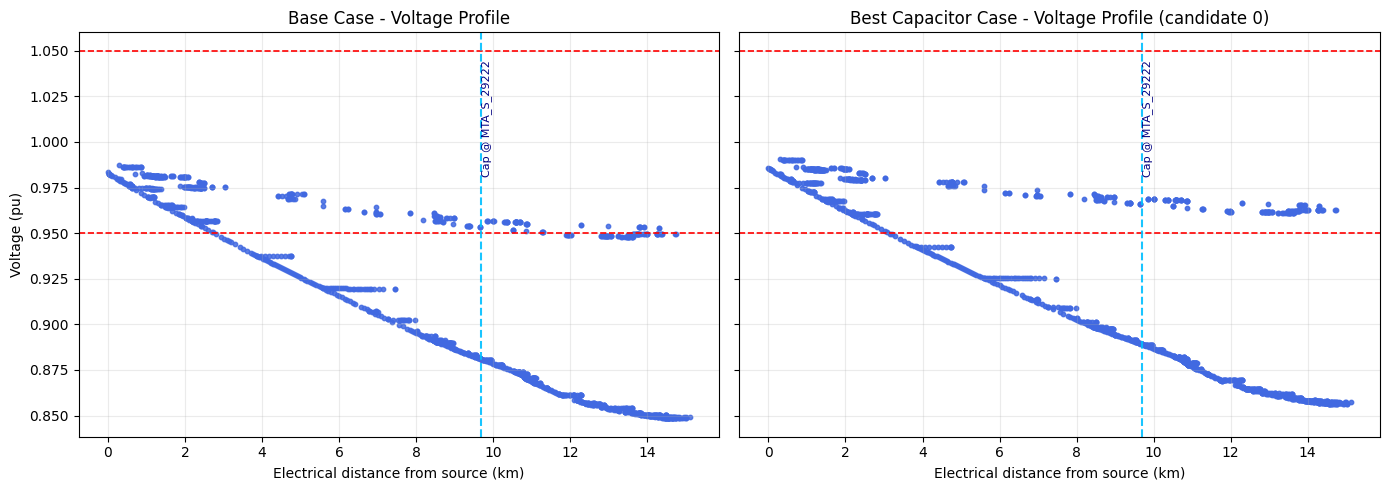

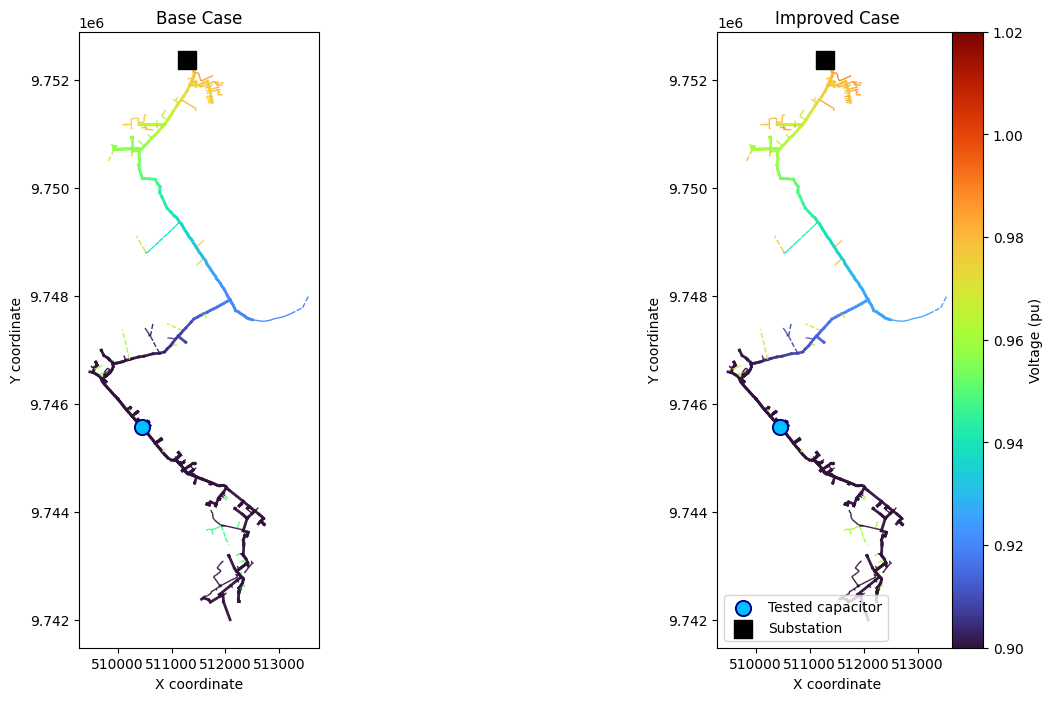

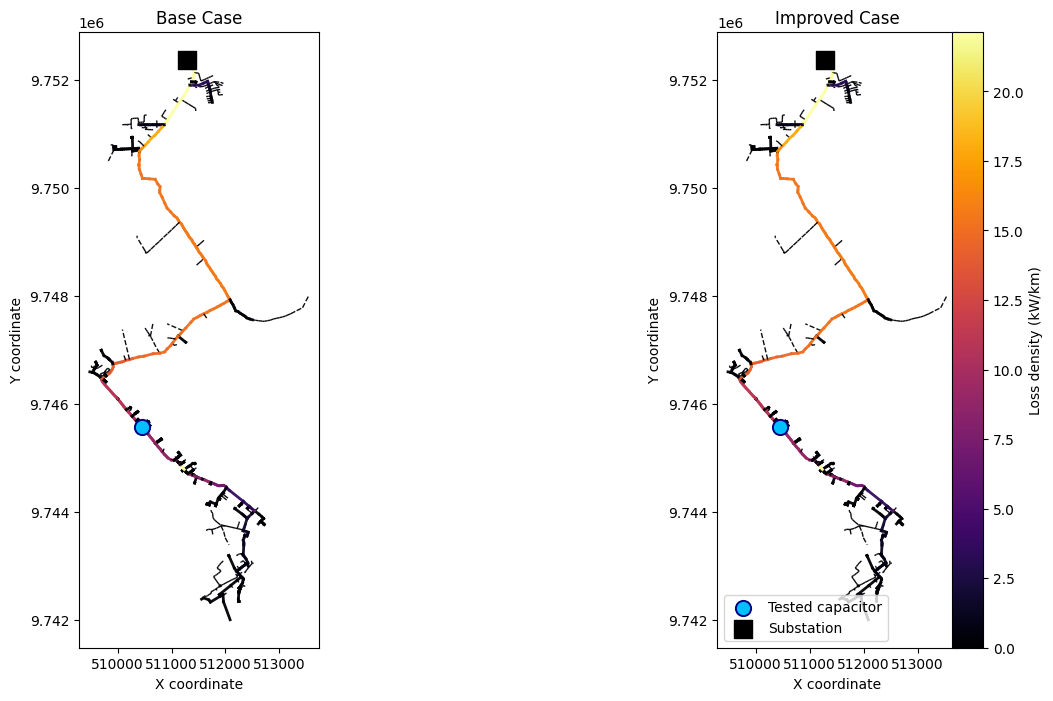

BEST REGULATOR SCENARIO - SIDE-BY-SIDE PLOTS


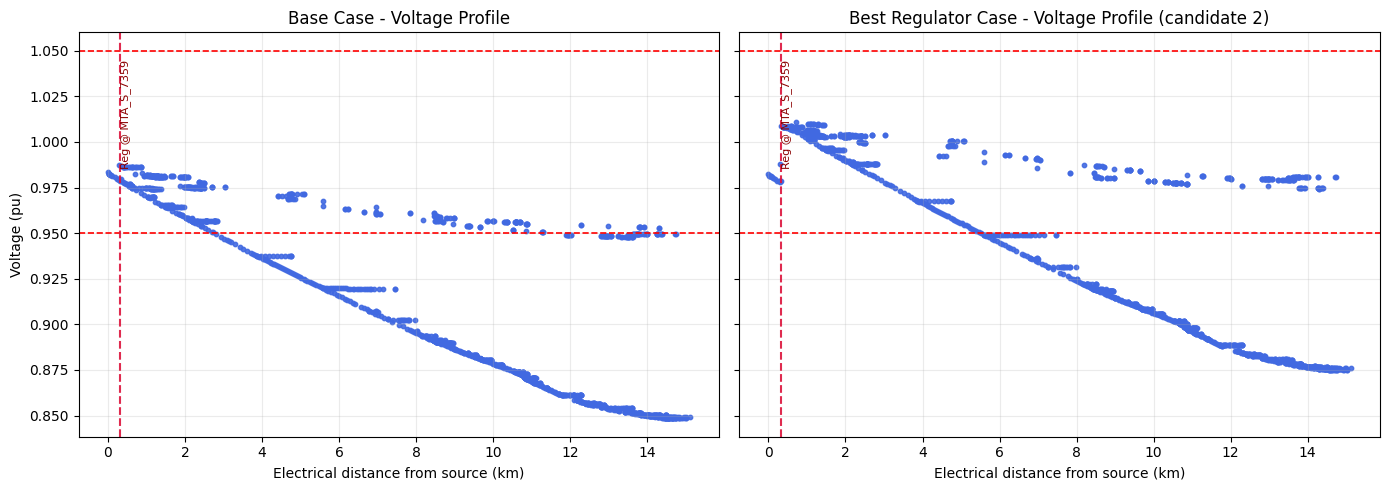

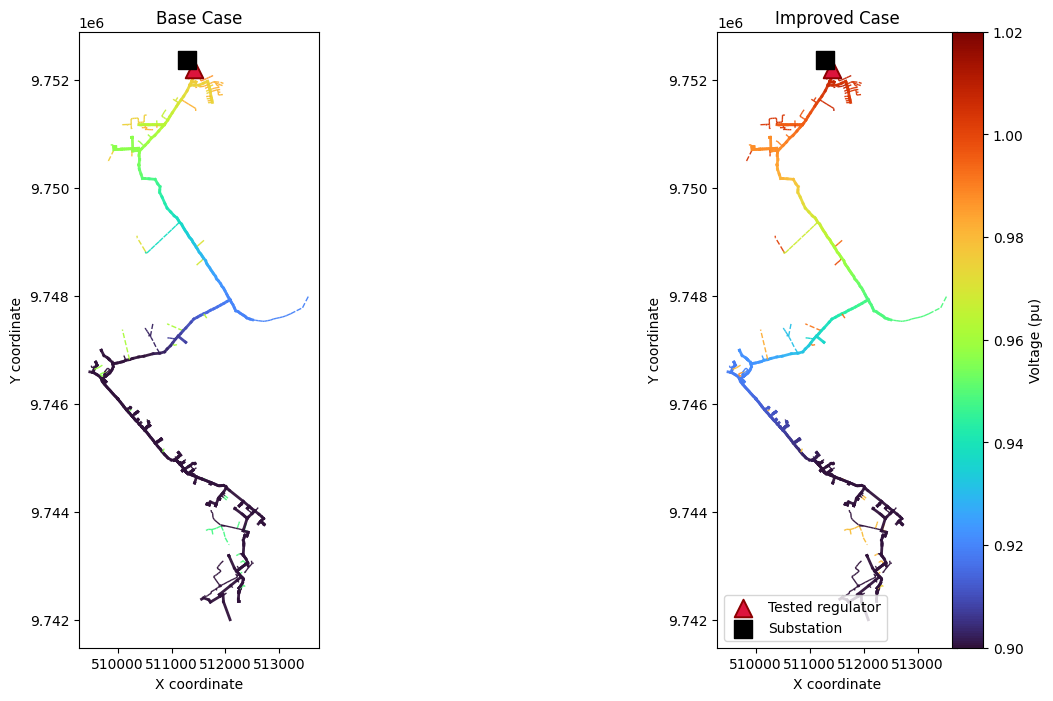

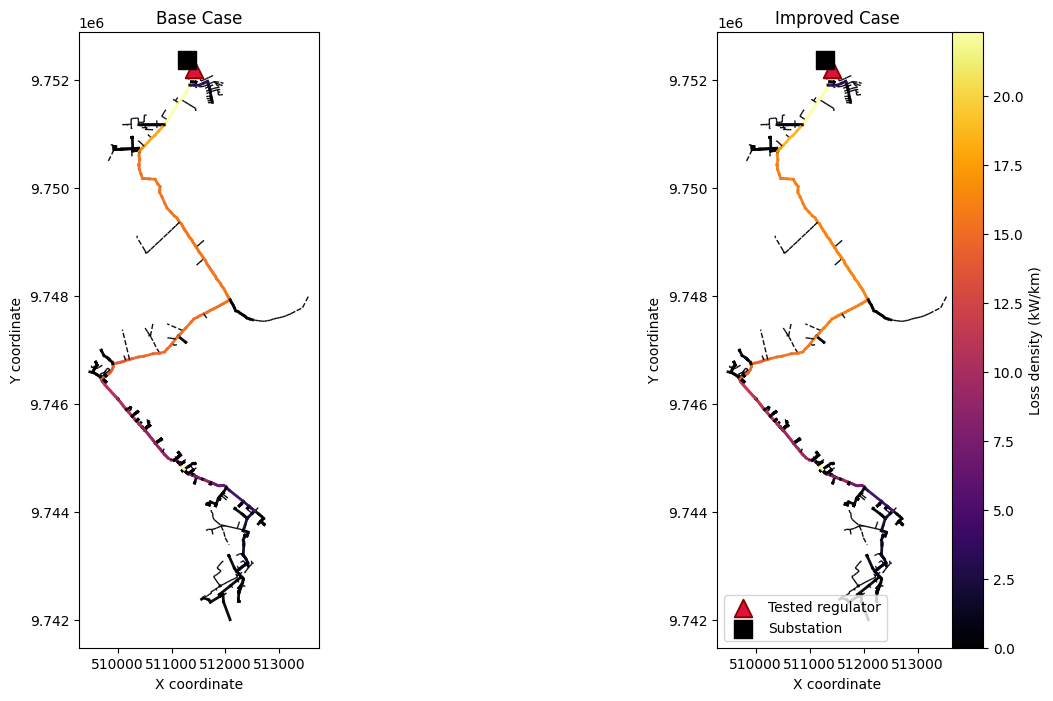

In [56]:
# CELL 1: SELECT BASE CAPACITOR AND BEST REGULATOR FROM RANKIGN TABLES ---------
# ============================================================
# SELECT BEST CAPACITOR AND BEST REGULATOR SCENARIOS
# ============================================================

# Best capacitor scenario:
# priority = lowest n_under, highest Vmin, lowest P_loss_kw
best_cap_row = (
    cap_loop_summary_df
    .sort_values(by=["n_under", "Vmin", "P_loss_kw"], ascending=[True, False, True])
    .iloc[0]
)

# Best regulator scenario:
# priority = lowest n_under, highest Vmin, lowest P_loss_kw
best_reg_row = (
    reg_loop_summary_df
    .sort_values(by=["n_under", "Vmin", "P_loss_kw"], ascending=[True, False, True])
    .iloc[0]
)

print("=== BEST CAPACITOR SCENARIO ===")
display(pd.DataFrame([best_cap_row]))

print("=== BEST REGULATOR SCENARIO ===")
display(pd.DataFrame([best_reg_row]))

# CELL 2: RECOVER THE FULL SCENARIO OBJECTS ------------------------------------
# ============================================================
# RECOVER THE FULL SCENARIO OBJECTS
# ============================================================

best_cap_index = int(best_cap_row["candidate_index"])
best_reg_index = int(best_reg_row["candidate_index"])

# Recover the full result dictionaries from the loop result lists
best_cap_result = cap_loop_results[best_cap_index]
best_reg_result = reg_loop_results[best_reg_index]

print("Best capacitor candidate index:", best_cap_index)
print("Best regulator candidate index:", best_reg_index)

print("\nBest capacitor location:", best_cap_result["cap_info"]["bus"])
print("Best regulator location:", best_reg_result["reg_info"]["parent_bus"], "->", best_reg_result["reg_info"]["child_bus"])

# CELL 3: BUILD PLOTTING POINTS FOR BEST CAPACITOR AND BEST REGULATOR-----------
# ============================================================
# BUILD PLOTTING TABLES FOR THE BEST SCENARIOS
# ============================================================

best_cap_plot_df = build_tested_capacitor_plot_table(best_cap_result, topology)
best_reg_plot_df = build_tested_regulator_plot_table(best_reg_result, topology)

print("Best capacitor plotting point:")
display(best_cap_plot_df)

print("Best regulator plotting point:")
display(best_reg_plot_df)

# CELL 4: PLOT THE BEST CAPACITOR SCENARIO -------------------------------------
# ============================================================
# PLOT BEST CAPACITOR SCENARIO
# ============================================================

print("==========================================")
print("BEST CAPACITOR SCENARIO - SIDE-BY-SIDE PLOTS")
print("==========================================")

plot_voltage_profile_side_by_side(
    base_df_bus_case=BASE_CASE_RESULTS["df_bus_case"],
    new_df_bus_case=best_cap_result["df_bus_case"],
    tested_cap_plot_df=best_cap_plot_df,
    title_left="Base Case - Voltage Profile",
    title_right=f"Best Capacitor Case - Voltage Profile (candidate {best_cap_index})",
    base_color="royalblue",
    new_color="royalblue",
    figsize=(14, 5)
)

plot_voltage_map_side_by_side(
    topology=topology,
    base_segments_v_df=BASE_CASE_RESULTS["segments_v_df"],
    new_segments_v_df=best_cap_result["segments_v_df"],
    tested_cap_plot_df=best_cap_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="turbo",
    vmin=0.90,
    vmax=1.02,
    figsize=(16, 8)
)

plot_loss_density_map_side_by_side(
    topology=topology,
    base_segments_loss_df=BASE_CASE_RESULTS["segments_loss_df"],
    new_segments_loss_df=best_cap_result["segments_loss_df"],
    tested_cap_plot_df=best_cap_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="inferno",
    vmax_quantile=0.98,
    figsize=(16, 8)
)

# CELL 5: PLOT THE BEST REGULATOR SCENARIO
# ============================================================
# PLOT BEST REGULATOR SCENARIO
# ============================================================

print("==========================================")
print("BEST REGULATOR SCENARIO - SIDE-BY-SIDE PLOTS")
print("==========================================")

plot_voltage_profile_side_by_side_regulator(
    base_df_bus_case=BASE_CASE_RESULTS["df_bus_case"],
    new_df_bus_case=best_reg_result["df_bus_case"],
    reg_result=best_reg_result,
    title_left="Base Case - Voltage Profile",
    title_right=f"Best Regulator Case - Voltage Profile (candidate {best_reg_index})",
    color="royalblue",
    figsize=(14, 5)
)

plot_voltage_map_side_by_side_regulator(
    topology=topology,
    base_segments_v_df=BASE_CASE_RESULTS["segments_v_df"],
    new_segments_v_df=best_reg_result["segments_v_df"],
    tested_reg_plot_df=best_reg_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="turbo",
    vmin=0.90,
    vmax=1.02,
    figsize=(16, 8)
)

plot_loss_density_map_side_by_side_regulator(
    topology=topology,
    base_segments_loss_df=BASE_CASE_RESULTS["segments_loss_df"],
    new_segments_loss_df=best_reg_result["segments_loss_df"],
    tested_reg_plot_df=best_reg_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="inferno",
    vmax_quantile=0.98,
    figsize=(16, 8)
)

TUNING R AND X COMPENSATOR PARAMETERS BEST REGULATOR OPTION

This code implements the following:

* A function that finds the representative downstream bus, extracts phasors and branch current, computes the initial $(R_0, X_0)$

* A loop that applies $(kR_0, kX_0)$, runs the regulator scenario for each $k$, builds a ranking table, plots the best tuned regulator case against the base case.

OBJECTIVE

Choose R and X in

```
RegControl
```

so that the regulator does not only hold its local bus near the setpoint, but instead compensates for the downstream voltage drop and gives better voltage support to a representative remote downstream area.

STAGE 1: Keep the best regulator location fixed

Do not change the selected regulator candidate. Use the best regulator scenario already found: same parent_bus, same child_bus, same inserted regulator bank, same regulator bus, same vreg, band, ptratio, ctprim, only tune $R$ and $X$. So the problem now is no longer where to place the regulator, but how much line-drop compensation it should apply.

Stage 2: Choose a representative downstream target bus

Recommended rule: From the buses downstream of the installed regulator, select a 3-phase bus at a user-defined percentage of the downstream corridor. For example: 40%, 50%, 60%, 70% of downstream electrical distance. Start with 50% or 60%.

Practical rule: Among downstream buses:

* keep only 3-phase buses
* compute distance from the regulator location to each downstream bus
* find the bus whose downstream distance is closest to the selected percentage

That bus becomes the remote-compensation reference bus.

Stage 3: Use the best regulator case with $R$=$X$=0 as the tuning baseline

Instead of estimating $R, X% from the original feeder without regulator, estimate them from the already inserted regulator case with $R$=$X$=0.

* the regulator is already in the correct structural position
* the branch current through the regulator location is the exact current  relevant for compensation
* the downstream corridor is already defined with the actual inserted device

So the baseline for tuning should be: best regulator installed, but with $R$=$X$=0. That is the cleanest reference.

Stage 4: Compute an equivalent downstream impedance

Now estimate the downstream equivalent impedance seen by the regulator. The quantities to extract are (for the $R$=$X$=0 scenario):

* At the regulator location: Use the branch current through the regulator insertion point. This should be the current flowing through the branch where the regulator was installed.

* At the sending side of the compensated corridor, use the voltage phasor at the regulator secondary bus.

* At the receiving side, use the voltage phasor at the selected representative downstream 3-phase bus.

Per-phase equivalent impedance: For each phase $\phi\in{A,B,C}$, compute:

$$
Z_{\mathrm{eq},\phi}=\frac{V_{\mathrm{reg-sec},\phi}-V_{\mathrm{remote},\phi}}{I_{\mathrm{reg},\phi}}
$$

where:
* $V_{\mathrm{reg-sec},\phi}$ is the phase voltage phasor at the regulator secondary bus
*	$V_{\mathrm{remote},\phi}$ is the phase voltage phasor at the representative downstream bus
* $I_{\mathrm{reg},\phi}$ is the phase current phasor through the regulator location

This gives:
$$
Z_{\mathrm{eq},\phi}=R_{\mathrm{eq},\phi}+jX_{\mathrm{eq},\phi}
$$

Stage 5 — Convert the impedance estimate into regulator $R$ and $X$ settings

RegControl $R$ and $X$ are not simply feeder ohms; they are entered as compensator volts referred to the regulator control quantities.A practical conversion is:

$$
R_{\mathrm{set},\phi}\approx\frac{CTPrim}{PTRatio}\ R_{\mathrm{eq},\phi}
$$
$$
X_{\mathrm{set},\phi}\approx\frac{CTPrim}{PTRatio}\ X_{\mathrm{eq},\phi}
$$

if the branch current is taken in primary amperes and the impedance is in ohms.
This gives a first estimate in the regulator-control voltage basis.

Practical simplification

Because we are using a bank of three single-phase regulators, there are two options:

* Option A — Common $R$ and $X$ for all phases. Take the average of the three phase values:

$$
R_{\mathrm{set}}=\mathrm{avg}(R_{setA},R_{setB},R_{setC})
$$
$$
X_{\mathrm{set}}=\mathrm{avg}(X_{setA},X_{setB},X_{setC})
$$

* Option B — Phase-specific $R$and $X$. Use separate values for each phase regulator. This is more precise, but more complex. Do this if the feeder is strongly unbalanced and the common setting performs poorly.

We start with common $R$ and $X$ using an average across phases, to avoid outliers.

Stage 6: Tune with a scale factor (do not trust analytical estimate alone)

This is the key practical improvement. Even if the analytical estimate is sound, OpenDSS regulator behavior depends on: actual current distribution, 	unbalance, control deadband, tap discretization, chosen remote-bus percentage, feeder topology.

So after obtaining initial values $R_0$, $X_0$, keep their ratio fixed and tune them with a scalar multiplier:

$$
R=kR_0,X=kX_0
$$

with a small sweep such as:
$$
k\in{0.50,\mathrm{\;}0.75,\mathrm{\;}1.00,\mathrm{\;}1.25,\mathrm{\;}1.50}
$$
This is much more stable than trying to tune $R$ and $X$ independently from the beginning.

Stage 7: Evaluate each $k$ by a clear objective

For each tuned pair $(R,X)$, run the regulator scenario and compare against the base case. The suggested evaluation metrics are the same we have built previously:
* minimum feeder voltage
* number of undervoltage buses < 0.95.
* number of overvoltage buses > 1.05
* total active losses
* optionally: representative downstream bus voltage

Recommended objective priority: Rank the tuning candidates in this order:

* lowest number of undervoltage buses
* no or minimal overvoltage buses
* highest minimum voltage
* lowest losses

This keeps the control goal consistent with voltage regulation first, not loss minimization first.

SUMMARY

The proposed LDC tuning method is:
1. Select the best regulator location from the candidate ranking obtained with $R$=$X$=0.
2. Define a representative downstream 3-phase bus at a user-selected percentage of downstream electrical distance.
3. From the solved $R$=$X$=0 regulator case, extract:
* regulator-location current phasors
* regulator secondary-bus voltage phasors
* representative downstream-bus voltage phasors
4. Compute a per-phase equivalent downstream impedance.
5. Convert that impedance into initial RegControl $R$ and $X$ settings.
6. Use the initial $R/X$ ratio and tune its magnitude with a small scale-factor sweep.
7. Select the pair that best improves voltage compliance without creating overvoltage.




Regulator R/X tuning settings loaded.
=== INITIAL R/X ESTIMATE ===
Representative downstream bus info:
{'child_bus': 'MTA_S_7359', 'remote_bus': 'MTA_S_6958', 'target_distance_km': 7.720034051184999, 'remote_distance_km': 7.7753217389100024}

Equivalent downstream R_eq (ohm): 1.0477856476879894
Equivalent downstream X_eq (ohm): 2.949647562831528

Initial RegControl R0 (volts): 9.468615533410754
Initial RegControl X0 (volts): 26.655336225630883
Running R/X tuning case: k=0.50, R=4.7343, X=13.3277
Running R/X tuning case: k=0.75, R=7.1015, X=19.9915
Running R/X tuning case: k=1.00, R=9.4686, X=26.6553
Running R/X tuning case: k=1.25, R=11.8358, X=33.3192
Running R/X tuning case: k=1.50, R=14.2029, X=39.9830
=== R/X TUNING SUMMARY ===


,scale_factor,R_setting,X_setting,parent_bus,child_bus,reg_bus,Vmin,Vmax,n_under,n_over,P_loss_kw,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss,converged,tuning_rank
0,1.25,11.8358,33.3192,MTA_S_7358,MTA_S_7359,REG_RX_1_25_BUS_MTA_S_7358_MTA_S_7359,0.9245,1.0688,447,154,302.1670,0.0760,-483.0,41.8751,16.0878,True,1
1,1.50,14.2029,39.9830,MTA_S_7358,MTA_S_7359,REG_RX_1_5_BUS_MTA_S_7358_MTA_S_7359,0.9245,1.0688,447,370,302.9853,0.0760,-483.0,42.6934,16.4021,True,2
2,1.00,9.4686,26.6553,MTA_S_7358,MTA_S_7359,REG_RX_1_0_BUS_MTA_S_7358_MTA_S_7359,0.9196,1.0630,509,70,299.5429,0.0711,-421.0,39.2510,15.0796,True,3
3,0.75,7.1015,19.9915,MTA_S_7358,MTA_S_7359,REG_RX_0_75_BUS_MTA_S_7358_MTA_S_7359,0.9096,1.0514,605,4,295.8595,0.0611,-325.0,35.5676,13.6645,True,4
4,0.50,4.7343,13.3277,MTA_S_7358,MTA_S_7359,REG_RX_0_5_BUS_MTA_S_7358_MTA_S_7359,0.8996,1.0398,704,0,292.5186,0.0511,-226.0,32.2267,12.3810,True,5


=== BEST TUNED R/X CASE ===


,scale_factor,R_setting,X_setting,parent_bus,child_bus,reg_bus,Vmin,Vmax,n_under,n_over,P_loss_kw,delta_Vmin,delta_n_under,delta_P_loss_kw,pct_delta_P_loss,converged,tuning_rank
0,1.25,11.835769,33.31917,MTA_S_7358,MTA_S_7359,REG_RX_1_25_BUS_MTA_S_7358_MTA_S_7359,0.924469,1.06876,447,154,302.167029,0.075994,-483.0,41.875146,16.087765,True,1


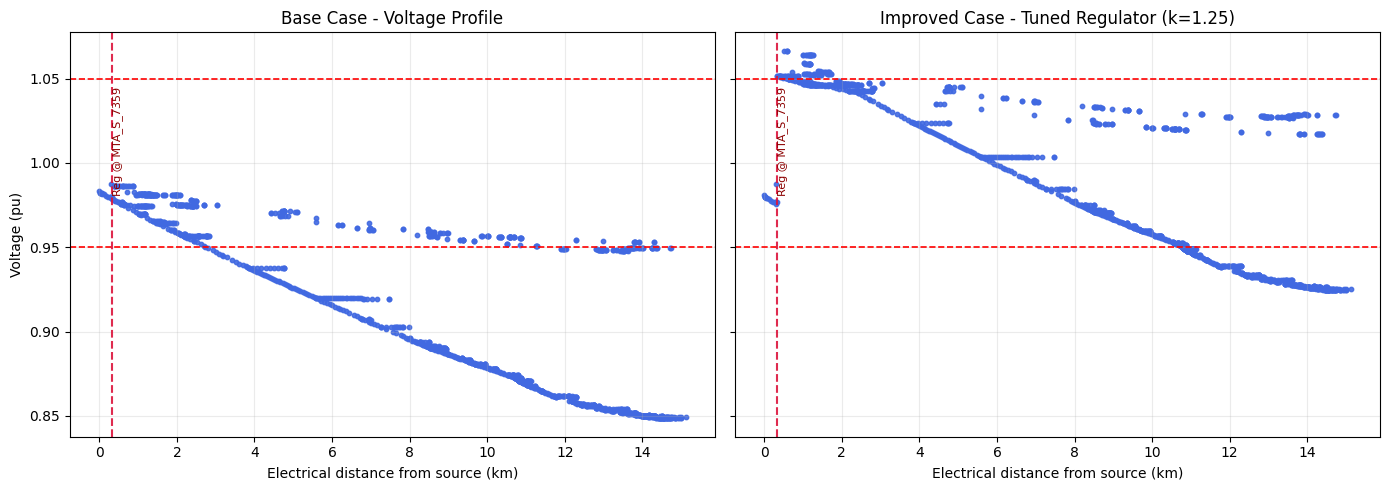

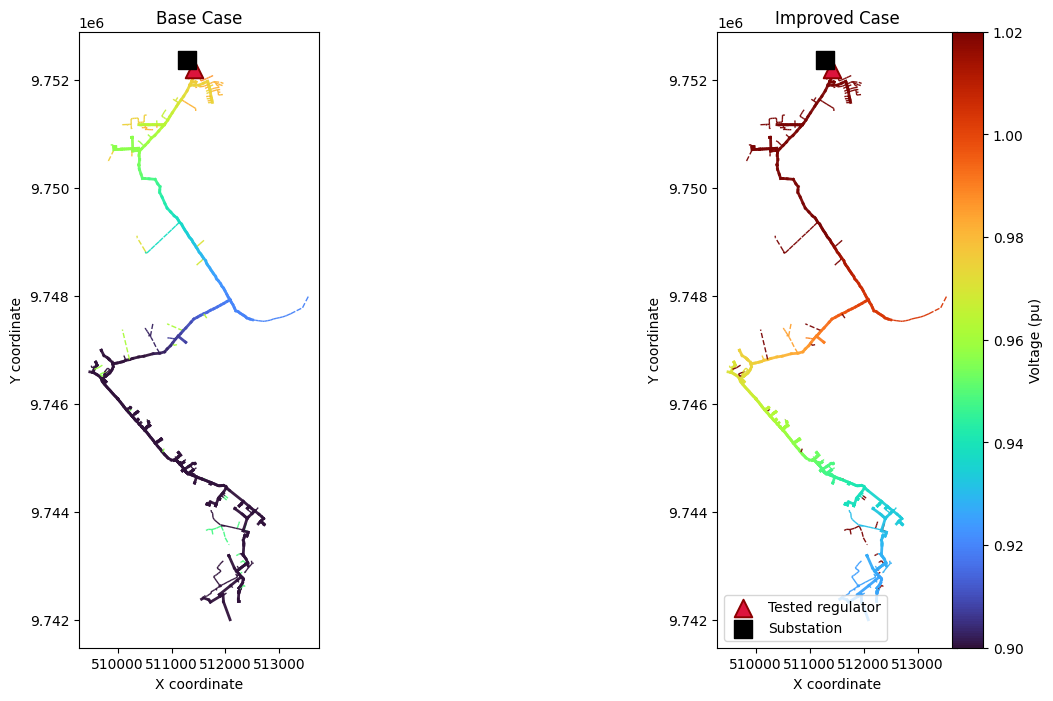

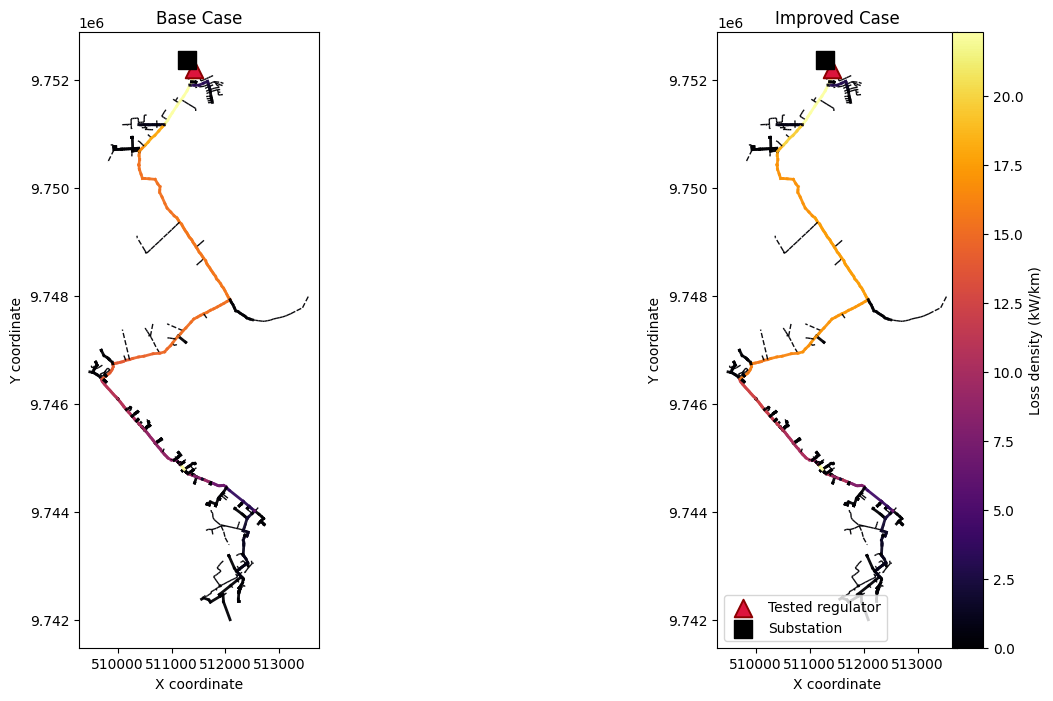

In [58]:
# CELL 1: USER SETTINGS FOR LDC TUNING -----------------------------------------
# ============================================================
# REGULATOR R/X TUNING - USER SETTINGS
# ============================================================

# Choose the downstream target location as a fraction of the
# downstream corridor from the regulator child bus to the furthest
# downstream bus. Example: 0.50 = 50%
DOWNSTREAM_TARGET_FRACTION = 0.50

# Scale-factor sweep around the estimated R0, X0
RX_SCALE_FACTORS = [0.50, 0.75, 1.00, 1.25, 1.50]

# Keep the same regulator candidate already selected as "best regulator"
USE_BEST_REGULATOR_FROM_LOOP = True

# Voltage limits
VMIN_LIMIT_RX = 0.95
VMAX_LIMIT_RX = 1.05

print("Regulator R/X tuning settings loaded.")

# CELL 2: PHASOR AND REPRESENTATIVE-BUS HELPERS---------------------------------
import numpy as np
import pandas as pd
import math

def mag_angle_to_complex(mag, ang_deg):
    """
    Convert magnitude/angle to complex number.
    """
    ang_rad = np.deg2rad(ang_deg)
    return mag * (np.cos(ang_rad) + 1j * np.sin(ang_rad))


def get_bus_phase_voltage_phasors(dss, bus_name: str) -> dict:
    """
    Get LN voltage phasors at a bus for phases 1, 2, 3 if available.

    Returns
    -------
    dict
        {1: complex, 2: complex, 3: complex}
    """
    dss.Circuit.SetActiveBus(bus_name)

    nodes = list(dss.Bus.Nodes())
    vmag_ang = list(dss.Bus.VMagAngle())   # volts and angle

    mags = vmag_ang[0::2]
    angs = vmag_ang[1::2]

    out = {}
    for node, mag, ang in zip(nodes, mags, angs):
        if int(node) in [1, 2, 3]:
            out[int(node)] = mag_angle_to_complex(mag, ang)

    return out


def get_line_terminal_phase_currents(dss, line_name: str, terminal: int = 1) -> dict:
    """
    Get current phasors for phases 1, 2, 3 at a specified terminal of an active line.

    Parameters
    ----------
    line_name : str
        OpenDSS line name, e.g. 'N_7160_MTA'
    terminal : int
        1 or 2

    Returns
    -------
    dict
        {1: complex, 2: complex, 3: complex}
    """
    dss.Lines.Name(line_name)

    currents_mag_ang = list(dss.CktElement.CurrentsMagAng())
    node_order = list(dss.CktElement.NodeOrder())
    ncond = int(dss.CktElement.NumConductors())

    # Split current list by conductor, per terminal
    start = (terminal - 1) * ncond
    end = terminal * ncond

    terminal_nodes = node_order[start:end]
    terminal_curr_mag = currents_mag_ang[2*start:2*end:2]
    terminal_curr_ang = currents_mag_ang[2*start+1:2*end:2]

    out = {}
    for node, mag, ang in zip(terminal_nodes, terminal_curr_mag, terminal_curr_ang):
        if int(node) in [1, 2, 3]:
            out[int(node)] = mag_angle_to_complex(mag, ang)

    return out


def bus_is_three_phase_in_active_circuit(dss, bus_name: str) -> bool:
    """
    Check whether a bus has phases 1, 2, 3 in the active circuit.
    """
    dss.Circuit.SetActiveBus(bus_name)
    nodes = [int(n) for n in dss.Bus.Nodes()]
    return all(ph in nodes for ph in [1, 2, 3])


def select_representative_downstream_3ph_bus(topology: dict,
                                             child_bus: str,
                                             dss,
                                             fraction: float = 0.50) -> dict:
    """
    Select a representative downstream 3-phase bus at a target fraction
    of the downstream corridor measured from child_bus.

    Parameters
    ----------
    topology : dict
    child_bus : str
    dss : opendssdirect module
    fraction : float
        0.0 to 1.0

    Returns
    -------
    dict
        {
            "child_bus": ...,
            "remote_bus": ...,
            "target_distance_km": ...,
            "remote_distance_km": ...
        }
    """
    child_bus = str(child_bus).upper()

    descendants = topology["descendants"][child_bus]
    df_bus = topology["bus_table"].copy()
    df_bus["bus"] = df_bus["bus"].astype(str).str.upper()

    down_df = df_bus[df_bus["bus"].isin([str(b).upper() for b in descendants])].copy()

    # Keep only buses with valid distance and 3-phase buses in active circuit
    down_df = down_df.dropna(subset=["distance_km"]).copy()
    down_df = down_df[down_df["bus"].apply(lambda b: bus_is_three_phase_in_active_circuit(dss, b))].copy()

    if down_df.empty:
        raise ValueError("No downstream 3-phase buses found for representative-bus selection.")

    child_dist = float(
        df_bus.loc[df_bus["bus"] == child_bus, "distance_km"].iloc[0]
    )

    max_dist = float(down_df["distance_km"].max())
    target_dist = child_dist + fraction * (max_dist - child_dist)

    down_df["distance_error"] = (down_df["distance_km"] - target_dist).abs()
    chosen = down_df.sort_values("distance_error").iloc[0]

    return {
        "child_bus": child_bus,
        "remote_bus": str(chosen["bus"]).upper(),
        "target_distance_km": target_dist,
        "remote_distance_km": float(chosen["distance_km"])
    }

# CELL 3: ESTIMATE INITIAL R0 AND X0--------------------------------------------
def estimate_initial_rx_from_best_regulator(topology: dict,
                                            reg_candidates: pd.DataFrame,
                                            segments_df: pd.DataFrame,
                                            best_reg_result: dict,
                                            dss,
                                            feeder_path: str,
                                            downstream_target_fraction: float = 0.50,
                                            vmin_limit: float = 0.95,
                                            vmax_limit: float = 1.05) -> dict:
    """
    Estimate initial RegControl R0 and X0 from the best regulator candidate
    using the version-1 regulator case (R = X = 0).

    Method
    ------
    1) Re-run the best regulator candidate with R = X = 0
    2) Select a representative downstream 3-phase bus
    3) Read:
       - voltage phasors at regulator secondary bus
       - voltage phasors at representative downstream bus
       - current phasors in the edited downstream line at the regulator side
    4) Compute equivalent downstream impedance per phase
    5) Convert to RegControl volts using CTPrim / PTRatio

    Returns
    -------
    dict
    """
    best_idx = int(best_reg_result["candidate_index"])

    # Re-run the same best regulator candidate with R = X = 0
    baseline_reg = run_single_regulator_candidate_scenario_v1(
        dss=dss,
        feeder_path=feeder_path,
        topology=topology,
        reg_candidates=reg_candidates,
        segments_df=segments_df,
        candidate_index=best_idx,
        kva_multiplier=REG_KVA_MULTIPLIER_LOOP if "REG_KVA_MULTIPLIER_LOOP" in globals() else 1.25,
        scenario_name="REG_RX_BASELINE",
        vreg=REG_VREG_LOOP if "REG_VREG_LOOP" in globals() else 122.0,
        band=REG_BAND_LOOP if "REG_BAND_LOOP" in globals() else 2.0,
        ctprim=REG_CT_PRIM_LOOP if "REG_CT_PRIM_LOOP" in globals() else 600.0,
        xhl=REG_XHL_LOOP if "REG_XHL_LOOP" in globals() else 0.01,
        loadloss_pct=REG_LOADLOSS_PCT_LOOP if "REG_LOADLOSS_PCT_LOOP" in globals() else 0.10,
        mintap=REG_MINTAP_LOOP if "REG_MINTAP_LOOP" in globals() else 0.90,
        maxtap=REG_MAXTAP_LOOP if "REG_MAXTAP_LOOP" in globals() else 1.10,
        numtaps=REG_NUMTAPS_LOOP if "REG_NUMTAPS_LOOP" in globals() else 32,
        vmin_limit=vmin_limit,
        vmax_limit=vmax_limit
    )

    if not baseline_reg["converged"]:
        raise RuntimeError("Baseline regulator case (R=X=0) did not converge during R/X estimation.")

    reg_info = baseline_reg["reg_info"]
    child_bus = reg_info["child_bus"]
    reg_bus = reg_info["reg_bus"]
    edited_line = reg_info["edited_line_name"]
    edit_side = reg_info["edited_line_side"]
    ptratio = float(reg_info["ptratio"])
    ctprim = REG_CT_PRIM_LOOP if "REG_CT_PRIM_LOOP" in globals() else 600.0

    # Representative downstream bus
    rep = select_representative_downstream_3ph_bus(
        topology=topology,
        child_bus=child_bus,
        dss=dss,
        fraction=downstream_target_fraction
    )
    remote_bus = rep["remote_bus"]

    # Voltage phasors
    v_reg = get_bus_phase_voltage_phasors(dss, reg_bus)
    v_remote = get_bus_phase_voltage_phasors(dss, remote_bus)

    # Current phasors at the regulator-side terminal of edited downstream line
    terminal = 1 if str(edit_side).lower() == "bus1" else 2
    i_reg = get_line_terminal_phase_currents(dss, edited_line, terminal=terminal)

    # Common available phases
    common_phases = sorted(set(v_reg.keys()) & set(v_remote.keys()) & set(i_reg.keys()))
    if len(common_phases) < 3:
        raise ValueError(f"Could not recover 3 common phases for R/X estimation. Found phases: {common_phases}")

    z_phase = {}
    r_vals = []
    x_vals = []

    for ph in common_phases:
        dv = v_reg[ph] - v_remote[ph]
        i = i_reg[ph]

        if abs(i) < 1e-6:
            continue

        z_eq = dv / i
        z_phase[ph] = z_eq

        # Use absolute values of real/imag parts for initial estimate
        r_vals.append(abs(np.real(z_eq)))
        x_vals.append(abs(np.imag(z_eq)))

    if len(r_vals) == 0 or len(x_vals) == 0:
        raise ValueError("Could not compute valid phase impedances for R/X estimation.")

    # Robust aggregate across phases
    r_eq = float(np.median(r_vals))
    x_eq = float(np.median(x_vals))

    # Convert ohms to regulator control volts
    R0 = (ctprim / ptratio) * r_eq
    X0 = (ctprim / ptratio) * x_eq

    return {
        "baseline_reg_result": baseline_reg,
        "representative_bus_info": rep,
        "reg_bus": reg_bus,
        "remote_bus": remote_bus,
        "edited_line": edited_line,
        "edited_line_terminal": terminal,
        "z_phase": z_phase,
        "r_eq_ohm": r_eq,
        "x_eq_ohm": x_eq,
        "R0": R0,
        "X0": X0,
        "ptratio": ptratio,
        "ctprim": ctprim
    }


rx_estimate = estimate_initial_rx_from_best_regulator(
    topology=topology,
    reg_candidates=reg_candidates,
    segments_df=segments_df,
    best_reg_result=best_reg_result,
    dss=dss,
    feeder_path=feeder_path,
    downstream_target_fraction=DOWNSTREAM_TARGET_FRACTION,
    vmin_limit=VMIN_LIMIT_RX,
    vmax_limit=VMAX_LIMIT_RX
)

print("=== INITIAL R/X ESTIMATE ===")
print("Representative downstream bus info:")
print(rx_estimate["representative_bus_info"])
print()
print("Equivalent downstream R_eq (ohm):", rx_estimate["r_eq_ohm"])
print("Equivalent downstream X_eq (ohm):", rx_estimate["x_eq_ohm"])
print()
print("Initial RegControl R0 (volts):", rx_estimate["R0"])
print("Initial RegControl X0 (volts):", rx_estimate["X0"])

# CELL 4: REGULATOR INSERTION WITH CUSTOM R, X----------------------------------
def insert_three_phase_regulator_bank_with_rx(dss,
                                              topology: dict,
                                              branch_row: pd.Series,
                                              parent_bus: str,
                                              child_bus: str,
                                              kva_total_3ph: float,
                                              R_setting: float,
                                              X_setting: float,
                                              scenario_name: str = "REG_RX",
                                              vreg: float = 122.0,
                                              band: float = 2.0,
                                              ctprim: float = 600.0,
                                              xhl: float = 0.01,
                                              loadloss_pct: float = 0.10,
                                              mintap: float = 0.90,
                                              maxtap: float = 1.10,
                                              numtaps: int = 32):
    """
    Same structural insertion as version 1, but now with user-specified RegControl R and X.
    """
    parent_bus = str(parent_bus).upper()
    child_bus = str(child_bus).upper()

    assert_three_phase_candidate(branch_row)

    reg_bus = build_regulator_bus_name(parent_bus, child_bus, scenario_name=scenario_name)
    dss_line_name = build_full_dss_line_name(branch_row)

    reg_names = {
        "A": f"{scenario_name}_A",
        "B": f"{scenario_name}_B",
        "C": f"{scenario_name}_C"
    }

    regctrl_names = {
        "A": f"{scenario_name}_CTRL_A",
        "B": f"{scenario_name}_CTRL_B",
        "C": f"{scenario_name}_CTRL_C"
    }

    bus1 = str(branch_row["bus1"]).upper()
    bus2 = str(branch_row["bus2"]).upper()
    bus1_raw = str(branch_row["bus1_raw"])
    bus2_raw = str(branch_row["bus2_raw"])

    if bus1 == parent_bus and bus2 == child_bus:
        edit_side = "bus1"
    elif bus2 == parent_bus and bus1 == child_bus:
        edit_side = "bus2"
    else:
        raise ValueError("Branch row does not match the requested parent/child buses.")

    reg_bus_3ph = f"{reg_bus}.1.2.3"

    kv_ln = get_bus_ln_base_kv(dss, parent_bus)
    kva_a, kva_b, kva_c = split_total_bank_kva_equally(kva_total_3ph)
    ptratio = (kv_ln * 1000.0) / 120.0

    if edit_side == "bus1":
        cmd_edit_line = f"Edit Line.{dss_line_name} bus1={reg_bus_3ph}"
    else:
        cmd_edit_line = f"Edit Line.{dss_line_name} bus2={reg_bus_3ph}"

    dss.Text.Command(cmd_edit_line)

    phase_map = {"A": 1, "B": 2, "C": 3}
    kva_map = {"A": kva_a, "B": kva_b, "C": kva_c}

    reg_cmds = []
    ctrl_cmds = []

    for ph_name in ["A", "B", "C"]:
        ph = phase_map[ph_name]
        kva_ph = kva_map[ph_name]

        xf_name = reg_names[ph_name]
        ctrl_name = regctrl_names[ph_name]

        bus_parent_ph = f"{parent_bus}.{ph}"
        bus_reg_ph = f"{reg_bus}.{ph}"

        cmd_xf = (
            f"New Transformer.{xf_name} "
            f"phases=1 windings=2 "
            f"buses=[{bus_parent_ph} {bus_reg_ph}] "
            f"kvs=[{kv_ln:.6f} {kv_ln:.6f}] "
            f"kvas=[{kva_ph:.6f} {kva_ph:.6f}] "
            f"xhl={xhl:.6f} "
            f"%loadloss={loadloss_pct:.6f} "
            f"maxtap={maxtap:.6f} "
            f"mintap={mintap:.6f} "
            f"numtaps={int(numtaps)}"
        )

        cmd_ctrl = (
            f"New RegControl.{ctrl_name} "
            f"transformer={xf_name} "
            f"winding=2 "
            f"vreg={vreg:.6f} "
            f"band={band:.6f} "
            f"ptratio={ptratio:.6f} "
            f"ctprim={ctprim:.6f} "
            f"R={R_setting:.6f} "
            f"X={X_setting:.6f}"
        )

        dss.Text.Command(cmd_xf)
        dss.Text.Command(cmd_ctrl)

        reg_cmds.append(cmd_xf)
        ctrl_cmds.append(cmd_ctrl)

    return {
        "parent_bus": parent_bus,
        "child_bus": child_bus,
        "reg_bus": reg_bus,
        "edited_line_name": dss_line_name,
        "edited_line_side": edit_side,
        "kva_total_3ph": kva_total_3ph,
        "kva_per_phase": [kva_a, kva_b, kva_c],
        "kv_ln": kv_ln,
        "ptratio": ptratio,
        "R_setting": R_setting,
        "X_setting": X_setting,
        "regulator_names": reg_names,
        "regcontrol_names": regctrl_names,
        "line_edit_command": cmd_edit_line,
        "xf_commands": reg_cmds,
        "ctrl_commands": ctrl_cmds
    }


def run_single_regulator_candidate_scenario_with_rx(dss,
                                                    feeder_path: str,
                                                    topology: dict,
                                                    reg_candidates: pd.DataFrame,
                                                    segments_df: pd.DataFrame,
                                                    candidate_index: int,
                                                    kva_multiplier: float,
                                                    R_setting: float,
                                                    X_setting: float,
                                                    scenario_name: str = "REG_RX",
                                                    vreg: float = 122.0,
                                                    band: float = 2.0,
                                                    ctprim: float = 600.0,
                                                    xhl: float = 0.01,
                                                    loadloss_pct: float = 0.10,
                                                    mintap: float = 0.90,
                                                    maxtap: float = 1.10,
                                                    numtaps: int = 32,
                                                    vmin_limit: float = 0.95,
                                                    vmax_limit: float = 1.05):
    """
    Run one regulator scenario with custom R and X.
    """
    cand = reg_candidates.iloc[int(candidate_index)].copy()

    parent_bus = str(cand["parent_bus"]).upper()
    child_bus = str(cand["bus"]).upper()

    branch_row = find_branch_row_between_buses(topology, parent_bus, child_bus)
    assert_three_phase_candidate(branch_row)

    kva_total_3ph = compute_total_regulator_bank_kva(
        candidate_row=cand,
        kva_multiplier=kva_multiplier
    )

    master_file = os.path.join(feeder_path, "Master.dss")
    dss.Text.Command(f'compile "{master_file}"')
    dss.Solution.Solve()

    if not dss.Solution.Converged():
        raise RuntimeError("Base feeder did not converge after recompiling Master.dss.")

    reg_info = insert_three_phase_regulator_bank_with_rx(
        dss=dss,
        topology=topology,
        branch_row=branch_row,
        parent_bus=parent_bus,
        child_bus=child_bus,
        kva_total_3ph=kva_total_3ph,
        R_setting=R_setting,
        X_setting=X_setting,
        scenario_name=scenario_name,
        vreg=vreg,
        band=band,
        ctprim=ctprim,
        xhl=xhl,
        loadloss_pct=loadloss_pct,
        mintap=mintap,
        maxtap=maxtap,
        numtaps=numtaps
    )

    dss.Solution.Solve()
    converged = bool(dss.Solution.Converged())

    if not converged:
        return {
            "scenario_type": "REGULATOR_RX",
            "candidate_index": int(candidate_index),
            "candidate_row": cand,
            "reg_info": reg_info,
            "converged": False
        }

    df_v_new = extract_bus_voltages_from_dss(dss, topology["bus_table"])
    df_bus_case_new = topology["bus_table"].merge(df_v_new, on="bus", how="left")

    new_voltage_metrics = summarize_voltage_metrics(
        df_bus_case_new,
        vmin_limit=vmin_limit,
        vmax_limit=vmax_limit
    )

    new_loss_metrics = get_total_losses_from_dss(dss)

    segments_v_new = build_voltage_segments_table(segments_df, df_bus_case_new)
    df_line_losses_new = extract_line_losses_from_dss(dss)
    segments_loss_new = build_loss_density_segments_table(segments_df, df_line_losses_new)

    base_v = BASE_CASE_RESULTS["voltage_metrics"]
    base_l = BASE_CASE_RESULTS["loss_metrics"]

    comparison = {
        "delta_vmin": new_voltage_metrics["vmin"] - base_v["vmin"],
        "delta_vmax": new_voltage_metrics["vmax"] - base_v["vmax"] if pd.notna(new_voltage_metrics["vmax"]) and pd.notna(base_v["vmax"]) else np.nan,
        "delta_n_under": new_voltage_metrics["n_under"] - base_v["n_under"],
        "delta_n_over": new_voltage_metrics["n_over"] - base_v["n_over"] if pd.notna(new_voltage_metrics["n_over"]) and pd.notna(base_v["n_over"]) else np.nan,
        "delta_p_loss_kw": new_loss_metrics["p_loss_kw"] - base_l["p_loss_kw"],
        "pct_p_loss_change": (
            100.0 * (new_loss_metrics["p_loss_kw"] - base_l["p_loss_kw"]) / base_l["p_loss_kw"]
            if base_l["p_loss_kw"] != 0 else np.nan
        )
    }

    return {
        "scenario_type": "REGULATOR_RX",
        "candidate_index": int(candidate_index),
        "candidate_row": cand,
        "branch_row": branch_row,
        "reg_info": reg_info,
        "converged": converged,
        "df_bus_case": df_bus_case_new,
        "segments_v_df": segments_v_new,
        "line_losses_df": df_line_losses_new,
        "segments_loss_df": segments_loss_new,
        "voltage_metrics": new_voltage_metrics,
        "loss_metrics": new_loss_metrics,
        "comparison": comparison
    }

# CELL 5: SWEEP SCALE FACTOR AND RANK TUNED CASES-------------------------------
def build_rx_tuning_summary_row(result: dict, scale_factor: float) -> dict:
    """
    Flatten one tuned regulator scenario into a summary row.
    """
    reg_info = result["reg_info"]
    vm = result["voltage_metrics"]
    lm = result["loss_metrics"]
    cmp = result["comparison"]

    return {
        "scale_factor": float(scale_factor),
        "R_setting": float(reg_info["R_setting"]),
        "X_setting": float(reg_info["X_setting"]),
        "parent_bus": str(reg_info["parent_bus"]).upper(),
        "child_bus": str(reg_info["child_bus"]).upper(),
        "reg_bus": str(reg_info["reg_bus"]).upper(),
        "Vmin": float(vm["vmin"]),
        "Vmax": float(vm["vmax"]),
        "n_under": int(vm["n_under"]),
        "n_over": int(vm["n_over"]) if pd.notna(vm["n_over"]) else np.nan,
        "P_loss_kw": float(lm["p_loss_kw"]),
        "delta_Vmin": float(cmp["delta_vmin"]),
        "delta_n_under": float(cmp["delta_n_under"]),
        "delta_P_loss_kw": float(cmp["delta_p_loss_kw"]),
        "pct_delta_P_loss": float(cmp["pct_p_loss_change"]),
        "converged": bool(result["converged"])
    }


def run_rx_scale_sweep_for_best_regulator(dss,
                                          feeder_path: str,
                                          topology: dict,
                                          reg_candidates: pd.DataFrame,
                                          segments_df: pd.DataFrame,
                                          best_reg_result: dict,
                                          rx_estimate: dict,
                                          scale_factors: list,
                                          vmin_limit: float = 0.95,
                                          vmax_limit: float = 1.05):
    """
    Run the best regulator candidate with scaled R/X values.

    Returns
    -------
    results_list : list[dict]
    summary_df : pd.DataFrame
    """
    best_idx = int(best_reg_result["candidate_index"])
    R0 = float(rx_estimate["R0"])
    X0 = float(rx_estimate["X0"])

    results_list = []
    summary_rows = []

    for k in scale_factors:
        Rk = k * R0
        Xk = k * X0

        print(f"Running R/X tuning case: k={k:.2f}, R={Rk:.4f}, X={Xk:.4f}")

        try:
            res = run_single_regulator_candidate_scenario_with_rx(
                dss=dss,
                feeder_path=feeder_path,
                topology=topology,
                reg_candidates=reg_candidates,
                segments_df=segments_df,
                candidate_index=best_idx,
                kva_multiplier=REG_KVA_MULTIPLIER_LOOP if "REG_KVA_MULTIPLIER_LOOP" in globals() else 1.25,
                R_setting=Rk,
                X_setting=Xk,
                scenario_name=f"REG_RX_{str(k).replace('.', '_')}",
                vreg=REG_VREG_LOOP if "REG_VREG_LOOP" in globals() else 122.0,
                band=REG_BAND_LOOP if "REG_BAND_LOOP" in globals() else 2.0,
                ctprim=REG_CT_PRIM_LOOP if "REG_CT_PRIM_LOOP" in globals() else 600.0,
                xhl=REG_XHL_LOOP if "REG_XHL_LOOP" in globals() else 0.01,
                loadloss_pct=REG_LOADLOSS_PCT_LOOP if "REG_LOADLOSS_PCT_LOOP" in globals() else 0.10,
                mintap=REG_MINTAP_LOOP if "REG_MINTAP_LOOP" in globals() else 0.90,
                maxtap=REG_MAXTAP_LOOP if "REG_MAXTAP_LOOP" in globals() else 1.10,
                numtaps=REG_NUMTAPS_LOOP if "REG_NUMTAPS_LOOP" in globals() else 32,
                vmin_limit=vmin_limit,
                vmax_limit=vmax_limit
            )

            results_list.append(res)

            if res.get("converged", False):
                summary_rows.append(build_rx_tuning_summary_row(res, k))
            else:
                summary_rows.append({
                    "scale_factor": float(k),
                    "R_setting": float(Rk),
                    "X_setting": float(Xk),
                    "parent_bus": np.nan,
                    "child_bus": np.nan,
                    "reg_bus": np.nan,
                    "Vmin": np.nan,
                    "Vmax": np.nan,
                    "n_under": np.nan,
                    "n_over": np.nan,
                    "P_loss_kw": np.nan,
                    "delta_Vmin": np.nan,
                    "delta_n_under": np.nan,
                    "delta_P_loss_kw": np.nan,
                    "pct_delta_P_loss": np.nan,
                    "converged": False
                })

        except Exception as e:
            print(f"  Error for scale factor {k}: {e}")
            summary_rows.append({
                "scale_factor": float(k),
                "R_setting": float(Rk),
                "X_setting": float(Xk),
                "parent_bus": np.nan,
                "child_bus": np.nan,
                "reg_bus": np.nan,
                "Vmin": np.nan,
                "Vmax": np.nan,
                "n_under": np.nan,
                "n_over": np.nan,
                "P_loss_kw": np.nan,
                "delta_Vmin": np.nan,
                "delta_n_under": np.nan,
                "delta_P_loss_kw": np.nan,
                "pct_delta_P_loss": np.nan,
                "converged": False
            })

    summary_df = pd.DataFrame(summary_rows)

    # Rank tuned cases:
    # 1) lowest undervoltage count
    # 2) lowest overvoltage count
    # 3) highest Vmin
    # 4) lowest losses
    summary_df = summary_df.sort_values(
        by=["n_under", "n_over", "Vmin", "P_loss_kw"],
        ascending=[True, True, False, True]
    ).reset_index(drop=True)

    summary_df["tuning_rank"] = np.arange(1, len(summary_df) + 1)

    return results_list, summary_df


rx_tuning_results, rx_tuning_summary_df = run_rx_scale_sweep_for_best_regulator(
    dss=dss,
    feeder_path=feeder_path,
    topology=topology,
    reg_candidates=reg_candidates,
    segments_df=segments_df,
    best_reg_result=best_reg_result,
    rx_estimate=rx_estimate,
    scale_factors=RX_SCALE_FACTORS,
    vmin_limit=VMIN_LIMIT_RX,
    vmax_limit=VMAX_LIMIT_RX
)

print("=== R/X TUNING SUMMARY ===")
display(rx_tuning_summary_df.round(4))


# CELL 6: SELECT BEST TUNED CASES AND PLOT IT ----------------------------------
# Best tuned R/X case
best_rx_row = rx_tuning_summary_df.iloc[0]
best_rx_scale = float(best_rx_row["scale_factor"])

# Recover the matching full result object
best_rx_result = None
for res in rx_tuning_results:
    if res.get("converged", False):
        if abs(res["reg_info"]["R_setting"] - best_rx_row["R_setting"]) < 1e-9 and \
           abs(res["reg_info"]["X_setting"] - best_rx_row["X_setting"]) < 1e-9:
            best_rx_result = res
            break

if best_rx_result is None:
    raise RuntimeError("Could not recover the best tuned regulator result object.")

print("=== BEST TUNED R/X CASE ===")
display(pd.DataFrame([best_rx_row]))

# Plotting point for the tuned regulator (same location, different settings)
best_rx_plot_df = build_tested_regulator_plot_table(best_rx_result, topology)

# ------------------------------------------------------------
# 1. Voltage profile: base vs best tuned regulator
# ------------------------------------------------------------
plot_voltage_profile_side_by_side_regulator(
    base_df_bus_case=BASE_CASE_RESULTS["df_bus_case"],
    new_df_bus_case=best_rx_result["df_bus_case"],
    reg_result=best_rx_result,
    title_left="Base Case - Voltage Profile",
    title_right=f"Improved Case - Tuned Regulator (k={best_rx_scale:.2f})",
    color="royalblue",
    figsize=(14, 5)
)

# ------------------------------------------------------------
# 2. Voltage map: base vs best tuned regulator
# ------------------------------------------------------------
plot_voltage_map_side_by_side_regulator(
    topology=topology,
    base_segments_v_df=BASE_CASE_RESULTS["segments_v_df"],
    new_segments_v_df=best_rx_result["segments_v_df"],
    tested_reg_plot_df=best_rx_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="turbo",
    vmin=0.90,
    vmax=1.02,
    figsize=(16, 8)
)

# ------------------------------------------------------------
# 3. Loss-density map: base vs best tuned regulator
# ------------------------------------------------------------
plot_loss_density_map_side_by_side_regulator(
    topology=topology,
    base_segments_loss_df=BASE_CASE_RESULTS["segments_loss_df"],
    new_segments_loss_df=best_rx_result["segments_loss_df"],
    tested_reg_plot_df=best_rx_plot_df,
    root_bus=topology["root_bus"],
    cmap_name="inferno",
    vmax_quantile=0.98,
    figsize=(16, 8)
)

